In [1]:
# ============================================================
# 08 / Cell 1
# Load tract-level data for Houston + Phoenix
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# -----------------------------
# project root
# -----------------------------
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "requirements.txt").exists() and (PROJECT_ROOT.parent / "requirements.txt").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

FIG_DIR = PROJECT_ROOT / "figures" / "pilot"
OUT_DIR = PROJECT_ROOT / "outputs" / "pilot"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)

# -----------------------------
# helper
# -----------------------------
def pick_existing(path_list):
    for p in path_list:
        p = Path(p)
        if p.exists():
            return p
    return None

# -----------------------------
# city config
# -----------------------------
CITY_CONFIG = {
    "Houston": {
        "tracts_gpkg_candidates": [
            PROJECT_ROOT / "data_processed/houston/houston_master_with_lst_hi_fixed.gpkg",
            PROJECT_ROOT / "data_processed/houston/houston_rq1_compare.gpkg",
        ],
        "boundary_candidates": [
            PROJECT_ROOT / "data_processed/houston/houston_city_boundary.gpkg",
            PROJECT_ROOT / "outputs/pilot/heat_ready/houston/houston_boundary_heat_ready.geojson",
        ],
        "lst_col": "lst_c",
        "hi_col": "hi_c",
        "geoid_col": "GEOID",
        "pop_col": "total_population",
        "panel_title": "A. Houston",
    },
    "Phoenix": {
        "tracts_gpkg_candidates": [
            PROJECT_ROOT / "data_processed/phoenix/phoenix_master_with_lst_hi_fixed.gpkg",
            PROJECT_ROOT / "data_processed/phoenix/phoenix_rq1_compare.gpkg",
        ],
        "boundary_candidates": [
            PROJECT_ROOT / "data_processed/phoenix/phoenix_city_boundary.gpkg",
            PROJECT_ROOT / "outputs/pilot/heat_ready/phoenix/phoenix_boundary_heat_ready.geojson",
        ],
        "lst_col": "lst_c",
        "hi_col": "hi_c",
        "geoid_col": "GEOID",
        "pop_col": "total_population",
        "panel_title": "B. Phoenix",
    }
}

# -----------------------------
# load data
# -----------------------------
city_data = {}
load_qc_rows = []

for city, cfg in CITY_CONFIG.items():
    tracts_path = pick_existing(cfg["tracts_gpkg_candidates"])
    boundary_path = pick_existing(cfg["boundary_candidates"])

    if tracts_path is None:
        raise FileNotFoundError(f"{city}: no tract gpkg found from candidates.")
    if boundary_path is None:
        raise FileNotFoundError(f"{city}: no boundary file found from candidates.")

    gdf = gpd.read_file(tracts_path).copy()
    boundary = gpd.read_file(boundary_path).copy()

    required_cols = [cfg["lst_col"], cfg["hi_col"], cfg["geoid_col"], cfg["pop_col"], "geometry"]
    missing_cols = [c for c in required_cols if c not in gdf.columns]
    if missing_cols:
        raise ValueError(f"{city}: missing required columns -> {missing_cols}")

    # keep only the columns we need + geometry
    gdf = gdf[[cfg["geoid_col"], cfg["pop_col"], cfg["lst_col"], cfg["hi_col"], "geometry"]].copy()

    # harmonize CRS if needed
    if boundary.crs != gdf.crs:
        boundary = boundary.to_crs(gdf.crs)

    city_data[city] = {
        "gdf": gdf,
        "boundary": boundary,
        "cfg": cfg,
        "tracts_path": tracts_path,
        "boundary_path": boundary_path
    }

    load_qc_rows.append({
        "city": city,
        "tracts_path": str(tracts_path),
        "boundary_path": str(boundary_path),
        "rows": len(gdf),
        "crs": str(gdf.crs),
        "lst_col": cfg["lst_col"],
        "hi_col": cfg["hi_col"],
        "geoid_col": cfg["geoid_col"],
        "pop_col": cfg["pop_col"],
        "missing_lst_n": int(gdf[cfg["lst_col"]].isna().sum()),
        "missing_hi_n": int(gdf[cfg["hi_col"]].isna().sum()),
    })

load_qc = pd.DataFrame(load_qc_rows)
display(load_qc)

load_qc_out = OUT_DIR / "rq1_bivariate_load_qc.csv"
load_qc.to_csv(load_qc_out, index=False)
print(load_qc_out, "->", load_qc_out.exists())

PROJECT_ROOT: /Users/yufeizhou/Desktop/heat-exposure-compare


,city,tracts_path,boundary_path,rows,crs,lst_col,hi_col,geoid_col,pop_col,missing_lst_n,missing_hi_n
0,Houston,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...,654,EPSG:32615,lst_c,hi_c,GEOID,total_population,0,105
1,Phoenix,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...,373,EPSG:32612,lst_c,hi_c,GEOID,total_population,0,41


/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_bivariate_load_qc.csv -> True


In [2]:
# ============================================================
# 08 / Cell 2
# Build bivariate LST-HI classes (within-city tertiles)
# ============================================================

# 3x3 bivariate palette
# key = "LSTclass-HIclass"
# 1 = low, 2 = mid, 3 = high
BIVARIATE_COLORS = {
    "1-1": "#e8e8e8",  # low LST, low HI
    "2-1": "#ace4e4",
    "3-1": "#5ac8c8",
    "1-2": "#dfb0d6",
    "2-2": "#a5add3",
    "3-2": "#5698b9",
    "1-3": "#be64ac",
    "2-3": "#8c62aa",
    "3-3": "#3b4994",  # high LST, high HI
    "missing": "#d9d9d9"
}

def classify_into_tertiles(series):
    q33 = float(series.quantile(1/3))
    q67 = float(series.quantile(2/3))
    cls = pd.cut(
        series,
        bins=[-np.inf, q33, q67, np.inf],
        labels=[1, 2, 3],
        include_lowest=True
    )
    cls = pd.Series(cls, index=series.index).astype("Int64")
    return cls, q33, q67

qc_rows = []
count_rows = []

for city, obj in city_data.items():
    gdf = obj["gdf"].copy()
    cfg = obj["cfg"]

    lst_col = cfg["lst_col"]
    hi_col = cfg["hi_col"]

    valid_mask = (
        gdf.geometry.notna() &
        gdf[lst_col].notna() &
        gdf[hi_col].notna()
    )

    valid = gdf.loc[valid_mask].copy()

    # within-city tertiles
    valid["lst_class"], lst_q33, lst_q67 = classify_into_tertiles(valid[lst_col])
    valid["hi_class"], hi_q33, hi_q67 = classify_into_tertiles(valid[hi_col])

    valid["bivar_class"] = valid["lst_class"].astype(str) + "-" + valid["hi_class"].astype(str)

    # merge back
    gdf["lst_class"] = pd.NA
    gdf["hi_class"] = pd.NA
    gdf["bivar_class"] = pd.NA

    gdf.loc[valid.index, "lst_class"] = valid["lst_class"]
    gdf.loc[valid.index, "hi_class"] = valid["hi_class"]
    gdf.loc[valid.index, "bivar_class"] = valid["bivar_class"]
    gdf["plot_class"] = gdf["bivar_class"].fillna("missing")

    # attach readable labels
    label_map = {
        "1-1": "Low LST / Low HI",
        "2-1": "Mid LST / Low HI",
        "3-1": "High LST / Low HI",
        "1-2": "Low LST / Mid HI",
        "2-2": "Mid LST / Mid HI",
        "3-2": "High LST / Mid HI",
        "1-3": "Low LST / High HI",
        "2-3": "Mid LST / High HI",
        "3-3": "High LST / High HI",
        "missing": "Missing / no data"
    }
    gdf["bivar_label"] = gdf["plot_class"].map(label_map)

    city_data[city]["gdf_bivar"] = gdf

    qc_rows.append({
        "city": city,
        "n_total": len(gdf),
        "n_valid": int(valid_mask.sum()),
        "n_missing_or_invalid": int((~valid_mask).sum()),
        "lst_q33": round(lst_q33, 3),
        "lst_q67": round(lst_q67, 3),
        "hi_q33": round(hi_q33, 3),
        "hi_q67": round(hi_q67, 3),
        "lst_min_valid": round(float(valid[lst_col].min()), 3),
        "lst_max_valid": round(float(valid[lst_col].max()), 3),
        "hi_min_valid": round(float(valid[hi_col].min()), 3),
        "hi_max_valid": round(float(valid[hi_col].max()), 3),
    })

    counts = (
        gdf["plot_class"]
        .value_counts(dropna=False)
        .rename_axis("plot_class")
        .reset_index(name="n_tracts")
    )
    counts["city"] = city
    counts["share_pct"] = (counts["n_tracts"] / len(gdf) * 100).round(2)
    counts["label"] = counts["plot_class"].map(label_map)
    count_rows.append(counts)

bivar_qc = pd.DataFrame(qc_rows)
bivar_counts = pd.concat(count_rows, ignore_index=True)

display(bivar_qc)
display(bivar_counts.sort_values(["city", "plot_class"]))

bivar_qc_out = OUT_DIR / "rq1_bivariate_typology_qc.csv"
bivar_counts_out = OUT_DIR / "rq1_bivariate_typology_counts.csv"

bivar_qc.to_csv(bivar_qc_out, index=False)
bivar_counts.to_csv(bivar_counts_out, index=False)

print(bivar_qc_out, "->", bivar_qc_out.exists())
print(bivar_counts_out, "->", bivar_counts_out.exists())

,city,n_total,n_valid,n_missing_or_invalid,lst_q33,lst_q67,hi_q33,hi_q67,lst_min_valid,lst_max_valid,hi_min_valid,hi_max_valid
0,Houston,654,549,105,47.591,49.289,34.172,34.19,33.933,53.481,33.805,34.557
1,Phoenix,373,332,41,56.349,58.103,33.308,33.66,51.441,60.466,31.306,34.187


,plot_class,n_tracts,city,share_pct,label
1,1-1,86,Houston,13.15,Low LST / Low HI
6,1-2,57,Houston,8.72,Low LST / Mid HI
9,1-3,40,Houston,6.12,Low LST / High HI
4,2-1,66,Houston,10.09,Mid LST / Low HI
2,2-2,76,Houston,11.62,Mid LST / Mid HI
8,2-3,41,Houston,6.27,Mid LST / High HI
7,3-1,55,Houston,8.41,High LST / Low HI
5,3-2,59,Houston,9.02,High LST / Mid HI
3,3-3,69,Houston,10.55,High LST / High HI
0,missing,105,Houston,16.06,Missing / no data


/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_bivariate_typology_qc.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_bivariate_typology_counts.csv -> True


/var/folders/6w/9b3gk7f16xx8v8xscr34djk00000gn/T/ipykernel_17537/2647189574.py:67: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = tmp.unary_union
/var/folders/6w/9b3gk7f16xx8v8xscr34djk00000gn/T/ipykernel_17537/2647189574.py:67: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = tmp.unary_union


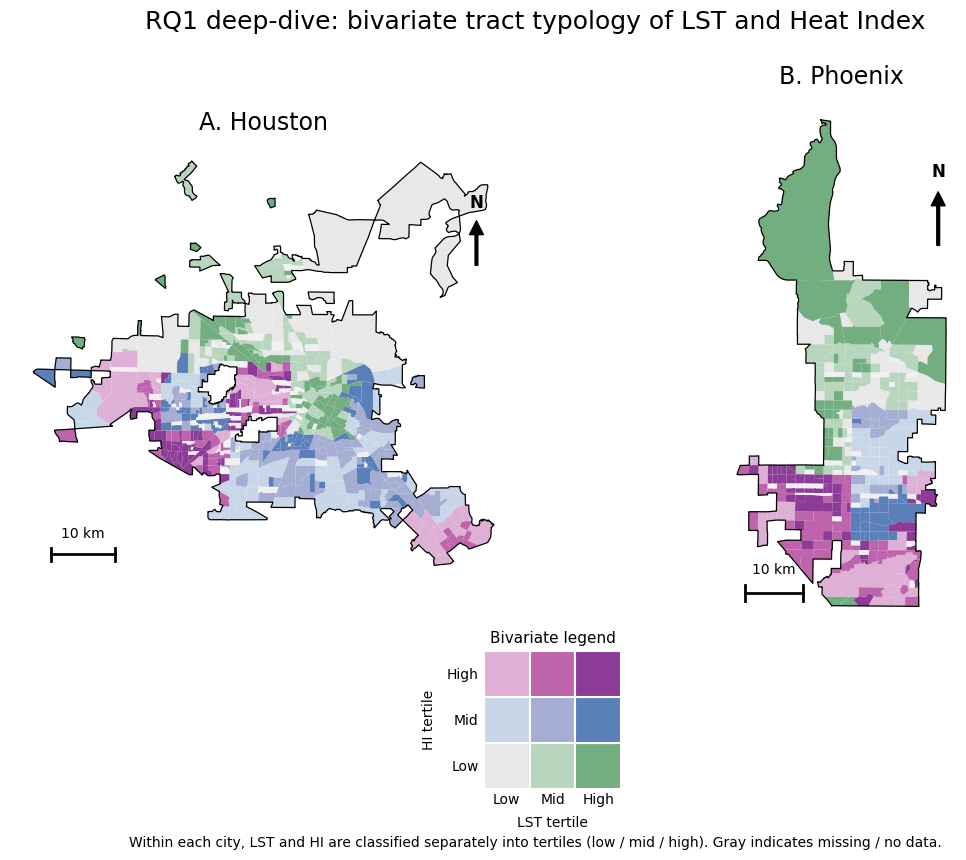

/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_bivariate_lst_hi_typology_v3.png -> True


In [6]:
# ============================================================
# 08 / Cell 3 (FINAL CLEAN VERSION)
# Cleaner bivariate LST-HI typology map
# ============================================================

from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np

# ------------------------------------------------------------
# 1. Stronger and cleaner bivariate palette
# row = HI (low -> high)
# col = LST (low -> high)
# ------------------------------------------------------------
BIVARIATE_COLORS = {
    "1-1": "#e8e8e8",  # low LST / low HI
    "2-1": "#b8d6be",  # mid LST / low HI
    "3-1": "#73ae80",  # high LST / low HI

    "1-2": "#c7d7e8",  # low LST / mid HI
    "2-2": "#a5add3",  # mid LST / mid HI
    "3-2": "#5a7fb9",  # high LST / mid HI

    "1-3": "#dfb0d6",  # low LST / high HI
    "2-3": "#be64ac",  # mid LST / high HI
    "3-3": "#8c3b97",  # high LST / high HI

    "missing": "#f0f0f0"
}

# ------------------------------------------------------------
# 2. Helpers
# ------------------------------------------------------------
def add_north_arrow(ax, x=0.92, y=0.82, dy=0.10):
    ax.annotate(
        "",
        xy=(x, y),
        xytext=(x, y - dy),
        xycoords="axes fraction",
        arrowprops=dict(facecolor="black", edgecolor="black", width=2, headwidth=10, headlength=10)
    )
    ax.text(
        x, y + 0.02, "N",
        transform=ax.transAxes,
        ha="center", va="bottom",
        fontsize=12, fontweight="bold"
    )

def add_scalebar(ax, length_m=10000, label="10 km", lw=2):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    width = x1 - x0
    height = y1 - y0

    bar_x = x0 + 0.08 * width
    bar_y = y0 + 0.07 * height

    ax.plot([bar_x, bar_x + length_m], [bar_y, bar_y], color="black", lw=lw)
    ax.plot([bar_x, bar_x], [bar_y - 0.015*height, bar_y + 0.015*height], color="black", lw=lw)
    ax.plot([bar_x + length_m, bar_x + length_m], [bar_y - 0.015*height, bar_y + 0.015*height], color="black", lw=lw)
    ax.text(bar_x + length_m/2, bar_y + 0.03*height, label, ha="center", va="bottom", fontsize=10)

def get_clean_outline(gdf):
    # 用 tract union 做 city outline，比 boundary 文件更干净
    tmp = gdf.loc[gdf.geometry.notna()].copy()
    geom = tmp.unary_union
    return gpd.GeoDataFrame(geometry=[geom], crs=tmp.crs)

def draw_bivariate_legend(ax):
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)

    for hi_class in [1, 2, 3]:
        for lst_class in [1, 2, 3]:
            key = f"{lst_class}-{hi_class}"
            x = lst_class - 1
            y = hi_class - 1
            ax.add_patch(
                Rectangle(
                    (x, y), 1, 1,
                    facecolor=BIVARIATE_COLORS[key],
                    edgecolor="white",
                    linewidth=1.5
                )
            )

    ax.set_xticks([0.5, 1.5, 2.5])
    ax.set_yticks([0.5, 1.5, 2.5])
    ax.set_xticklabels(["Low", "Mid", "High"], fontsize=10)
    ax.set_yticklabels(["Low", "Mid", "High"], fontsize=10)

    ax.set_title("Bivariate legend", fontsize=11, pad=6)
    ax.set_xlabel("LST tertile", fontsize=10, labelpad=6)
    ax.set_ylabel("HI tertile", fontsize=10, labelpad=8)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)

# ------------------------------------------------------------
# 3. Figure layout
# 用两行布局：上面两张图，下面单独 legend
# ------------------------------------------------------------
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(
    nrows=2, ncols=2,
    height_ratios=[14, 3.6],
    width_ratios=[1, 1],
    hspace=0.06,
    wspace=0.14
)

ax_hou = fig.add_subplot(gs[0, 0])
ax_phx = fig.add_subplot(gs[0, 1])
ax_leg = fig.add_subplot(gs[1, :])

plot_order = ["1-1","2-1","3-1","1-2","2-2","3-2","1-3","2-3","3-3","missing"]

for ax, city in zip([ax_hou, ax_phx], ["Houston", "Phoenix"]):
    obj = city_data[city]
    gdf = obj["gdf_bivar"].copy()

    # draw tracts
    for cls in plot_order:
        sub = gdf[gdf["plot_class"] == cls]
        if len(sub) == 0:
            continue
        sub.plot(
            ax=ax,
            color=BIVARIATE_COLORS[cls],
            linewidth=0
        )

    # cleaner outer outline
    outline = get_clean_outline(gdf)
    outline.boundary.plot(ax=ax, color="black", linewidth=0.9)

    # extent
    xmin, ymin, xmax, ymax = gdf.total_bounds
    xpad = (xmax - xmin) * 0.05
    ypad = (ymax - ymin) * 0.05
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)

    # panel title
    panel_title = f"A. {city}" if city == "Houston" else f"B. {city}"
    ax.set_title(panel_title, fontsize=17, pad=8)

    ax.set_axis_off()
    ax.set_aspect("equal")

    add_north_arrow(ax)
    add_scalebar(ax, length_m=10000, label="10 km")

# legend panel
draw_bivariate_legend(ax_leg)
ax_leg.set_aspect("equal")

# overall title (shorter!)
fig.suptitle(
    "RQ1 deep-dive: bivariate tract typology of LST and Heat Index",
    fontsize=18, y=0.975
)

# note at very bottom, no overlap with legend
fig.text(
    0.5, 0.045,
    "Within each city, LST and HI are classified separately into tertiles (low / mid / high). "
    "Gray indicates missing / no data.",
    ha="center", fontsize=10
)

fig_out = FIG_DIR / "rq1_bivariate_lst_hi_typology_v3.png"
fig.savefig(fig_out, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(fig_out, "->", fig_out.exists())

In [5]:
# ============================================================
# 08 / Cell 4
# Quantify concordance vs discordance from bivariate classes
# ============================================================

summary_rows = []

for city, obj in city_data.items():
    gdf = obj["gdf_bivar"].copy()

    valid = gdf[gdf["plot_class"] != "missing"].copy()
    n_valid = len(valid)

    diag_classes = ["1-1", "2-2", "3-3"]
    extreme_discordant_classes = ["1-3", "3-1"]

    diag_n = int(valid["plot_class"].isin(diag_classes).sum())
    extreme_discordant_n = int(valid["plot_class"].isin(extreme_discordant_classes).sum())

    low_low_n = int((valid["plot_class"] == "1-1").sum())
    mid_mid_n = int((valid["plot_class"] == "2-2").sum())
    high_high_n = int((valid["plot_class"] == "3-3").sum())

    hi_gt_lst_n = int((valid["hi_class"].astype(int) > valid["lst_class"].astype(int)).sum())
    lst_gt_hi_n = int((valid["lst_class"].astype(int) > valid["hi_class"].astype(int)).sum())
    exact_match_n = int((valid["hi_class"].astype(int) == valid["lst_class"].astype(int)).sum())

    summary_rows.append({
        "city": city,
        "n_valid": n_valid,
        "exact_match_n": exact_match_n,
        "exact_match_pct_valid": round(exact_match_n / n_valid * 100, 2),
        "diag_n": diag_n,
        "diag_pct_valid": round(diag_n / n_valid * 100, 2),
        "low_low_n": low_low_n,
        "low_low_pct_valid": round(low_low_n / n_valid * 100, 2),
        "mid_mid_n": mid_mid_n,
        "mid_mid_pct_valid": round(mid_mid_n / n_valid * 100, 2),
        "high_high_n": high_high_n,
        "high_high_pct_valid": round(high_high_n / n_valid * 100, 2),
        "extreme_discordant_n": extreme_discordant_n,
        "extreme_discordant_pct_valid": round(extreme_discordant_n / n_valid * 100, 2),
        "hi_gt_lst_n": hi_gt_lst_n,
        "hi_gt_lst_pct_valid": round(hi_gt_lst_n / n_valid * 100, 2),
        "lst_gt_hi_n": lst_gt_hi_n,
        "lst_gt_hi_pct_valid": round(lst_gt_hi_n / n_valid * 100, 2),
    })

bivar_summary = pd.DataFrame(summary_rows)
display(bivar_summary)

bivar_summary_out = OUT_DIR / "rq1_bivariate_concordance_summary.csv"
bivar_summary.to_csv(bivar_summary_out, index=False)
print(bivar_summary_out, "->", bivar_summary_out.exists())

,city,n_valid,exact_match_n,exact_match_pct_valid,diag_n,diag_pct_valid,low_low_n,low_low_pct_valid,mid_mid_n,mid_mid_pct_valid,high_high_n,high_high_pct_valid,extreme_discordant_n,extreme_discordant_pct_valid,hi_gt_lst_n,hi_gt_lst_pct_valid,lst_gt_hi_n,lst_gt_hi_pct_valid
0,Houston,549,231,42.08,231,42.08,86,15.66,76,13.84,69,12.57,95,17.30,138,25.14,180,32.79
1,Phoenix,332,124,37.35,124,37.35,50,15.06,22,6.63,52,15.66,55,16.57,99,29.82,109,32.83


/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_bivariate_concordance_summary.csv -> True


/var/folders/6w/9b3gk7f16xx8v8xscr34djk00000gn/T/ipykernel_17537/2647189574.py:67: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = tmp.unary_union
/var/folders/6w/9b3gk7f16xx8v8xscr34djk00000gn/T/ipykernel_17537/2647189574.py:67: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = tmp.unary_union


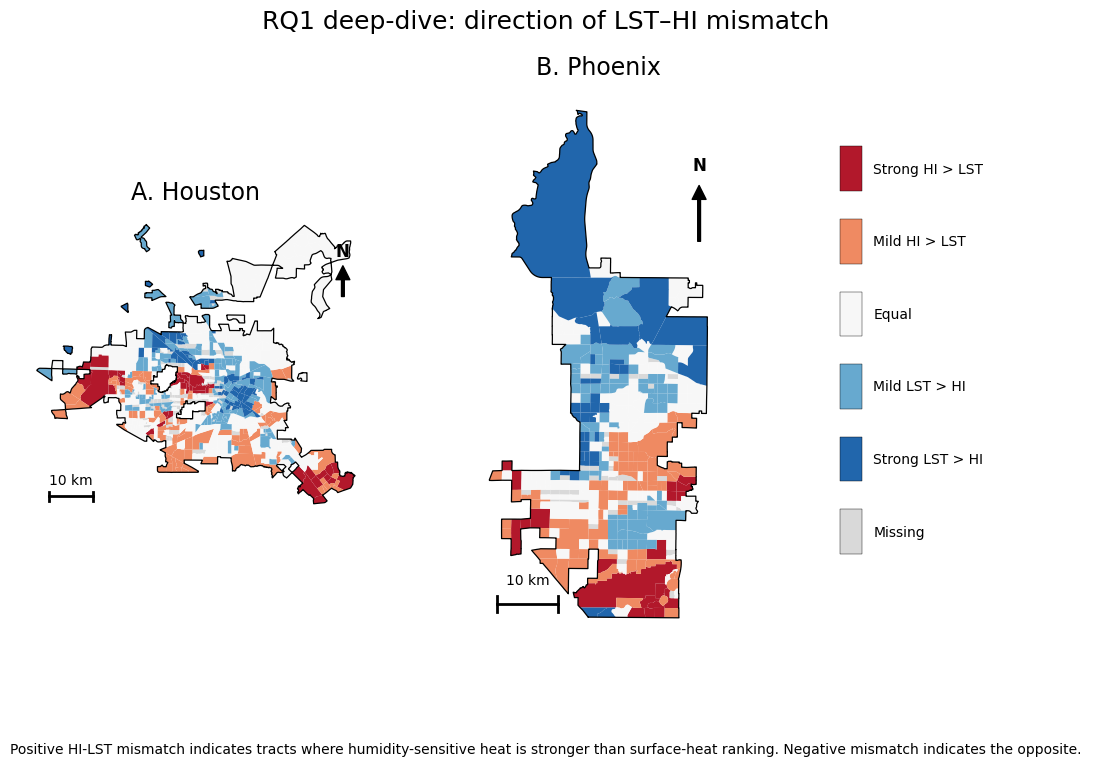

/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_direction_of_mismatch_map.png -> True


,city,equal_pct_valid,hi_gt_lst_pct_valid,lst_gt_hi_pct_valid,strong_hi_gt_lst_pct_valid,strong_lst_gt_hi_pct_valid
0,Houston,42.08,25.14,32.79,7.29,10.02
1,Phoenix,37.35,29.82,32.83,6.33,10.24


/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_direction_mismatch_summary.csv -> True


In [7]:
# ============================================================
# 08 / Cell 5
# Direction-of-mismatch map
# ============================================================

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

DIR_COLORS = {
    "Strong HI > LST": "#b2182b",
    "Mild HI > LST": "#ef8a62",
    "Equal": "#f7f7f7",
    "Mild LST > HI": "#67a9cf",
    "Strong LST > HI": "#2166ac",
    "Missing": "#d9d9d9"
}

def classify_direction(row):
    if row["plot_class"] == "missing":
        return "Missing"
    delta = int(row["hi_class"]) - int(row["lst_class"])
    if delta == 2:
        return "Strong HI > LST"
    elif delta == 1:
        return "Mild HI > LST"
    elif delta == 0:
        return "Equal"
    elif delta == -1:
        return "Mild LST > HI"
    elif delta == -2:
        return "Strong LST > HI"
    return "Missing"

def draw_direction_legend(ax):
    labels = [
        "Strong HI > LST",
        "Mild HI > LST",
        "Equal",
        "Mild LST > HI",
        "Strong LST > HI",
        "Missing"
    ]
    ax.axis("off")
    y0 = 0.85
    dy = 0.13

    for i, lab in enumerate(labels):
        y = y0 - i * dy
        ax.add_patch(
            Rectangle((0.05, y - 0.04), 0.08, 0.08,
                      facecolor=DIR_COLORS[lab], edgecolor="black", linewidth=0.3)
        )
        ax.text(0.17, y, lab, va="center", fontsize=10)

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(
    nrows=2, ncols=3,
    height_ratios=[14, 1],
    width_ratios=[1, 1, 0.8],
    hspace=0.06, wspace=0.16
)

ax_hou = fig.add_subplot(gs[0, 0])
ax_phx = fig.add_subplot(gs[0, 1])
ax_leg = fig.add_subplot(gs[0, 2])

summary_rows = []

for ax, city in zip([ax_hou, ax_phx], ["Houston", "Phoenix"]):
    obj = city_data[city]
    gdf = obj["gdf_bivar"].copy()

    gdf["direction_class"] = gdf.apply(classify_direction, axis=1)

    order = [
        "Missing",
        "Strong HI > LST",
        "Mild HI > LST",
        "Equal",
        "Mild LST > HI",
        "Strong LST > HI"
    ]

    for cls in order:
        sub = gdf[gdf["direction_class"] == cls]
        if len(sub) == 0:
            continue
        sub.plot(ax=ax, color=DIR_COLORS[cls], linewidth=0)

    outline = get_clean_outline(gdf)
    outline.boundary.plot(ax=ax, color="black", linewidth=0.9)

    xmin, ymin, xmax, ymax = gdf.total_bounds
    xpad = (xmax - xmin) * 0.05
    ypad = (ymax - ymin) * 0.05
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)

    panel_title = f"A. {city}" if city == "Houston" else f"B. {city}"
    ax.set_title(panel_title, fontsize=17, pad=8)
    ax.set_axis_off()
    ax.set_aspect("equal")

    add_north_arrow(ax)
    add_scalebar(ax, length_m=10000, label="10 km")

    valid = gdf[gdf["direction_class"] != "Missing"].copy()
    counts = valid["direction_class"].value_counts()

    summary_rows.append({
        "city": city,
        "equal_pct_valid": round((valid["direction_class"] == "Equal").mean() * 100, 2),
        "hi_gt_lst_pct_valid": round(valid["direction_class"].isin(["Strong HI > LST", "Mild HI > LST"]).mean() * 100, 2),
        "lst_gt_hi_pct_valid": round(valid["direction_class"].isin(["Strong LST > HI", "Mild LST > HI"]).mean() * 100, 2),
        "strong_hi_gt_lst_pct_valid": round((valid["direction_class"] == "Strong HI > LST").mean() * 100, 2),
        "strong_lst_gt_hi_pct_valid": round((valid["direction_class"] == "Strong LST > HI").mean() * 100, 2),
    })

draw_direction_legend(ax_leg)

fig.suptitle(
    "RQ1 deep-dive: direction of LST–HI mismatch",
    fontsize=18, y=0.975
)

fig.text(
    0.5, 0.045,
    "Positive HI-LST mismatch indicates tracts where humidity-sensitive heat is stronger than surface-heat ranking. "
    "Negative mismatch indicates the opposite.",
    ha="center", fontsize=10
)

direction_out = FIG_DIR / "rq1_direction_of_mismatch_map.png"
fig.savefig(direction_out, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(direction_out, "->", direction_out.exists())

direction_summary = pd.DataFrame(summary_rows)
display(direction_summary)

direction_summary_out = OUT_DIR / "rq1_direction_mismatch_summary.csv"
direction_summary.to_csv(direction_summary_out, index=False)
print(direction_summary_out, "->", direction_summary_out.exists())

,GEOID,total_population,lst_c,hi_c,quadrant,city,lst_median_city,hi_median_city
0,48201421101,2646,49.220826,34.198098,High LST + High HI,Houston,48.352146,34.182125
1,48201423301,4897,47.779601,34.199077,Low LST + High HI,Houston,48.352146,34.182125
2,48201453401,2953,50.532028,34.199077,High LST + High HI,Houston,48.352146,34.182125
3,48201331100,3979,50.092671,34.183054,High LST + High HI,Houston,48.352146,34.182125
4,48201331200,5051,47.162345,34.183054,Low LST + High HI,Houston,48.352146,34.182125


/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_scatter_quadrant_data.csv -> True


,city,quadrant,n_tracts,pop_sum,tract_share_pct,pop_share_pct
0,Houston,High LST + High HI,161,577360,29.33,28.48
1,Houston,High LST + Low HI,114,394815,20.77,19.47
2,Houston,Low LST + High HI,118,445655,21.49,21.98
3,Houston,Low LST + Low HI,156,609724,28.42,30.07
4,Phoenix,High LST + High HI,105,438385,31.63,29.91
5,Phoenix,High LST + Low HI,61,303995,18.37,20.74
6,Phoenix,Low LST + High HI,93,401602,28.01,27.40
7,Phoenix,Low LST + Low HI,73,321725,21.99,21.95


/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_scatter_quadrant_summary.csv -> True


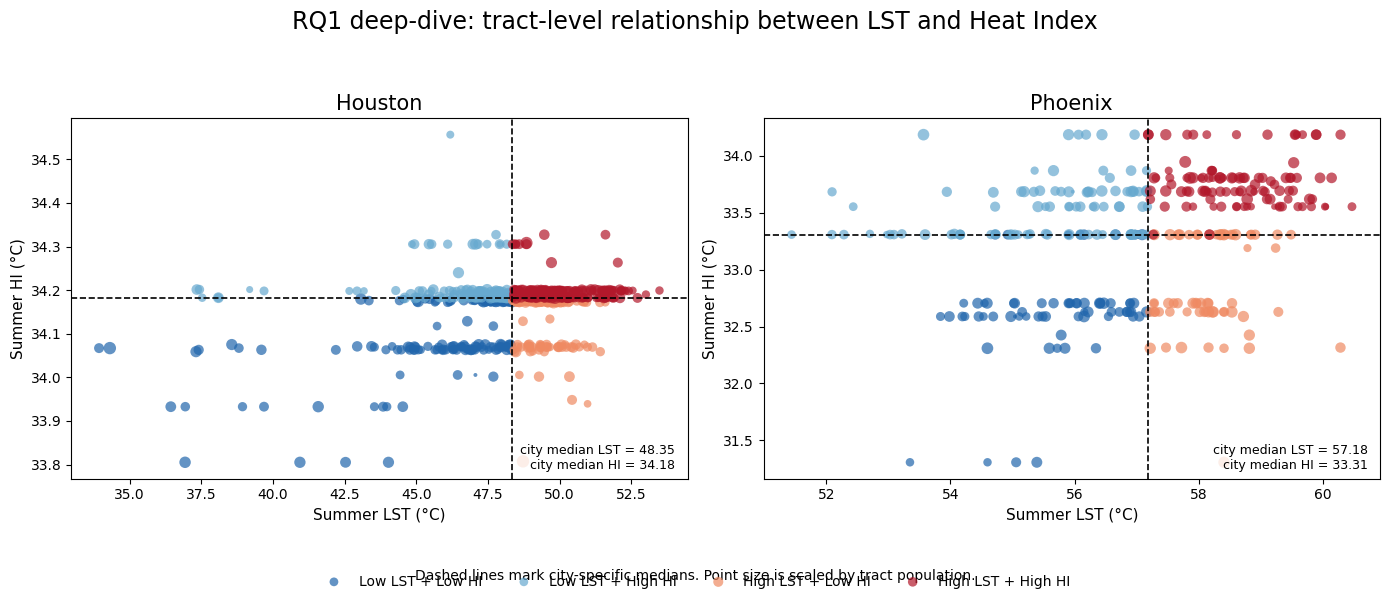

/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_lst_hi_scatter_quadrants.png -> True


In [8]:
# ============================================================
# 08 / Cell 6
# Scatter-quadrant figure: tract-level LST vs HI
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# build tract-level scatter data
# ------------------------------------------------------------
scatter_rows = []

for city, obj in city_data.items():
    gdf = obj["gdf_bivar"].copy()
    cfg = obj["cfg"]

    lst_col = cfg["lst_col"]
    hi_col = cfg["hi_col"]
    pop_col = cfg["pop_col"]

    valid = gdf.loc[
        gdf.geometry.notna() &
        gdf[lst_col].notna() &
        gdf[hi_col].notna()
    ].copy()

    lst_med = float(valid[lst_col].median())
    hi_med = float(valid[hi_col].median())

    def assign_quadrant(row):
        lst_high = row[lst_col] >= lst_med
        hi_high = row[hi_col] >= hi_med
        if lst_high and hi_high:
            return "High LST + High HI"
        elif lst_high and (not hi_high):
            return "High LST + Low HI"
        elif (not lst_high) and hi_high:
            return "Low LST + High HI"
        else:
            return "Low LST + Low HI"

    valid["quadrant"] = valid.apply(assign_quadrant, axis=1)
    valid["city"] = city
    valid["lst_median_city"] = lst_med
    valid["hi_median_city"] = hi_med

    scatter_rows.append(valid[[cfg["geoid_col"], pop_col, lst_col, hi_col, "quadrant", "city", "lst_median_city", "hi_median_city"]])

scatter_df = pd.concat(scatter_rows, ignore_index=True)

display(scatter_df.head())

scatter_out = OUT_DIR / "rq1_scatter_quadrant_data.csv"
scatter_df.to_csv(scatter_out, index=False)
print(scatter_out, "->", scatter_out.exists())

# ------------------------------------------------------------
# summary table
# ------------------------------------------------------------
quad_summary = (
    scatter_df.groupby(["city", "quadrant"])
    .agg(
        n_tracts=("quadrant", "size"),
        pop_sum=("total_population", "sum")
    )
    .reset_index()
)

quad_summary["tract_share_pct"] = (
    quad_summary.groupby("city")["n_tracts"].transform(lambda x: x / x.sum() * 100)
).round(2)

quad_summary["pop_share_pct"] = (
    quad_summary.groupby("city")["pop_sum"].transform(lambda x: x / x.sum() * 100)
).round(2)

display(quad_summary)

quad_summary_out = OUT_DIR / "rq1_scatter_quadrant_summary.csv"
quad_summary.to_csv(quad_summary_out, index=False)
print(quad_summary_out, "->", quad_summary_out.exists())

# ------------------------------------------------------------
# plot
# ------------------------------------------------------------
QUAD_COLORS = {
    "High LST + High HI": "#b2182b",
    "High LST + Low HI": "#ef8a62",
    "Low LST + High HI": "#67a9cf",
    "Low LST + Low HI": "#2166ac",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)

for ax, city in zip(axes, ["Houston", "Phoenix"]):
    sub = scatter_df[scatter_df["city"] == city].copy()

    lst_col = "lst_c"
    hi_col = "hi_c"

    lst_med = float(sub["lst_median_city"].iloc[0])
    hi_med = float(sub["hi_median_city"].iloc[0])

    # size by population, but capped for readability
    pop = sub["total_population"].fillna(sub["total_population"].median())
    size = np.clip(np.sqrt(pop) * 0.8, 8, 80)

    for quad in [
        "Low LST + Low HI",
        "Low LST + High HI",
        "High LST + Low HI",
        "High LST + High HI",
    ]:
        qsub = sub[sub["quadrant"] == quad]
        qsize = size.loc[qsub.index]
        ax.scatter(
            qsub[lst_col],
            qsub[hi_col],
            s=qsize,
            alpha=0.70,
            c=QUAD_COLORS[quad],
            edgecolors="none",
            label=quad
        )

    ax.axvline(lst_med, color="black", linewidth=1.2, linestyle="--")
    ax.axhline(hi_med, color="black", linewidth=1.2, linestyle="--")

    ax.set_title(city, fontsize=15)
    ax.set_xlabel("Summer LST (°C)", fontsize=11)
    ax.set_ylabel("Summer HI (°C)", fontsize=11)

    # annotate medians
    ax.text(
        0.98, 0.02,
        f"city median LST = {lst_med:.2f}\ncity median HI = {hi_med:.2f}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=9,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
    )

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False, fontsize=10)

fig.suptitle(
    "RQ1 deep-dive: tract-level relationship between LST and Heat Index",
    fontsize=17, y=0.98
)

fig.text(
    0.5, 0.03,
    "Dashed lines mark city-specific medians. Point size is scaled by tract population.",
    ha="center", fontsize=10
)

plt.tight_layout(rect=[0, 0.10, 1, 0.93])

scatter_fig_out = FIG_DIR / "rq1_lst_hi_scatter_quadrants.png"
fig.savefig(scatter_fig_out, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(scatter_fig_out, "->", scatter_fig_out.exists())

('WARNING: ', 58, ' is an island (no neighbors)')
('WARNING: ', 95, ' is an island (no neighbors)')
('WARNING: ', 107, ' is an island (no neighbors)')
('WARNING: ', 190, ' is an island (no neighbors)')
('WARNING: ', 375, ' is an island (no neighbors)')
('WARNING: ', 411, ' is an island (no neighbors)')
('WARNING: ', 432, ' is an island (no neighbors)')
('WARNING: ', 536, ' is an island (no neighbors)')


/var/folders/6w/9b3gk7f16xx8v8xscr34djk00000gn/T/ipykernel_17537/341298469.py:97: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(valid)
/Users/yufeizhou/Desktop/heat-exposure-compare/.venv/lib/python3.12/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 10 disconnected components.
 There are 8 islands with ids: 58, 95, 107, 190, 375, 411, 432, 536.
  W.__init__(self, neighbors, ids=ids, **kw)
/Users/yufeizhou/Desktop/heat-exposure-compare/.venv/lib/python3.12/site-packages/esda/moran.py:1354: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim
/var/folders/6w/9b3gk7f16xx8v8xscr34djk00000gn/T/ipykernel_17537/341298469.py:97: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to con

,city,n_valid,global_moran_I_gap_z,global_moran_p_gap_z,HH_n,HH_pct_valid,LL_n,LL_pct_valid,HL_n,HL_pct_valid,LH_n,LH_pct_valid,not_sig_n,not_sig_pct_valid
0,Houston,549,0.5817,0.001,58,10.56,75,13.66,4,0.73,4,0.73,408,74.32
1,Phoenix,332,0.7000,0.001,65,19.58,67,20.18,2,0.60,2,0.60,196,59.04


/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_lisa_gap_cluster_summary.csv -> True


/var/folders/6w/9b3gk7f16xx8v8xscr34djk00000gn/T/ipykernel_17537/341298469.py:19: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = tmp.unary_union
/var/folders/6w/9b3gk7f16xx8v8xscr34djk00000gn/T/ipykernel_17537/341298469.py:19: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = tmp.unary_union


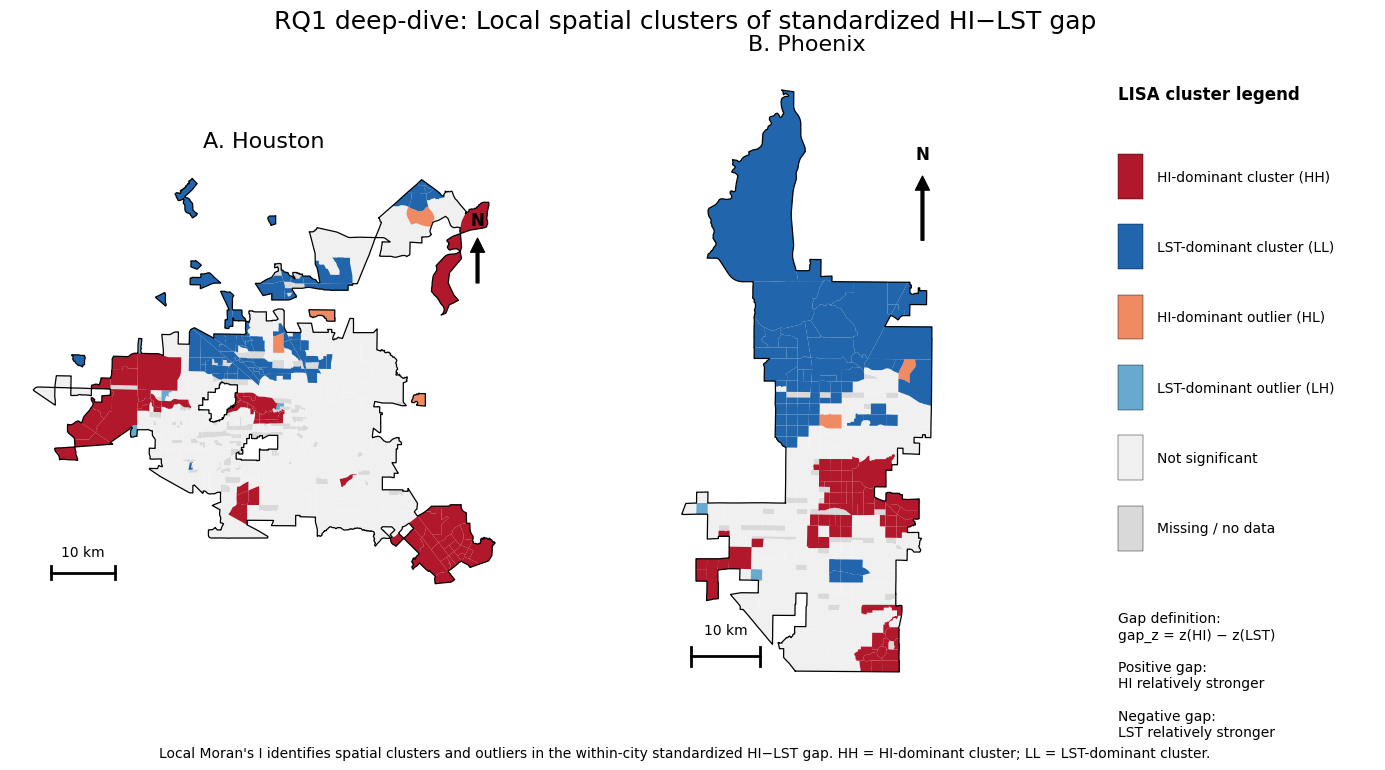

/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_lisa_gap_cluster_map.png -> True


In [9]:
# ============================================================
# 08 / Cell 7
# Advanced figure: LISA cluster map of standardized HI-LST gap
# ============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from libpysal.weights import Queen
from esda.moran import Moran_Local, Moran

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def get_clean_outline(gdf):
    tmp = gdf.loc[gdf.geometry.notna()].copy()
    geom = tmp.unary_union
    return gpd.GeoDataFrame(geometry=[geom], crs=tmp.crs)

def add_north_arrow(ax, x=0.92, y=0.82, dy=0.10):
    ax.annotate(
        "",
        xy=(x, y),
        xytext=(x, y - dy),
        xycoords="axes fraction",
        arrowprops=dict(facecolor="black", edgecolor="black", width=2, headwidth=10, headlength=10)
    )
    ax.text(
        x, y + 0.02, "N",
        transform=ax.transAxes,
        ha="center", va="bottom",
        fontsize=12, fontweight="bold"
    )

def add_scalebar(ax, length_m=10000, label="10 km", lw=2):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    width = x1 - x0
    height = y1 - y0

    bar_x = x0 + 0.08 * width
    bar_y = y0 + 0.07 * height

    ax.plot([bar_x, bar_x + length_m], [bar_y, bar_y], color="black", lw=lw)
    ax.plot([bar_x, bar_x], [bar_y - 0.015*height, bar_y + 0.015*height], color="black", lw=lw)
    ax.plot([bar_x + length_m, bar_x + length_m], [bar_y - 0.015*height, bar_y + 0.015*height], color="black", lw=lw)
    ax.text(bar_x + length_m/2, bar_y + 0.03*height, label, ha="center", va="bottom", fontsize=10)

LISA_COLORS = {
    "HI-dominant cluster (HH)": "#b2182b",
    "LST-dominant cluster (LL)": "#2166ac",
    "HI-dominant outlier (HL)": "#ef8a62",
    "LST-dominant outlier (LH)": "#67a9cf",
    "Not significant": "#f0f0f0",
    "Missing / no data": "#d9d9d9",
}

plot_order = [
    "Missing / no data",
    "Not significant",
    "LST-dominant outlier (LH)",
    "HI-dominant outlier (HL)",
    "LST-dominant cluster (LL)",
    "HI-dominant cluster (HH)",
]

# ------------------------------------------------------------
# compute local spatial clusters
# gap_z = z(HI) - z(LST) within each city
# ------------------------------------------------------------
lisa_summary_rows = []
city_lisa_data = {}

for city, obj in city_data.items():
    gdf = obj["gdf_bivar"].copy()
    cfg = obj["cfg"]

    lst_col = cfg["lst_col"]
    hi_col = cfg["hi_col"]

    valid_mask = (
        gdf.geometry.notna() &
        gdf[lst_col].notna() &
        gdf[hi_col].notna()
    )

    valid = gdf.loc[valid_mask].copy().reset_index(drop=False).rename(columns={"index": "orig_index"})

    # within-city z scores
    valid["lst_z"] = (valid[lst_col] - valid[lst_col].mean()) / valid[lst_col].std(ddof=0)
    valid["hi_z"]  = (valid[hi_col] - valid[hi_col].mean()) / valid[hi_col].std(ddof=0)
    valid["gap_z"] = valid["hi_z"] - valid["lst_z"]

    # spatial weights
    w = Queen.from_dataframe(valid)
    w.transform = "R"

    # local and global Moran
    lisa = Moran_Local(valid["gap_z"].values, w, permutations=999)
    global_moran = Moran(valid["gap_z"].values, w, permutations=999)

    valid["lisa_q"] = lisa.q
    valid["lisa_p"] = lisa.p_sim
    valid["lisa_sig"] = valid["lisa_p"] < 0.05
    valid["lisa_class"] = "Not significant"

    # PySAL quadrant convention:
    # 1 = HH, 2 = LH, 3 = LL, 4 = HL
    valid.loc[valid["lisa_sig"] & (valid["lisa_q"] == 1), "lisa_class"] = "HI-dominant cluster (HH)"
    valid.loc[valid["lisa_sig"] & (valid["lisa_q"] == 3), "lisa_class"] = "LST-dominant cluster (LL)"
    valid.loc[valid["lisa_sig"] & (valid["lisa_q"] == 4), "lisa_class"] = "HI-dominant outlier (HL)"
    valid.loc[valid["lisa_sig"] & (valid["lisa_q"] == 2), "lisa_class"] = "LST-dominant outlier (LH)"

    # merge back
    full = gdf.copy()
    full["gap_z"] = np.nan
    full["lisa_class"] = "Missing / no data"
    full.loc[valid["orig_index"], "gap_z"] = valid["gap_z"].values
    full.loc[valid["orig_index"], "lisa_class"] = valid["lisa_class"].values

    city_lisa_data[city] = {
        "gdf": full,
        "valid": valid,
        "global_I": float(global_moran.I),
        "global_p": float(global_moran.p_sim),
    }

    counts = valid["lisa_class"].value_counts()
    n_valid = len(valid)

    lisa_summary_rows.append({
        "city": city,
        "n_valid": n_valid,
        "global_moran_I_gap_z": round(float(global_moran.I), 4),
        "global_moran_p_gap_z": round(float(global_moran.p_sim), 4),
        "HH_n": int(counts.get("HI-dominant cluster (HH)", 0)),
        "HH_pct_valid": round(counts.get("HI-dominant cluster (HH)", 0) / n_valid * 100, 2),
        "LL_n": int(counts.get("LST-dominant cluster (LL)", 0)),
        "LL_pct_valid": round(counts.get("LST-dominant cluster (LL)", 0) / n_valid * 100, 2),
        "HL_n": int(counts.get("HI-dominant outlier (HL)", 0)),
        "HL_pct_valid": round(counts.get("HI-dominant outlier (HL)", 0) / n_valid * 100, 2),
        "LH_n": int(counts.get("LST-dominant outlier (LH)", 0)),
        "LH_pct_valid": round(counts.get("LST-dominant outlier (LH)", 0) / n_valid * 100, 2),
        "not_sig_n": int(counts.get("Not significant", 0)),
        "not_sig_pct_valid": round(counts.get("Not significant", 0) / n_valid * 100, 2),
    })

lisa_summary = pd.DataFrame(lisa_summary_rows)
display(lisa_summary)

lisa_summary_out = OUT_DIR / "rq1_lisa_gap_cluster_summary.csv"
lisa_summary.to_csv(lisa_summary_out, index=False)
print(lisa_summary_out, "->", lisa_summary_out.exists())

# ------------------------------------------------------------
# plot
# ------------------------------------------------------------
fig = plt.figure(figsize=(15, 8))
gs = fig.add_gridspec(
    nrows=1, ncols=3,
    width_ratios=[1, 1, 0.55],
    left=0.05, right=0.96, top=0.90, bottom=0.10, wspace=0.08
)

ax_hou = fig.add_subplot(gs[0, 0])
ax_phx = fig.add_subplot(gs[0, 1])
ax_leg = fig.add_subplot(gs[0, 2])

for ax, city, panel in [(ax_hou, "Houston", "A. Houston"), (ax_phx, "Phoenix", "B. Phoenix")]:
    gdf = city_lisa_data[city]["gdf"].copy()

    for cls in plot_order:
        sub = gdf[gdf["lisa_class"] == cls]
        if len(sub) == 0:
            continue
        sub.plot(ax=ax, color=LISA_COLORS[cls], linewidth=0)

    outline = get_clean_outline(gdf)
    outline.boundary.plot(ax=ax, color="black", linewidth=0.9)

    xmin, ymin, xmax, ymax = gdf.total_bounds
    xpad = (xmax - xmin) * 0.05
    ypad = (ymax - ymin) * 0.05
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)

    ax.set_title(panel, fontsize=16, pad=8)
    ax.set_axis_off()
    ax.set_aspect("equal")

    add_north_arrow(ax)
    add_scalebar(ax, length_m=10000, label="10 km")

# legend panel
ax_leg.axis("off")
legend_labels = [
    "HI-dominant cluster (HH)",
    "LST-dominant cluster (LL)",
    "HI-dominant outlier (HL)",
    "LST-dominant outlier (LH)",
    "Not significant",
    "Missing / no data",
]

y0 = 0.82
dy = 0.11
for i, lab in enumerate(legend_labels):
    y = y0 - i * dy
    ax_leg.add_patch(Rectangle((0.08, y - 0.035), 0.09, 0.07,
                               facecolor=LISA_COLORS[lab],
                               edgecolor="black", linewidth=0.3,
                               transform=ax_leg.transAxes))
    ax_leg.text(0.22, y, lab, va="center", fontsize=10, transform=ax_leg.transAxes)

ax_leg.text(0.08, 0.94, "LISA cluster legend", fontsize=12, fontweight="bold", transform=ax_leg.transAxes)
ax_leg.text(
    0.08, 0.14,
    "Gap definition:\n"
    "gap_z = z(HI) − z(LST)\n\n"
    "Positive gap:\nHI relatively stronger\n\n"
    "Negative gap:\nLST relatively stronger",
    fontsize=10, transform=ax_leg.transAxes, va="top"
)

fig.suptitle(
    "RQ1 deep-dive: Local spatial clusters of standardized HI−LST gap",
    fontsize=18, y=0.965
)

fig.text(
    0.5, 0.03,
    "Local Moran's I identifies spatial clusters and outliers in the within-city standardized HI−LST gap. "
    "HH = HI-dominant cluster; LL = LST-dominant cluster.",
    ha="center", fontsize=10
)

lisa_fig_out = FIG_DIR / "rq1_lisa_gap_cluster_map.png"
fig.savefig(lisa_fig_out, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(lisa_fig_out, "->", lisa_fig_out.exists())

PROJECT_ROOT: /Users/yufeizhou/Desktop/heat-exposure-compare


,city,n_total,n_valid,strong_hi_gt_lst_n,mild_hi_gt_lst_n,equal_n,mild_lst_gt_hi_n,strong_lst_gt_hi_n,missing_n,strong_hi_gt_lst_pct_valid,mild_hi_gt_lst_pct_valid,equal_pct_valid,mild_lst_gt_hi_pct_valid,strong_lst_gt_hi_pct_valid
0,Houston,654,549,74,111,146,135,83,105,13.48,20.22,26.59,24.59,15.12
1,Phoenix,373,332,67,57,71,76,61,41,20.18,17.17,21.39,22.89,18.37


/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_gap_direction_focus_fast_summary.csv -> True


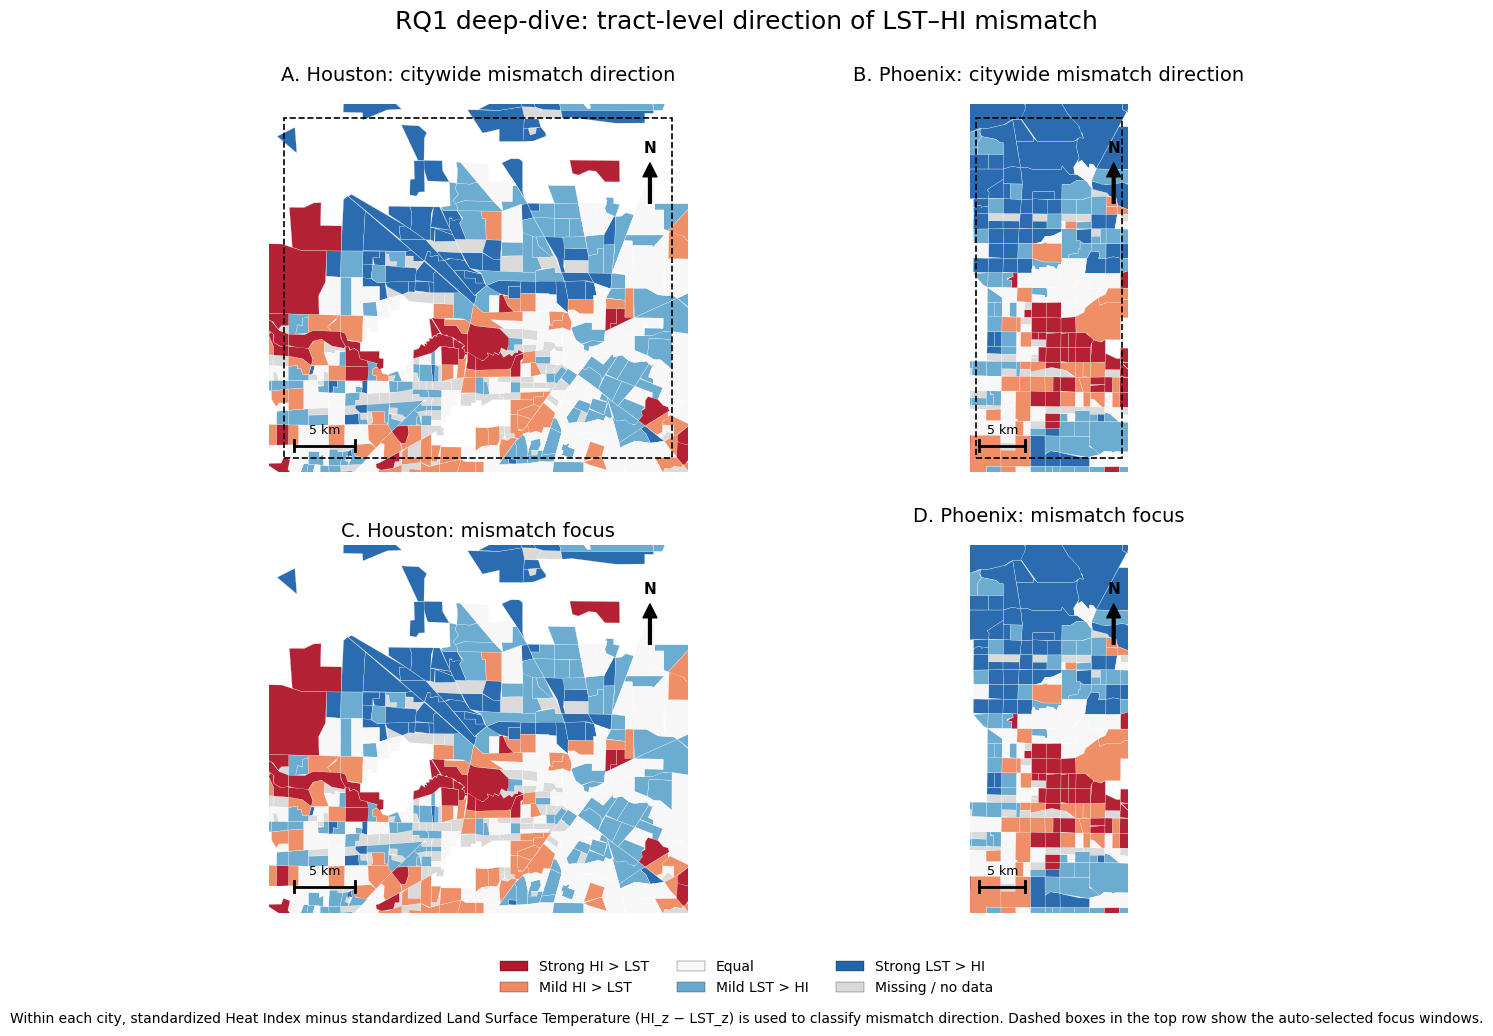

/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_gap_direction_focus_fast.png -> True


In [1]:
# ============================================================
# 08 / FAST RELIABLE VERSION
# tract-level mismatch direction:
# citywide + focus zoom, no html / no basemap / no heavy union
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------
# project root
# ------------------------------------------------------------
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "requirements.txt").exists() and (PROJECT_ROOT.parent / "requirements.txt").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

FIG_DIR = PROJECT_ROOT / "figures" / "pilot"
OUT_DIR = PROJECT_ROOT / "outputs" / "pilot"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)

# ------------------------------------------------------------
# config
# ------------------------------------------------------------
CITY_CFG = {
    "Houston": {
        "path": PROJECT_ROOT / "data_processed/houston/houston_master_with_lst_hi_fixed.gpkg",
        "lst_col": "lst_c",
        "hi_col": "hi_c",
        "label": "Houston",
        "simplify_tol_m": 120,   # fast + still looks good
    },
    "Phoenix": {
        "path": PROJECT_ROOT / "data_processed/phoenix/phoenix_master_with_lst_hi_fixed.gpkg",
        "lst_col": "lst_c",
        "hi_col": "hi_c",
        "label": "Phoenix",
        "simplify_tol_m": 120,
    },
}

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def safe_zscore(series):
    s = pd.to_numeric(series, errors="coerce")
    std = s.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.mean()) / std

def classify_gap(g):
    if pd.isna(g):
        return "Missing"
    if g >= 1.0:
        return "Strong HI > LST"
    elif g >= 0.3:
        return "Mild HI > LST"
    elif g > -0.3:
        return "Equal"
    elif g > -1.0:
        return "Mild LST > HI"
    else:
        return "Strong LST > HI"

GAP_COLORS = {
    "Strong HI > LST": "#b2182b",
    "Mild HI > LST": "#ef8a62",
    "Equal": "#f7f7f7",
    "Mild LST > HI": "#67a9cf",
    "Strong LST > HI": "#2166ac",
    "Missing": "#d9d9d9",
}

PLOT_ORDER = [
    "Missing",
    "Strong LST > HI",
    "Mild LST > HI",
    "Equal",
    "Mild HI > LST",
    "Strong HI > LST",
]

def add_north_arrow(ax, x=0.91, y=0.84, dy=0.11):
    ax.annotate(
        "",
        xy=(x, y),
        xytext=(x, y - dy),
        xycoords="axes fraction",
        arrowprops=dict(facecolor="black", edgecolor="black", width=2, headwidth=10, headlength=10)
    )
    ax.text(
        x, y + 0.02,
        "N",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

def add_scalebar(ax, lw=2):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    width = x1 - x0
    height = y1 - y0

    if width > 160000:
        length = 20000
    elif width > 80000:
        length = 10000
    else:
        length = 5000

    label = f"{int(length/1000)} km"
    bar_x = x0 + 0.06 * width
    bar_y = y0 + 0.07 * height

    ax.plot([bar_x, bar_x + length], [bar_y, bar_y], color="black", lw=lw)
    ax.plot([bar_x, bar_x], [bar_y - 0.015 * height, bar_y + 0.015 * height], color="black", lw=lw)
    ax.plot([bar_x + length, bar_x + length], [bar_y - 0.015 * height, bar_y + 0.015 * height], color="black", lw=lw)
    ax.text(bar_x + length / 2, bar_y + 0.025 * height, label, ha="center", va="bottom", fontsize=9)

def prepare_city(cfg):
    gdf = gpd.read_file(cfg["path"]).copy()
    gdf = gdf.loc[gdf.geometry.notna()].copy()

    lst_col = cfg["lst_col"]
    hi_col = cfg["hi_col"]

    gdf[lst_col] = pd.to_numeric(gdf[lst_col], errors="coerce")
    gdf[hi_col] = pd.to_numeric(gdf[hi_col], errors="coerce")

    # use projected CRS for stable geometry operations
    if gdf.crs is None:
        raise ValueError("CRS missing")
    if gdf.crs.is_geographic:
        gdf = gdf.to_crs(epsg=3857)

    # simplify for speed
    gdf["geometry"] = gdf.geometry.simplify(cfg["simplify_tol_m"], preserve_topology=True)

    valid = gdf.loc[gdf[lst_col].notna() & gdf[hi_col].notna()].copy()
    valid["lst_z"] = safe_zscore(valid[lst_col])
    valid["hi_z"] = safe_zscore(valid[hi_col])
    valid["gap_z"] = valid["hi_z"] - valid["lst_z"]

    gdf["gap_z"] = np.nan
    gdf.loc[valid.index, "gap_z"] = valid["gap_z"]
    gdf["gap_class"] = gdf["gap_z"].apply(classify_gap)

    # city bounds
    xmin, ymin, xmax, ymax = gdf.total_bounds
    city_w = xmax - xmin
    city_h = ymax - ymin

    # auto-focus by strongest abs(gap_z) tract centroids
    focus_source = gdf.loc[gdf["gap_z"].notna()].copy()
    cutoff = focus_source["gap_z"].abs().quantile(0.88)
    focus_source = focus_source.loc[focus_source["gap_z"].abs() >= cutoff].copy()

    if len(focus_source) == 0:
        focus_source = gdf.loc[gdf["gap_z"].notna()].copy()

    ctr = focus_source.geometry.centroid
    cx = float(ctr.x.median())
    cy = float(ctr.y.median())

    half_w = city_w * 0.22
    half_h = city_h * 0.22

    focus_bounds = (
        cx - half_w,
        cy - half_h,
        cx + half_w,
        cy + half_h,
    )

    vc = gdf["gap_class"].value_counts()
    n_valid = int(gdf["gap_z"].notna().sum())

    summary = {
        "city": cfg["label"],
        "n_total": int(len(gdf)),
        "n_valid": n_valid,
        "strong_hi_gt_lst_n": int(vc.get("Strong HI > LST", 0)),
        "mild_hi_gt_lst_n": int(vc.get("Mild HI > LST", 0)),
        "equal_n": int(vc.get("Equal", 0)),
        "mild_lst_gt_hi_n": int(vc.get("Mild LST > HI", 0)),
        "strong_lst_gt_hi_n": int(vc.get("Strong LST > HI", 0)),
        "missing_n": int(vc.get("Missing", 0)),
    }

    if n_valid > 0:
        summary["strong_hi_gt_lst_pct_valid"] = round(summary["strong_hi_gt_lst_n"] / n_valid * 100, 2)
        summary["mild_hi_gt_lst_pct_valid"] = round(summary["mild_hi_gt_lst_n"] / n_valid * 100, 2)
        summary["equal_pct_valid"] = round(summary["equal_n"] / n_valid * 100, 2)
        summary["mild_lst_gt_hi_pct_valid"] = round(summary["mild_lst_gt_hi_n"] / n_valid * 100, 2)
        summary["strong_lst_gt_hi_pct_valid"] = round(summary["strong_lst_gt_hi_n"] / n_valid * 100, 2)
    else:
        summary["strong_hi_gt_lst_pct_valid"] = 0.0
        summary["mild_hi_gt_lst_pct_valid"] = 0.0
        summary["equal_pct_valid"] = 0.0
        summary["mild_lst_gt_hi_pct_valid"] = 0.0
        summary["strong_lst_gt_hi_pct_valid"] = 0.0

    return gdf, focus_bounds, summary

def draw_gap_map(ax, gdf, title, focus_bounds=None, draw_focus_box=False):
    if focus_bounds is None:
        xmin, ymin, xmax, ymax = gdf.total_bounds
    else:
        xmin, ymin, xmax, ymax = focus_bounds

    xpad = (xmax - xmin) * 0.04
    ypad = (ymax - ymin) * 0.04

    for cls in PLOT_ORDER:
        sub = gdf[gdf["gap_class"] == cls]
        if len(sub) == 0:
            continue
        sub.plot(
            ax=ax,
            color=GAP_COLORS[cls],
            edgecolor="#ffffff",
            linewidth=0.18,
            alpha=0.96
        )

    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)
    ax.set_axis_off()
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=14, pad=6)

    add_north_arrow(ax)
    add_scalebar(ax)

    if draw_focus_box and focus_bounds is not None:
        fxmin, fymin, fxmax, fymax = focus_bounds
        rect = plt.Rectangle(
            (fxmin, fymin),
            fxmax - fxmin,
            fymax - fymin,
            fill=False,
            edgecolor="black",
            linewidth=1.2,
            linestyle="--"
        )
        ax.add_patch(rect)

# ------------------------------------------------------------
# load both cities
# ------------------------------------------------------------
hou_gdf, hou_focus, hou_summary = prepare_city(CITY_CFG["Houston"])
phx_gdf, phx_focus, phx_summary = prepare_city(CITY_CFG["Phoenix"])

summary_df = pd.DataFrame([hou_summary, phx_summary])
display(summary_df)

summary_out = OUT_DIR / "rq1_gap_direction_focus_fast_summary.csv"
summary_df.to_csv(summary_out, index=False)
print(summary_out, "->", summary_out.exists())

# ------------------------------------------------------------
# figure
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13.5, 10.5))
ax1, ax2, ax3, ax4 = axes.flatten()

draw_gap_map(ax1, hou_gdf, "A. Houston: citywide mismatch direction", focus_bounds=hou_focus, draw_focus_box=True)
draw_gap_map(ax2, phx_gdf, "B. Phoenix: citywide mismatch direction", focus_bounds=phx_focus, draw_focus_box=True)
draw_gap_map(ax3, hou_gdf, "C. Houston: mismatch focus", focus_bounds=hou_focus, draw_focus_box=False)
draw_gap_map(ax4, phx_gdf, "D. Phoenix: mismatch focus", focus_bounds=phx_focus, draw_focus_box=False)

legend_handles = [
    Patch(facecolor=GAP_COLORS["Strong HI > LST"], edgecolor="black", linewidth=0.2, label="Strong HI > LST"),
    Patch(facecolor=GAP_COLORS["Mild HI > LST"], edgecolor="black", linewidth=0.2, label="Mild HI > LST"),
    Patch(facecolor=GAP_COLORS["Equal"], edgecolor="black", linewidth=0.2, label="Equal"),
    Patch(facecolor=GAP_COLORS["Mild LST > HI"], edgecolor="black", linewidth=0.2, label="Mild LST > HI"),
    Patch(facecolor=GAP_COLORS["Strong LST > HI"], edgecolor="black", linewidth=0.2, label="Strong LST > HI"),
    Patch(facecolor=GAP_COLORS["Missing"], edgecolor="black", linewidth=0.2, label="Missing / no data"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, 0.02)
)

fig.suptitle(
    "RQ1 deep-dive: tract-level direction of LST–HI mismatch",
    fontsize=18,
    y=0.97
)

fig.text(
    0.5, 0.005,
    "Within each city, standardized Heat Index minus standardized Land Surface Temperature (HI_z − LST_z) "
    "is used to classify mismatch direction. Dashed boxes in the top row show the auto-selected focus windows.",
    ha="center",
    fontsize=10
)

# IMPORTANT: no bbox_inches='tight' here
fig_out = FIG_DIR / "rq1_gap_direction_focus_fast.png"
fig.savefig(fig_out, dpi=220, facecolor="white")
plt.show()

print(fig_out, "->", fig_out.exists())

PROJECT_ROOT: /Users/yufeizhou/Desktop/heat-exposure-compare


,city,n_valid,median_lst_c,median_hi_c,mean_gap_z,sd_gap_z,min_gap_z,max_gap_z
0,Houston,549,48.352,34.182,-0.0,1.157,-4.743,5.815
1,Phoenix,332,57.179,33.308,-0.0,1.191,-4.283,3.587


/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_hexbin_basemap_summary.csv -> True


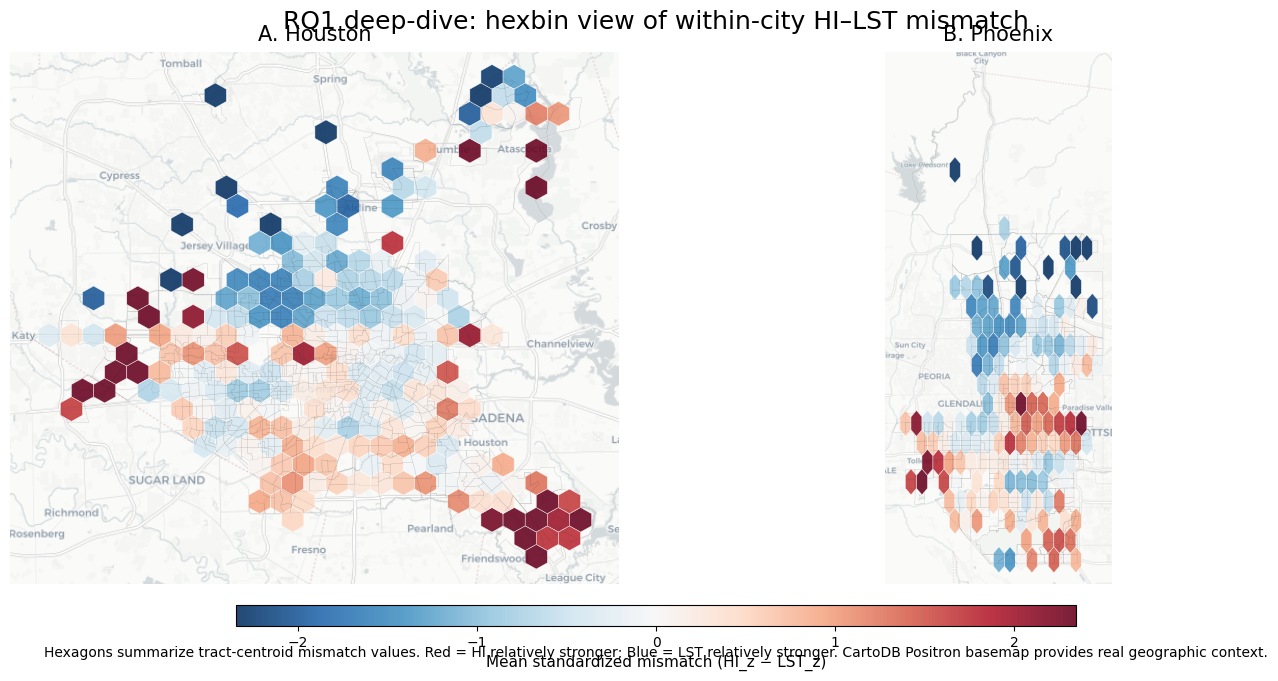

/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_gap_hexbin_basemap.png -> True


In [2]:
# ============================================================
# 08 / NEW STYLE
# RQ1 deep-dive: hexbin basemap map of HI-LST mismatch
# truly different from tract-fill choropleth
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import contextily as ctx

# ------------------------------------------------------------
# project paths
# ------------------------------------------------------------
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "requirements.txt").exists() and (PROJECT_ROOT.parent / "requirements.txt").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

FIG_DIR = PROJECT_ROOT / "figures" / "pilot"
OUT_DIR = PROJECT_ROOT / "outputs" / "pilot"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def safe_z(s):
    s = pd.to_numeric(s, errors="coerce")
    sd = s.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.mean()) / sd

def load_city(path, city_name):
    gdf = gpd.read_file(path).copy()
    gdf = gdf[gdf.geometry.notna()].copy()

    gdf["lst_c"] = pd.to_numeric(gdf["lst_c"], errors="coerce")
    gdf["hi_c"] = pd.to_numeric(gdf["hi_c"], errors="coerce")

    if gdf.crs is None:
        raise ValueError(f"{city_name}: CRS missing")

    if gdf.crs.is_geographic:
        gdf = gdf.to_crs(epsg=3857)
    else:
        gdf = gdf.to_crs(epsg=3857)

    valid = gdf[gdf["lst_c"].notna() & gdf["hi_c"].notna()].copy()
    valid["lst_z"] = safe_z(valid["lst_c"])
    valid["hi_z"] = safe_z(valid["hi_c"])
    valid["gap_z"] = valid["hi_z"] - valid["lst_z"]

    cent = valid.geometry.centroid
    valid["cx"] = cent.x
    valid["cy"] = cent.y

    return gdf, valid

hou_path = PROJECT_ROOT / "data_processed/houston/houston_master_with_lst_hi_fixed.gpkg"
phx_path = PROJECT_ROOT / "data_processed/phoenix/phoenix_master_with_lst_hi_fixed.gpkg"

hou_gdf, hou_valid = load_city(hou_path, "Houston")
phx_gdf, phx_valid = load_city(phx_path, "Phoenix")

# shared color scale
all_gap = pd.concat([hou_valid["gap_z"], phx_valid["gap_z"]], ignore_index=True)
lim = float(np.nanquantile(np.abs(all_gap), 0.95))
lim = max(lim, 0.8)
norm = TwoSlopeNorm(vmin=-lim, vcenter=0, vmax=lim)

# ------------------------------------------------------------
# plot function
# ------------------------------------------------------------
def plot_hexbin_map(ax, full_gdf, valid_df, city_name, gridsize=22, basemap_zoom=10):
    xmin, ymin, xmax, ymax = full_gdf.total_bounds
    xpad = (xmax - xmin) * 0.04
    ypad = (ymax - ymin) * 0.04

    # background light tract boundaries
    full_gdf.boundary.plot(
        ax=ax,
        color="#bdbdbd",
        linewidth=0.25,
        alpha=0.35,
        zorder=2
    )

    # hexbin of centroid gap values
    hb = ax.hexbin(
        valid_df["cx"],
        valid_df["cy"],
        C=valid_df["gap_z"],
        reduce_C_function=np.mean,
        gridsize=gridsize,
        mincnt=1,
        cmap="RdBu_r",
        norm=norm,
        linewidths=0.35,
        edgecolors="white",
        alpha=0.88,
        zorder=3
    )

    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)

    # basemap
    ctx.add_basemap(
        ax,
        source=ctx.providers.CartoDB.Positron,
        zoom=basemap_zoom,
        attribution=False
    )

    # draw boundaries again on top, slightly stronger
    full_gdf.boundary.plot(
        ax=ax,
        color="#4d4d4d",
        linewidth=0.18,
        alpha=0.25,
        zorder=4
    )

    ax.set_axis_off()
    ax.set_title(city_name, fontsize=15, pad=8)

    return hb

# ------------------------------------------------------------
# summary table
# ------------------------------------------------------------
summary_df = pd.DataFrame([
    {
        "city": "Houston",
        "n_valid": len(hou_valid),
        "median_lst_c": round(hou_valid["lst_c"].median(), 3),
        "median_hi_c": round(hou_valid["hi_c"].median(), 3),
        "mean_gap_z": round(hou_valid["gap_z"].mean(), 3),
        "sd_gap_z": round(hou_valid["gap_z"].std(ddof=0), 3),
        "min_gap_z": round(hou_valid["gap_z"].min(), 3),
        "max_gap_z": round(hou_valid["gap_z"].max(), 3),
    },
    {
        "city": "Phoenix",
        "n_valid": len(phx_valid),
        "median_lst_c": round(phx_valid["lst_c"].median(), 3),
        "median_hi_c": round(phx_valid["hi_c"].median(), 3),
        "mean_gap_z": round(phx_valid["gap_z"].mean(), 3),
        "sd_gap_z": round(phx_valid["gap_z"].std(ddof=0), 3),
        "min_gap_z": round(phx_valid["gap_z"].min(), 3),
        "max_gap_z": round(phx_valid["gap_z"].max(), 3),
    }
])
display(summary_df)

summary_out = OUT_DIR / "rq1_hexbin_basemap_summary.csv"
summary_df.to_csv(summary_out, index=False)
print(summary_out, "->", summary_out.exists())

# ------------------------------------------------------------
# figure
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

hb1 = plot_hexbin_map(axes[0], hou_gdf, hou_valid, "A. Houston", gridsize=24, basemap_zoom=10)
hb2 = plot_hexbin_map(axes[1], phx_gdf, phx_valid, "B. Phoenix", gridsize=18, basemap_zoom=10)

fig.suptitle(
    "RQ1 deep-dive: hexbin view of within-city HI–LST mismatch",
    fontsize=18,
    y=0.96
)

cax = fig.add_axes([0.2, 0.08, 0.6, 0.03])
cb = fig.colorbar(hb2, cax=cax, orientation="horizontal")
cb.set_label("Mean standardized mismatch (HI_z − LST_z)", fontsize=11)

fig.text(
    0.5, 0.035,
    "Hexagons summarize tract-centroid mismatch values. Red = HI relatively stronger; Blue = LST relatively stronger. "
    "CartoDB Positron basemap provides real geographic context.",
    ha="center",
    fontsize=10
)

plt.subplots_adjust(left=0.03, right=0.97, top=0.90, bottom=0.14, wspace=0.08)

fig_out = FIG_DIR / "rq1_gap_hexbin_basemap.png"
fig.savefig(fig_out, dpi=260, facecolor="white")
plt.show()

print(fig_out, "->", fig_out.exists())

In [6]:
# ============================================================
# 08 / NEW CELL 1
# Robust load for single-city deep-dive maps
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

try:
    import contextily as ctx
    HAS_CONTEXTILY = True
except Exception:
    HAS_CONTEXTILY = False

from scipy.stats import gaussian_kde
from matplotlib.patches import Patch

PROJECT_ROOT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")
FIG_DIR = PROJECT_ROOT / "figures" / "pilot"
OUT_DIR = PROJECT_ROOT / "outputs" / "pilot"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

CITY_FILES = {
    "Houston": PROJECT_ROOT / "data_processed/houston/houston_master_with_lst_hi_fixed.gpkg",
    "Phoenix": PROJECT_ROOT / "data_processed/phoenix/phoenix_master_with_lst_hi_fixed.gpkg",
}

LST_CANDIDATES = [
    "lst_c", "lst_summer_median_c", "median_lst_c", "lst_median_c",
    "lst_summer_median", "lst"
]

HI_CANDIDATES = [
    "hi_c", "hi_summer_median_c", "median_hi_c", "hi_median_c",
    "hi_summer_median", "heat_index", "hi"
]

GEOID_CANDIDATES = [
    "GEOID", "geoid", "GEOID10", "TRACTCE", "tract_id"
]

POP_CANDIDATES = [
    "total_population", "population", "pop_total", "POPULATION", "total_pop"
]

def pick_col(columns, candidates, label):
    cols = list(columns)
    lower_map = {c.lower(): c for c in cols}

    # exact match first
    for cand in candidates:
        if cand in cols:
            return cand

    # lower-case exact
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]

    # fuzzy fallback
    for c in cols:
        cl = c.lower()
        if label == "lst":
            if "lst" in cl or ("surface" in cl and "temp" in cl):
                return c
        elif label == "hi":
            if cl == "hi" or "heat_index" in cl or ("heat" in cl and "index" in cl):
                return c
        elif label == "geoid":
            if "geoid" in cl:
                return c
        elif label == "pop":
            if "population" in cl or cl.startswith("pop_"):
                return c

    return None

def add_north_arrow(ax, x=0.93, y=0.90, arrow_len=0.08):
    ax.annotate(
        "N",
        xy=(x, y),
        xytext=(x, y - arrow_len),
        xycoords="axes fraction",
        textcoords="axes fraction",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        arrowprops=dict(facecolor="black", width=2, headwidth=8)
    )

def load_city_robust(city_name, fp):
    gdf = gpd.read_file(fp).copy()

    if gdf.crs is None:
        raise ValueError(f"{city_name}: CRS missing")

    # project for basemap / distance-based plotting
    gdf = gdf.to_crs(epsg=3857)

    lst_col = pick_col(gdf.columns, LST_CANDIDATES, "lst")
    hi_col = pick_col(gdf.columns, HI_CANDIDATES, "hi")
    geoid_col = pick_col(gdf.columns, GEOID_CANDIDATES, "geoid")
    pop_col = pick_col(gdf.columns, POP_CANDIDATES, "pop")

    if lst_col is None:
        raise ValueError(f"{city_name}: could not find LST column. Available: {list(gdf.columns)}")
    if hi_col is None:
        raise ValueError(f"{city_name}: could not find HI column. Available: {list(gdf.columns)}")
    if geoid_col is None:
        raise ValueError(f"{city_name}: could not find GEOID column. Available: {list(gdf.columns)}")

    gdf[lst_col] = pd.to_numeric(gdf[lst_col], errors="coerce")
    gdf[hi_col] = pd.to_numeric(gdf[hi_col], errors="coerce")
    if pop_col is not None:
        gdf[pop_col] = pd.to_numeric(gdf[pop_col], errors="coerce")

    valid = gdf[gdf[lst_col].notna() & gdf[hi_col].notna()].copy()

    # z-score within city
    valid["lst_z"] = (valid[lst_col] - valid[lst_col].mean()) / valid[lst_col].std(ddof=0)
    valid["hi_z"] = (valid[hi_col] - valid[hi_col].mean()) / valid[hi_col].std(ddof=0)
    valid["gap_z"] = valid["hi_z"] - valid["lst_z"]
    valid["abs_gap_z"] = valid["gap_z"].abs()

    cent = valid.geometry.centroid
    valid["cx"] = cent.x
    valid["cy"] = cent.y

    info = {
        "city": city_name,
        "file": str(fp),
        "lst_col": lst_col,
        "hi_col": hi_col,
        "geoid_col": geoid_col,
        "pop_col": pop_col,
        "n_total": len(gdf),
        "n_valid": len(valid),
        "missing_n": len(gdf) - len(valid),
        "lst_median": round(valid[lst_col].median(), 3),
        "hi_median": round(valid[hi_col].median(), 3),
        "gap_z_min": round(valid["gap_z"].min(), 3),
        "gap_z_max": round(valid["gap_z"].max(), 3),
    }

    return gdf, valid, info, lst_col, hi_col, geoid_col, pop_col

KDE_CITY_DATA = {}
KDE_QC_ROWS = []

for city, fp in CITY_FILES.items():
    full_gdf, valid_gdf, info, lst_col, hi_col, geoid_col, pop_col = load_city_robust(city, fp)
    KDE_CITY_DATA[city] = {
        "full": full_gdf,
        "valid": valid_gdf,
        "info": info,
        "lst_col": lst_col,
        "hi_col": hi_col,
        "geoid_col": geoid_col,
        "pop_col": pop_col,
    }
    KDE_QC_ROWS.append(info)

KDE_QC_DF = pd.DataFrame(KDE_QC_ROWS)
display(KDE_QC_DF)

kde_qc_out = OUT_DIR / "rq1_kde_load_qc.csv"
KDE_QC_DF.to_csv(kde_qc_out, index=False)
print(kde_qc_out, "->", kde_qc_out.exists())

,city,file,lst_col,hi_col,geoid_col,pop_col,n_total,n_valid,missing_n,lst_median,hi_median,gap_z_min,gap_z_max
0,Houston,/Users/yufeizhou/Desktop/heat-exposure-compare...,lst_c,hi_c,GEOID,total_population,654,549,105,48.352,34.182,-4.743,5.815
1,Phoenix,/Users/yufeizhou/Desktop/heat-exposure-compare...,lst_c,hi_c,GEOID,total_population,373,332,41,57.179,33.308,-4.283,3.587


/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_kde_load_qc.csv -> True


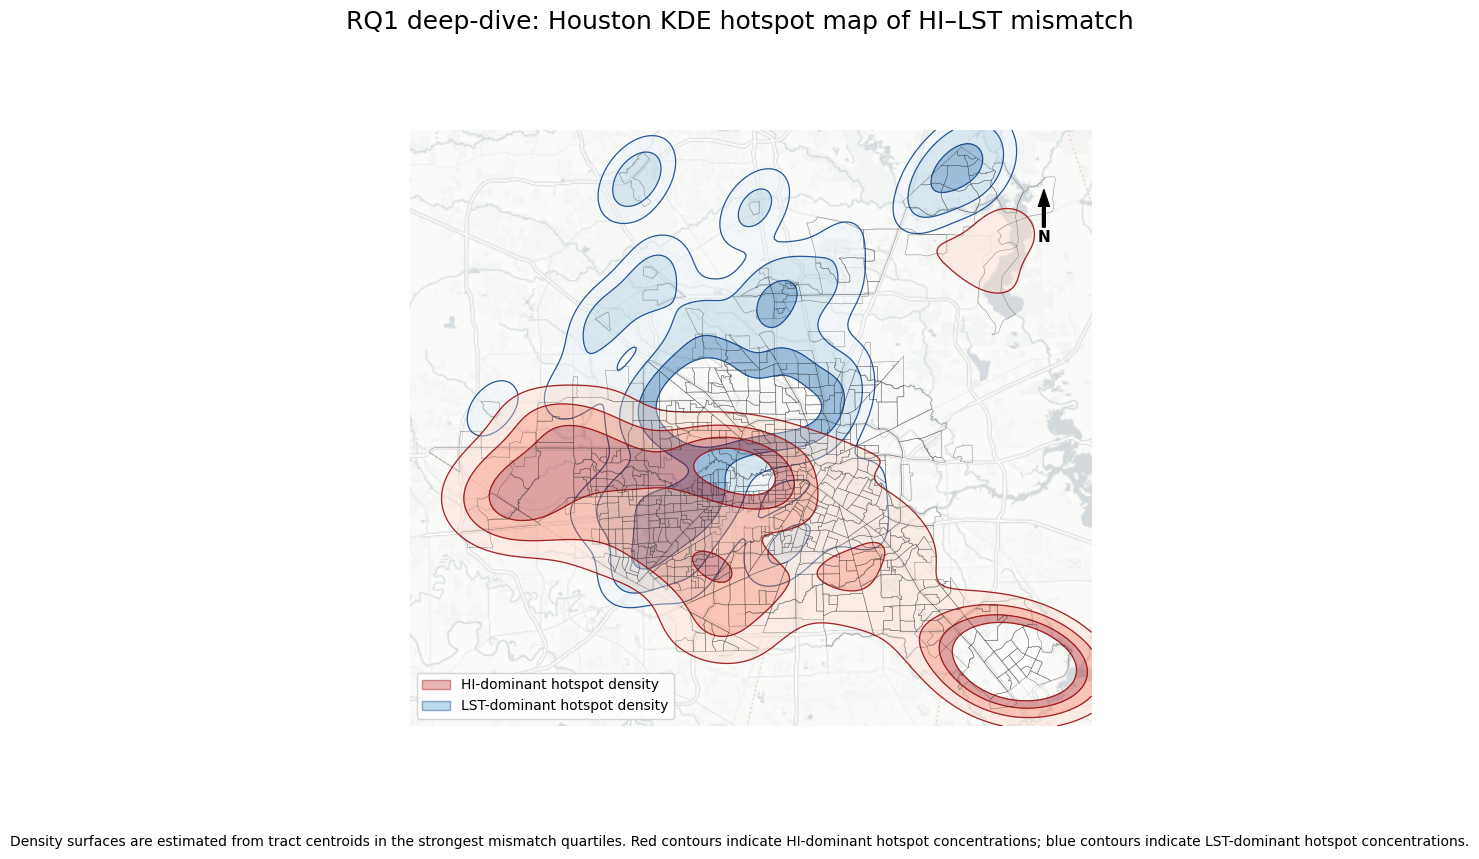

/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_houston_kde_hotspot_single.png -> True


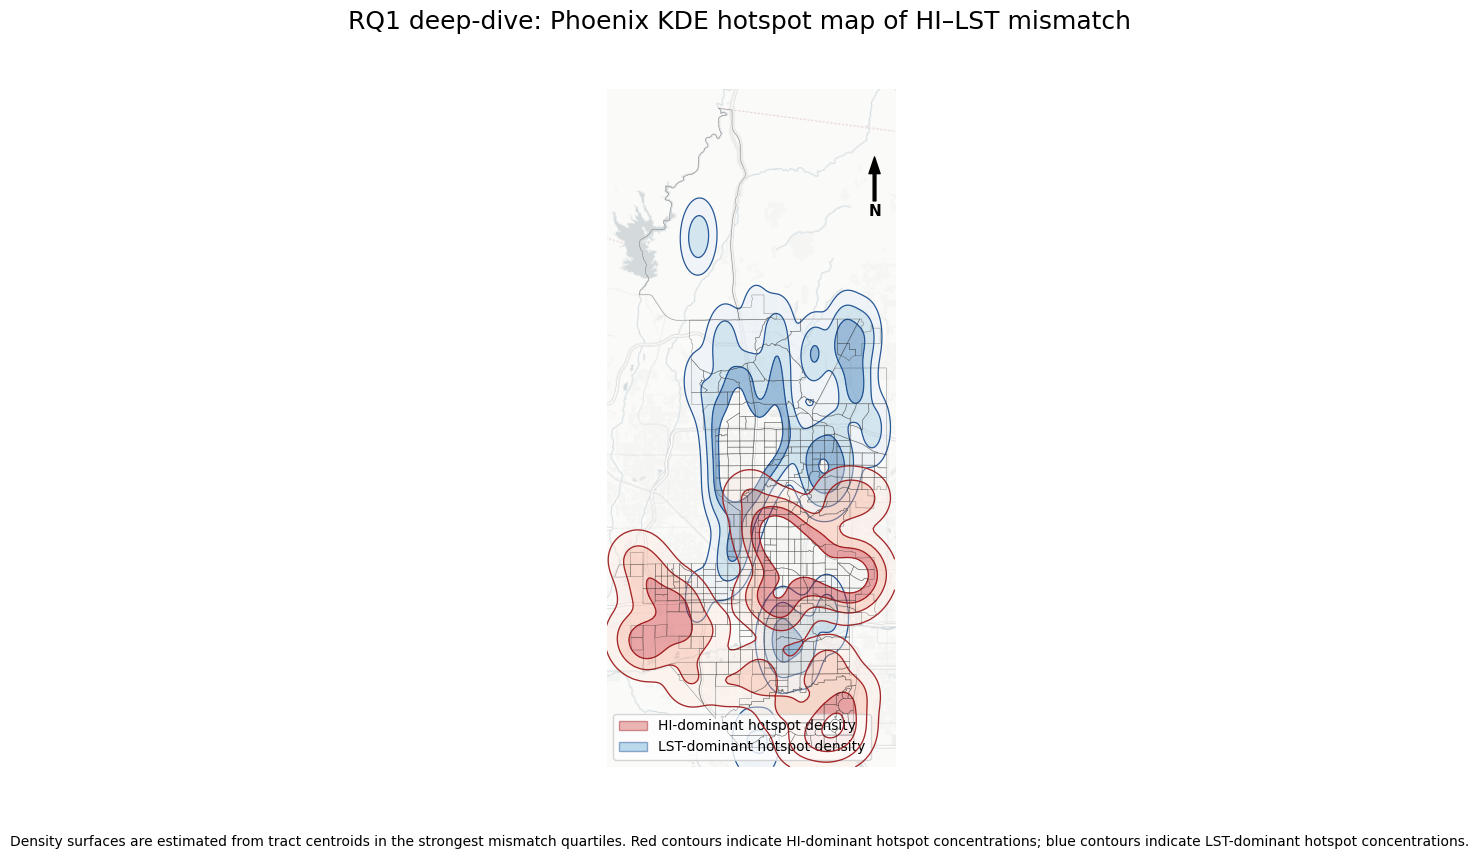

/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_phoenix_kde_hotspot_single.png -> True


In [7]:
# ============================================================
# 08 / NEW CELL 2
# Single-city KDE hotspot maps
# ============================================================

def kde_surface(points_df, bounds, bw_method=0.22, grid_n=220):
    xmin, ymin, xmax, ymax = bounds

    xgrid = np.linspace(xmin, xmax, grid_n)
    ygrid = np.linspace(ymin, ymax, grid_n)
    xx, yy = np.meshgrid(xgrid, ygrid)

    coords = np.vstack([points_df["cx"].values, points_df["cy"].values])
    weights = points_df["abs_gap_z"].fillna(1).values

    kde = gaussian_kde(coords, weights=weights, bw_method=bw_method)
    zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

    return xx, yy, zz

def clean_levels(z):
    vals = z[np.isfinite(z)]
    vals = vals[vals > 0]
    if len(vals) == 0:
        return None

    lev = np.quantile(vals, [0.72, 0.84, 0.93, 0.975])
    lev = np.unique(np.round(lev, 12))

    if len(lev) < 2:
        lev = np.linspace(vals.min(), vals.max(), 4)

    return lev

def plot_single_city_kde(city, city_obj, out_name, bw_method=0.22):
    full_gdf = city_obj["full"]
    valid_gdf = city_obj["valid"]

    # strongest positive mismatch and strongest negative mismatch
    hi_pts = valid_gdf[valid_gdf["gap_z"] >= valid_gdf["gap_z"].quantile(0.75)].copy()
    lst_pts = valid_gdf[valid_gdf["gap_z"] <= valid_gdf["gap_z"].quantile(0.25)].copy()

    xmin, ymin, xmax, ymax = full_gdf.total_bounds
    xspan = xmax - xmin
    yspan = ymax - ymin

    bounds = (
        xmin - 0.03 * xspan,
        ymin - 0.03 * yspan,
        xmax + 0.03 * xspan,
        ymax + 0.03 * yspan,
    )

    xx_hi, yy_hi, zz_hi = kde_surface(hi_pts, bounds, bw_method=bw_method, grid_n=220)
    xx_lo, yy_lo, zz_lo = kde_surface(lst_pts, bounds, bw_method=bw_method, grid_n=220)

    lev_hi = clean_levels(zz_hi)
    lev_lo = clean_levels(zz_lo)

    fig, ax = plt.subplots(figsize=(8.8, 8.8))

    ax.set_xlim(bounds[0], bounds[2])
    ax.set_ylim(bounds[1], bounds[3])

    if HAS_CONTEXTILY:
        ctx.add_basemap(
            ax,
            source=ctx.providers.CartoDB.PositronNoLabels,
            attribution=False,
            zoom=10
        )
    else:
        ax.set_facecolor("#f4f4f4")

    # subtle tract boundaries
    full_gdf.boundary.plot(
        ax=ax,
        color="#8a8a8a",
        linewidth=0.22,
        alpha=0.28,
        zorder=2
    )

    # blue = LST-dominant hotspot density
    if lev_lo is not None:
        ax.contourf(
            xx_lo, yy_lo, zz_lo,
            levels=lev_lo,
            cmap="Blues",
            alpha=0.42,
            zorder=3
        )
        ax.contour(
            xx_lo, yy_lo, zz_lo,
            levels=lev_lo,
            colors="#1d4f91",
            linewidths=0.9,
            alpha=0.95,
            zorder=4
        )

    # red = HI-dominant hotspot density
    if lev_hi is not None:
        ax.contourf(
            xx_hi, yy_hi, zz_hi,
            levels=lev_hi,
            cmap="Reds",
            alpha=0.38,
            zorder=5
        )
        ax.contour(
            xx_hi, yy_hi, zz_hi,
            levels=lev_hi,
            colors="#9f1d20",
            linewidths=0.95,
            alpha=0.95,
            zorder=6
        )

    # city boundary again on top
    full_gdf.boundary.plot(
        ax=ax,
        color="#2f2f2f",
        linewidth=0.38,
        alpha=0.45,
        zorder=7
    )

    add_north_arrow(ax)
    ax.set_axis_off()

    fig.suptitle(
        f"RQ1 deep-dive: {city} KDE hotspot map of HI–LST mismatch",
        fontsize=18,
        y=0.97
    )

    legend_handles = [
        Patch(facecolor="#d95f5f", edgecolor="#9f1d20", alpha=0.45, label="HI-dominant hotspot density"),
        Patch(facecolor="#6baed6", edgecolor="#1d4f91", alpha=0.45, label="LST-dominant hotspot density"),
    ]
    ax.legend(
        handles=legend_handles,
        loc="lower left",
        frameon=True,
        fontsize=10
    )

    fig.text(
        0.5,
        0.02,
        "Density surfaces are estimated from tract centroids in the strongest mismatch quartiles. "
        "Red contours indicate HI-dominant hotspot concentrations; blue contours indicate LST-dominant hotspot concentrations.",
        ha="center",
        fontsize=10
    )

    out_fp = FIG_DIR / out_name
    fig.savefig(out_fp, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print(out_fp, "->", out_fp.exists())

# Houston
plot_single_city_kde(
    city="Houston",
    city_obj=KDE_CITY_DATA["Houston"],
    out_name="rq1_houston_kde_hotspot_single.png",
    bw_method=0.24
)

# Phoenix
plot_single_city_kde(
    city="Phoenix",
    city_obj=KDE_CITY_DATA["Phoenix"],
    out_name="rq1_phoenix_kde_hotspot_single.png",
    bw_method=0.20
)

PROJECT_ROOT: /Users/yufeizhou/Desktop/heat-exposure-compare
Using registry: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_city_registry_template.csv


,city,is_active,status,main_gpkg,boundary_file,lst_col,hi_col,pop_col,geoid_col,notes
0,Houston,True,ready,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...,lst_c,hi_c,total_population,GEOID,Auto-filled from detected registry
1,Phoenix,True,ready,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...,lst_c,hi_c,total_population,GEOID,Auto-filled from detected registry


,city,n_total,n_valid,lst_col,hi_col,geoid_col,pop_col,median_lst_c,median_hi_c
0,Houston,654,549,lst_c,hi_c,GEOID,total_population,48.352,34.182
1,Phoenix,373,332,lst_c,hi_c,GEOID,total_population,57.179,33.308


/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_hexbin_separate_load_qc.csv -> True
Shared vlim: 3.164


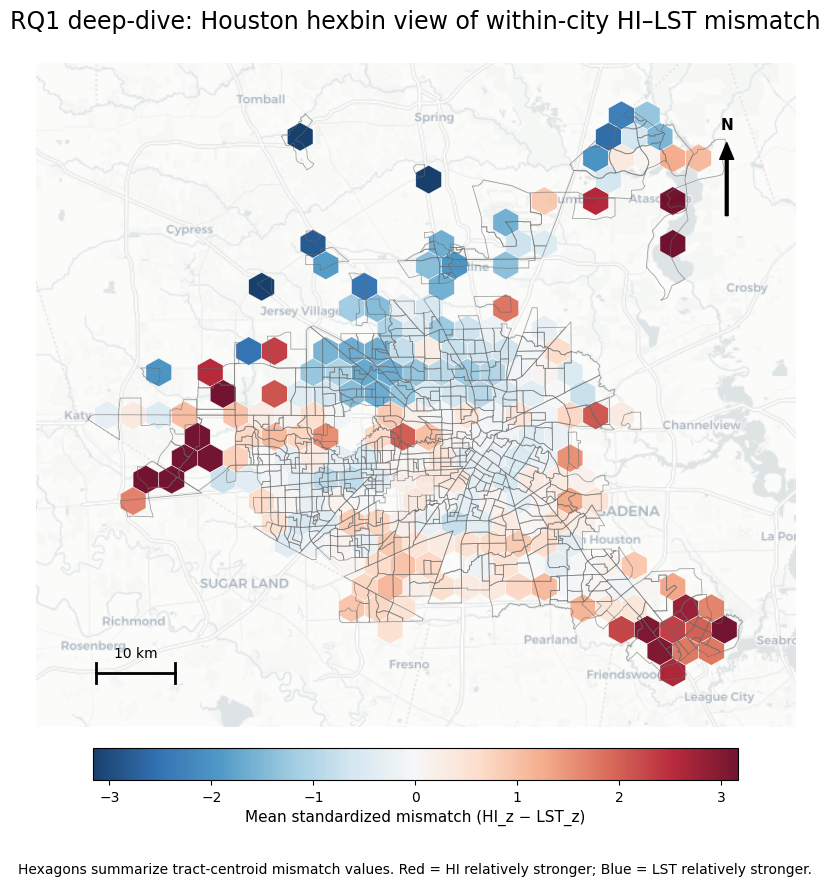

/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_gap_hexbin_houston.png -> True


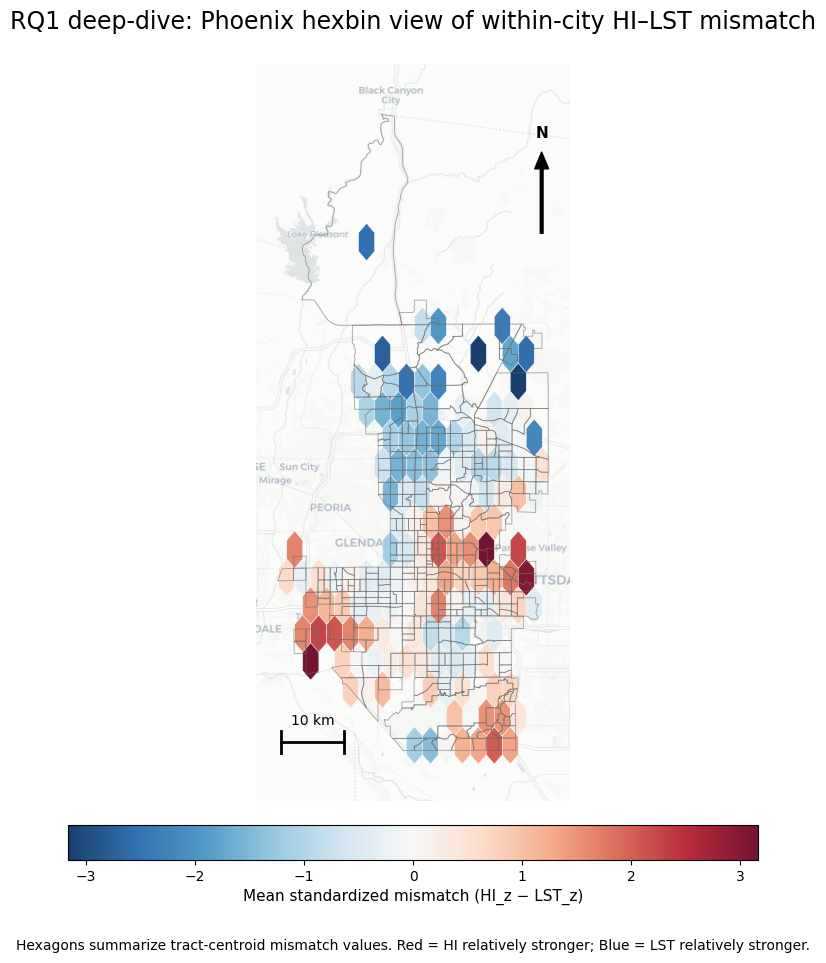

/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_gap_hexbin_phoenix.png -> True


,city,n_valid,median_lst_c,median_hi_c,mean_gap_z,sd_gap_z,min_gap_z,max_gap_z,hex_gridsize,figure_out
0,Houston,549,48.352,34.182,-0.0,1.157,-4.743,5.815,24,/Users/yufeizhou/Desktop/heat-exposure-compare...
1,Phoenix,332,57.179,33.308,-0.0,1.191,-4.283,3.587,16,/Users/yufeizhou/Desktop/heat-exposure-compare...


/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_hexbin_separate_summary.csv -> True


In [8]:
# ============================================================
# 08 / Separate hexbin figures for Houston and Phoenix
# RQ1 deep-dive: tract-centroid hexbin view of HI-LST mismatch
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import contextily as ctx

# -----------------------------
# 1) Find project root
# -----------------------------
def find_project_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p] + list(p.parents):
        if (cand / "data_processed").exists() and (cand / "outputs").exists():
            return cand
    return Path.cwd().resolve()

PROJECT_ROOT = find_project_root()
OUT_DIR = PROJECT_ROOT / "outputs" / "pilot"
FIG_DIR = PROJECT_ROOT / "figures" / "pilot"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)

# -----------------------------
# 2) Read registry
# -----------------------------
registry_candidates = [
    OUT_DIR / "rq1_city_registry_template.csv",
    OUT_DIR / "rq1_city_registry_detected.csv",
]

registry_path = None
for fp in registry_candidates:
    if fp.exists():
        registry_path = fp
        break

if registry_path is None:
    raise FileNotFoundError(
        "Cannot find rq1_city_registry_template.csv or rq1_city_registry_detected.csv in outputs/pilot/"
    )

registry = pd.read_csv(registry_path)
print("Using registry:", registry_path)

def to_bool(x):
    return str(x).strip().lower() in {"true", "1", "yes", "y"}

if "is_active" in registry.columns:
    registry = registry[registry["is_active"].apply(to_bool)].copy()

registry = registry[registry["city"].isin(["Houston", "Phoenix"])].copy()

if registry.empty:
    raise ValueError("No active Houston/Phoenix rows found in the city registry.")

display(registry)

# -----------------------------
# 3) Helpers
# -----------------------------
def resolve_path(p):
    p = Path(str(p))
    if p.is_absolute():
        return p
    return PROJECT_ROOT / p

def choose_existing_col(gdf, candidates):
    for c in candidates:
        if c in gdf.columns:
            return c
    return None

def zscore(s):
    s = pd.to_numeric(s, errors="coerce")
    sd = s.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.mean()) / sd

def add_north_arrow(ax, loc=(0.92, 0.90), size=0.12):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    dx = x1 - x0
    dy = y1 - y0
    x = x0 + dx * loc[0]
    y = y0 + dy * loc[1]
    ax.annotate(
        "",
        xy=(x, y),
        xytext=(x, y - dy * size),
        arrowprops=dict(facecolor="black", edgecolor="black", width=2, headwidth=10),
        zorder=10
    )
    ax.text(x, y + dy * 0.015, "N", ha="center", va="bottom", fontsize=11, fontweight="bold")

def add_scalebar(ax, length_km=10, loc=(0.08, 0.08), lw=2):
    # assumes EPSG:3857 (meters)
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    dx = x1 - x0
    dy = y1 - y0
    xb = x0 + dx * loc[0]
    yb = y0 + dy * loc[1]
    length_m = length_km * 1000

    ax.plot([xb, xb + length_m], [yb, yb], color="black", lw=lw, zorder=10)
    ax.plot([xb, xb], [yb - dy * 0.015, yb + dy * 0.015], color="black", lw=lw, zorder=10)
    ax.plot([xb + length_m, xb + length_m], [yb - dy * 0.015, yb + dy * 0.015], color="black", lw=lw, zorder=10)
    ax.text(xb + length_m / 2, yb + dy * 0.02, f"{length_km} km", ha="center", va="bottom", fontsize=10)

# -----------------------------
# 4) Load city data
# -----------------------------
city_data = {}

for _, row in registry.iterrows():
    city = row["city"]

    gpkg_path = resolve_path(row["main_gpkg"])
    if not gpkg_path.exists():
        raise FileNotFoundError(f"{city}: main_gpkg not found -> {gpkg_path}")

    full_gdf = gpd.read_file(gpkg_path)

    # Use registry columns first; if not found, fallback search
    lst_col = row["lst_col"] if "lst_col" in row and row["lst_col"] in full_gdf.columns else choose_existing_col(
        full_gdf, ["lst_c", "lst", "LST_C", "LST", "summer_lst_c"]
    )
    hi_col = row["hi_col"] if "hi_col" in row and row["hi_col"] in full_gdf.columns else choose_existing_col(
        full_gdf, ["hi_c", "hi", "HI_C", "HI", "summer_hi_c"]
    )
    geoid_col = row["geoid_col"] if "geoid_col" in row and row["geoid_col"] in full_gdf.columns else choose_existing_col(
        full_gdf, ["GEOID", "geoid", "tract_id"]
    )
    pop_col = row["pop_col"] if "pop_col" in row and row["pop_col"] in full_gdf.columns else choose_existing_col(
        full_gdf, ["total_population", "population", "pop_total"]
    )

    if lst_col is None or hi_col is None:
        raise KeyError(f"{city}: cannot find lst/hi columns in {gpkg_path.name}")

    full_gdf[lst_col] = pd.to_numeric(full_gdf[lst_col], errors="coerce")
    full_gdf[hi_col] = pd.to_numeric(full_gdf[hi_col], errors="coerce")
    if pop_col is not None:
        full_gdf[pop_col] = pd.to_numeric(full_gdf[pop_col], errors="coerce")

    # keep geometry rows
    full_gdf = full_gdf[full_gdf.geometry.notna()].copy()

    valid = full_gdf[full_gdf[lst_col].notna() & full_gdf[hi_col].notna()].copy()

    # standardized mismatch: positive = HI stronger, negative = LST stronger
    valid["lst_z"] = zscore(valid[lst_col])
    valid["hi_z"] = zscore(valid[hi_col])
    valid["gap_z"] = valid["hi_z"] - valid["lst_z"]

    full_3857 = full_gdf.to_crs(epsg=3857)
    valid_3857 = valid.to_crs(epsg=3857).copy()

    cent = valid_3857.geometry.centroid
    valid_3857["x"] = cent.x
    valid_3857["y"] = cent.y

    city_data[city] = {
        "full": full_3857,
        "valid": valid_3857,
        "lst_col": lst_col,
        "hi_col": hi_col,
        "geoid_col": geoid_col,
        "pop_col": pop_col,
    }

load_qc = []
for city, d in city_data.items():
    load_qc.append({
        "city": city,
        "n_total": len(d["full"]),
        "n_valid": len(d["valid"]),
        "lst_col": d["lst_col"],
        "hi_col": d["hi_col"],
        "geoid_col": d["geoid_col"],
        "pop_col": d["pop_col"],
        "median_lst_c": round(d["valid"][d["lst_col"]].median(), 3),
        "median_hi_c": round(d["valid"][d["hi_col"]].median(), 3),
    })

load_qc = pd.DataFrame(load_qc)
display(load_qc)

# save qc
load_qc_out = OUT_DIR / "rq1_hexbin_separate_load_qc.csv"
load_qc.to_csv(load_qc_out, index=False)
print(load_qc_out, "->", load_qc_out.exists())

# -----------------------------
# 5) Shared color scale
# -----------------------------
all_abs = np.concatenate([
    np.abs(d["valid"]["gap_z"].to_numpy())
    for d in city_data.values()
])

# robust symmetric range
vlim = float(np.nanquantile(all_abs, 0.98))
if not np.isfinite(vlim) or vlim <= 0:
    vlim = float(np.nanmax(all_abs))
if not np.isfinite(vlim) or vlim <= 0:
    vlim = 1.0

norm = TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)
print("Shared vlim:", round(vlim, 3))

# gridsize per city
hex_gridsize = {
    "Houston": 24,
    "Phoenix": 16,   # fewer, larger bins so Phoenix is easier to read
}

# -----------------------------
# 6) Plot one figure per city
# -----------------------------
summary_rows = []

for city in ["Houston", "Phoenix"]:
    d = city_data[city]
    full = d["full"]
    valid = d["valid"]

    # figure size tuned separately
    if city == "Houston":
        fig, ax = plt.subplots(figsize=(9.8, 9.2))
    else:
        fig, ax = plt.subplots(figsize=(7.2, 10.0))

    xmin, ymin, xmax, ymax = full.total_bounds
    pad_x = (xmax - xmin) * 0.08
    pad_y = (ymax - ymin) * 0.08
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    # basemap first (if it fails, still continue)
    try:
        ctx.add_basemap(
            ax,
            source=ctx.providers.CartoDB.Positron,
            attribution=False,
            alpha=0.75
        )
    except Exception as e:
        print(f"{city}: basemap skipped -> {e}")

    # hexbin
    hb = ax.hexbin(
        valid["x"],
        valid["y"],
        C=valid["gap_z"],
        reduce_C_function=np.mean,
        gridsize=hex_gridsize[city],
        mincnt=1,
        cmap="RdBu_r",
        norm=norm,
        linewidths=0.35,
        edgecolors="white",
        alpha=0.92,
        zorder=3
    )

    # boundary on top
    full.boundary.plot(ax=ax, color="dimgray", linewidth=0.6, alpha=0.6, zorder=4)

    add_north_arrow(ax, loc=(0.91, 0.88), size=0.11)
    add_scalebar(ax, length_km=10, loc=(0.08, 0.08), lw=2)

    ax.set_axis_off()
    ax.set_title(f"RQ1 deep-dive: {city} hexbin view of within-city HI–LST mismatch", fontsize=17, pad=14)

    cbar = fig.colorbar(hb, ax=ax, orientation="horizontal", fraction=0.045, pad=0.03)
    cbar.set_label("Mean standardized mismatch (HI_z − LST_z)", fontsize=11)

    fig.text(
        0.5, 0.015,
        "Hexagons summarize tract-centroid mismatch values. Red = HI relatively stronger; "
        "Blue = LST relatively stronger.",
        ha="center", fontsize=10
    )

    fig.tight_layout(rect=[0, 0.05, 1, 0.97])

    fig_out = FIG_DIR / f"rq1_gap_hexbin_{city.lower()}.png"
    fig.savefig(fig_out, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print(fig_out, "->", fig_out.exists())

    summary_rows.append({
        "city": city,
        "n_valid": len(valid),
        "median_lst_c": round(valid[d["lst_col"]].median(), 3),
        "median_hi_c": round(valid[d["hi_col"]].median(), 3),
        "mean_gap_z": round(valid["gap_z"].mean(), 3),
        "sd_gap_z": round(valid["gap_z"].std(ddof=0), 3),
        "min_gap_z": round(valid["gap_z"].min(), 3),
        "max_gap_z": round(valid["gap_z"].max(), 3),
        "hex_gridsize": hex_gridsize[city],
        "figure_out": str(fig_out),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

summary_out = OUT_DIR / "rq1_hexbin_separate_summary.csv"
summary_df.to_csv(summary_out, index=False)
print(summary_out, "->", summary_out.exists())

PROJECT_ROOT: /Users/yufeizhou/Desktop/heat-exposure-compare


,city,is_active,status,main_gpkg,boundary_file,lst_col,hi_col,pop_col,geoid_col,notes
1,Phoenix,True,ready,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...,lst_c,hi_c,total_population,GEOID,Auto-filled from detected registry


,city,rows_total,rows_valid,lst_col,hi_col,median_lst_c,median_hi_c
0,Phoenix,373,332,lst_c,hi_c,57.179,33.308


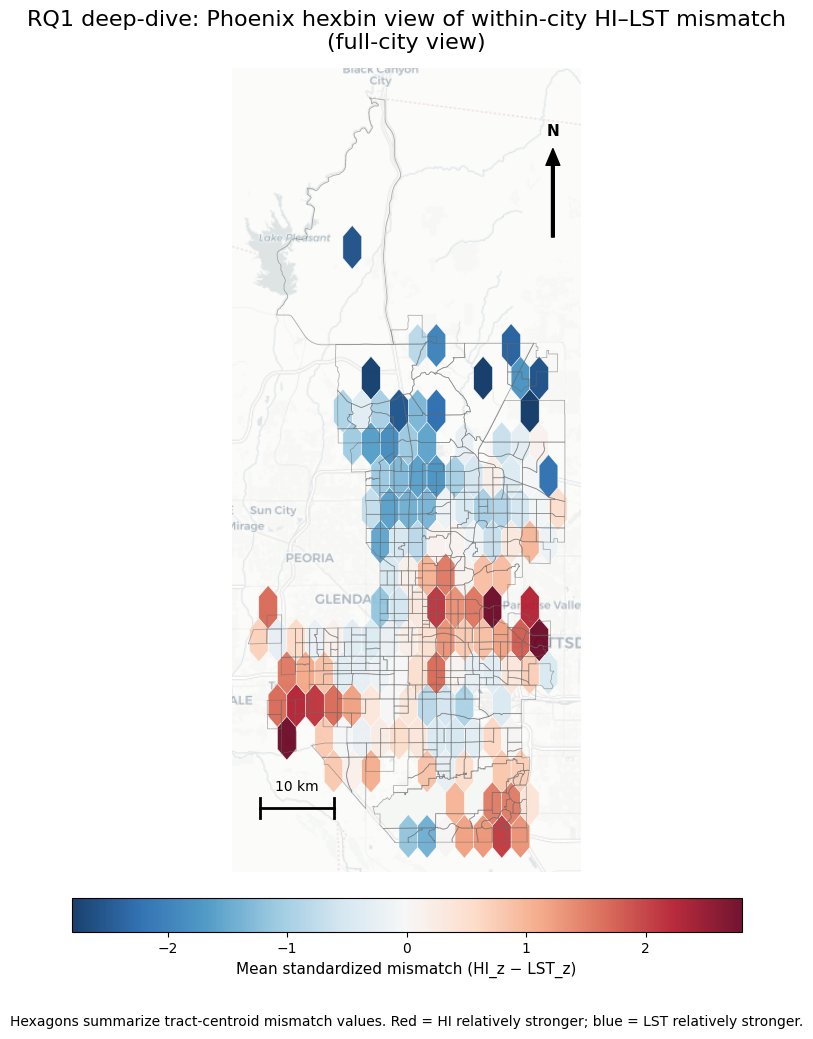

/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_gap_hexbin_phoenix_fullcity.png -> True


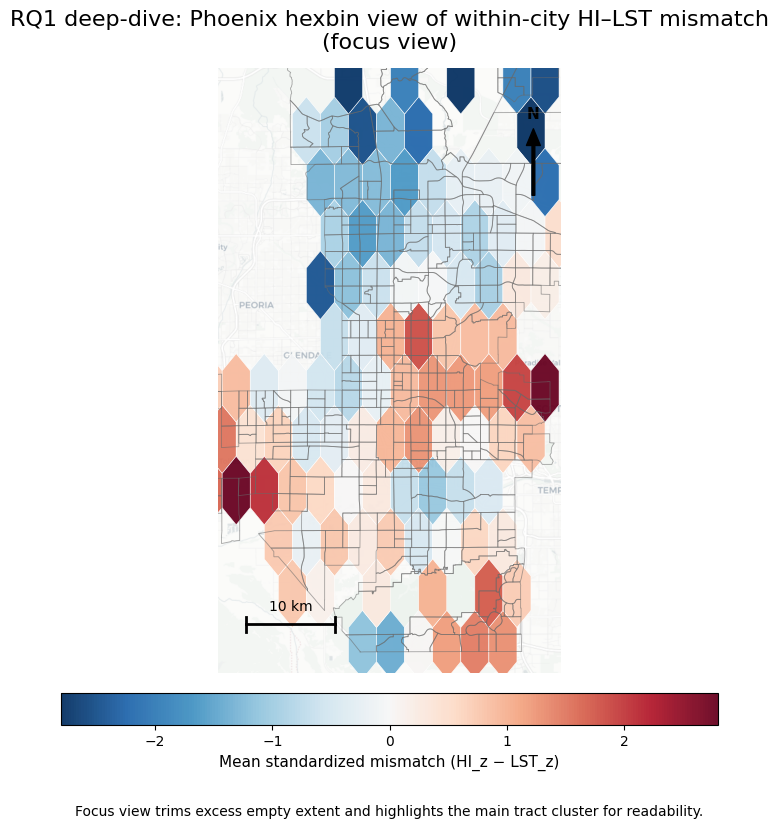

/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_gap_hexbin_phoenix_focus.png -> True


,city,n_valid,median_lst_c,median_hi_c,mean_gap_z,sd_gap_z,min_gap_z,max_gap_z,fullcity_fig,focus_fig
0,Phoenix,332,57.179,33.308,-0.0,1.191,-4.283,3.587,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...


/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_phoenix_hexbin_redraw_summary.csv -> True


In [9]:
# ============================================================
# Phoenix only: redraw hexbin better
# Output:
#   1) full city portrait version
#   2) focus/urban-core version
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import contextily as ctx

# -----------------------------
# 1) project root
# -----------------------------
def find_project_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p] + list(p.parents):
        if (cand / "data_processed").exists() and (cand / "outputs").exists():
            return cand
    return Path.cwd().resolve()

PROJECT_ROOT = find_project_root()
OUT_DIR = PROJECT_ROOT / "outputs" / "pilot"
FIG_DIR = PROJECT_ROOT / "figures" / "pilot"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)

# -----------------------------
# 2) read registry
# -----------------------------
registry_candidates = [
    OUT_DIR / "rq1_city_registry_template.csv",
    OUT_DIR / "rq1_city_registry_detected.csv",
]

registry_path = None
for fp in registry_candidates:
    if fp.exists():
        registry_path = fp
        break

if registry_path is None:
    raise FileNotFoundError("Cannot find rq1_city_registry_template.csv or rq1_city_registry_detected.csv")

registry = pd.read_csv(registry_path)

def to_bool(x):
    return str(x).strip().lower() in {"true", "1", "yes", "y"}

if "is_active" in registry.columns:
    registry = registry[registry["is_active"].apply(to_bool)].copy()

phx_row = registry[registry["city"].astype(str).str.lower() == "phoenix"]
if phx_row.empty:
    raise ValueError("Phoenix row not found in registry")

phx_row = phx_row.iloc[0]
display(pd.DataFrame([phx_row]))

# -----------------------------
# 3) helpers
# -----------------------------
def resolve_path(p):
    p = Path(str(p))
    if p.is_absolute():
        return p
    return PROJECT_ROOT / p

def choose_existing_col(gdf, candidates):
    for c in candidates:
        if c in gdf.columns:
            return c
    return None

def zscore(s):
    s = pd.to_numeric(s, errors="coerce")
    sd = s.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.mean()) / sd

def add_north_arrow(ax, loc=(0.92, 0.90), size=0.11):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    dx = x1 - x0
    dy = y1 - y0
    x = x0 + dx * loc[0]
    y = y0 + dy * loc[1]
    ax.annotate(
        "",
        xy=(x, y),
        xytext=(x, y - dy * size),
        arrowprops=dict(facecolor="black", edgecolor="black", width=2, headwidth=10),
        zorder=10
    )
    ax.text(x, y + dy * 0.012, "N", ha="center", va="bottom", fontsize=11, fontweight="bold")

def add_scalebar(ax, length_km=10, loc=(0.08, 0.08), lw=2):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    dx = x1 - x0
    dy = y1 - y0
    xb = x0 + dx * loc[0]
    yb = y0 + dy * loc[1]
    length_m = length_km * 1000

    ax.plot([xb, xb + length_m], [yb, yb], color="black", lw=lw, zorder=10)
    ax.plot([xb, xb], [yb - dy * 0.012, yb + dy * 0.012], color="black", lw=lw, zorder=10)
    ax.plot([xb + length_m, xb + length_m], [yb - dy * 0.012, yb + dy * 0.012], color="black", lw=lw, zorder=10)
    ax.text(xb + length_m / 2, yb + dy * 0.018, f"{length_km} km", ha="center", va="bottom", fontsize=10)

# -----------------------------
# 4) load phoenix gpkg
# -----------------------------
gpkg_path = resolve_path(phx_row["main_gpkg"])
if not gpkg_path.exists():
    raise FileNotFoundError(f"Phoenix main_gpkg not found: {gpkg_path}")

gdf = gpd.read_file(gpkg_path)

lst_col = phx_row["lst_col"] if str(phx_row["lst_col"]) in gdf.columns else choose_existing_col(
    gdf, ["lst_c", "lst", "LST_C", "LST", "summer_lst_c"]
)
hi_col = phx_row["hi_col"] if str(phx_row["hi_col"]) in gdf.columns else choose_existing_col(
    gdf, ["hi_c", "hi", "HI_C", "HI", "summer_hi_c"]
)
pop_col = phx_row["pop_col"] if str(phx_row["pop_col"]) in gdf.columns else choose_existing_col(
    gdf, ["total_population", "population", "pop_total"]
)

if lst_col is None or hi_col is None:
    raise KeyError("Cannot find lst_col or hi_col in Phoenix data")

gdf[lst_col] = pd.to_numeric(gdf[lst_col], errors="coerce")
gdf[hi_col] = pd.to_numeric(gdf[hi_col], errors="coerce")

gdf = gdf[gdf.geometry.notna()].copy()
valid = gdf[gdf[lst_col].notna() & gdf[hi_col].notna()].copy()

valid["lst_z"] = zscore(valid[lst_col])
valid["hi_z"] = zscore(valid[hi_col])
valid["gap_z"] = valid["hi_z"] - valid["lst_z"]

gdf = gdf.to_crs(epsg=3857)
valid = valid.to_crs(epsg=3857)

cent = valid.geometry.centroid
valid["x"] = cent.x
valid["y"] = cent.y

display(pd.DataFrame([{
    "city": "Phoenix",
    "rows_total": len(gdf),
    "rows_valid": len(valid),
    "lst_col": lst_col,
    "hi_col": hi_col,
    "median_lst_c": round(valid[lst_col].median(), 3),
    "median_hi_c": round(valid[hi_col].median(), 3),
}]))

# -----------------------------
# 5) shared scale for phoenix-only
# -----------------------------
vlim = float(np.nanquantile(np.abs(valid["gap_z"]), 0.98))
if not np.isfinite(vlim) or vlim <= 0:
    vlim = float(np.nanmax(np.abs(valid["gap_z"])))
if not np.isfinite(vlim) or vlim <= 0:
    vlim = 1.0

norm = TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)

# -----------------------------
# 6) full-city portrait figure
# -----------------------------
fig, ax = plt.subplots(figsize=(7.0, 10.8))

xmin, ymin, xmax, ymax = gdf.total_bounds
pad_x = (xmax - xmin) * 0.05
pad_y = (ymax - ymin) * 0.04

ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, attribution=False, alpha=0.75)
except Exception as e:
    print("Basemap skipped:", e)

hb = ax.hexbin(
    valid["x"], valid["y"],
    C=valid["gap_z"],
    reduce_C_function=np.mean,
    gridsize=16,          # Phoenix 用更少更大的 bins
    mincnt=1,
    cmap="RdBu_r",
    norm=norm,
    linewidths=0.35,
    edgecolors="white",
    alpha=0.92,
    zorder=3
)

gdf.boundary.plot(ax=ax, color="dimgray", linewidth=0.55, alpha=0.55, zorder=4)

add_north_arrow(ax, loc=(0.92, 0.90), size=0.11)
add_scalebar(ax, length_km=10, loc=(0.08, 0.08), lw=2)

ax.set_axis_off()
ax.set_title("RQ1 deep-dive: Phoenix hexbin view of within-city HI–LST mismatch\n(full-city view)",
             fontsize=16, pad=14)

cbar = fig.colorbar(hb, ax=ax, orientation="horizontal", fraction=0.05, pad=0.03)
cbar.set_label("Mean standardized mismatch (HI_z − LST_z)", fontsize=11)

fig.text(
    0.5, 0.015,
    "Hexagons summarize tract-centroid mismatch values. Red = HI relatively stronger; blue = LST relatively stronger.",
    ha="center", fontsize=10
)

fig.tight_layout(rect=[0, 0.05, 1, 0.97])

fig_out_full = FIG_DIR / "rq1_gap_hexbin_phoenix_fullcity.png"
fig.savefig(fig_out_full, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(fig_out_full, "->", fig_out_full.exists())

# -----------------------------
# 7) focus view (crop to where tracts cluster)
# -----------------------------
# 这里不是乱改形状，而是聚焦有效 tract 的主要分布区，更适合展示
qx_low, qx_high = valid["x"].quantile([0.03, 0.97])
qy_low, qy_high = valid["y"].quantile([0.03, 0.97])

dx = qx_high - qx_low
dy = qy_high - qy_low

focus_xmin = qx_low - dx * 0.10
focus_xmax = qx_high + dx * 0.10
focus_ymin = qy_low - dy * 0.10
focus_ymax = qy_high + dy * 0.10

fig, ax = plt.subplots(figsize=(8.6, 8.6))

ax.set_xlim(focus_xmin, focus_xmax)
ax.set_ylim(focus_ymin, focus_ymax)

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, attribution=False, alpha=0.75)
except Exception as e:
    print("Basemap skipped:", e)

hb2 = ax.hexbin(
    valid["x"], valid["y"],
    C=valid["gap_z"],
    reduce_C_function=np.mean,
    gridsize=13,          # focus 图再稍微大一点
    mincnt=1,
    cmap="RdBu_r",
    norm=norm,
    linewidths=0.40,
    edgecolors="white",
    alpha=0.94,
    zorder=3
)

gdf.boundary.plot(ax=ax, color="dimgray", linewidth=0.65, alpha=0.55, zorder=4)

add_north_arrow(ax, loc=(0.92, 0.90), size=0.11)
add_scalebar(ax, length_km=10, loc=(0.08, 0.08), lw=2)

ax.set_axis_off()
ax.set_title("RQ1 deep-dive: Phoenix hexbin view of within-city HI–LST mismatch\n(focus view)",
             fontsize=16, pad=14)

cbar2 = fig.colorbar(hb2, ax=ax, orientation="horizontal", fraction=0.05, pad=0.03)
cbar2.set_label("Mean standardized mismatch (HI_z − LST_z)", fontsize=11)

fig.text(
    0.5, 0.015,
    "Focus view trims excess empty extent and highlights the main tract cluster for readability.",
    ha="center", fontsize=10
)

fig.tight_layout(rect=[0, 0.05, 1, 0.97])

fig_out_focus = FIG_DIR / "rq1_gap_hexbin_phoenix_focus.png"
fig.savefig(fig_out_focus, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(fig_out_focus, "->", fig_out_focus.exists())

# -----------------------------
# 8) summary
# -----------------------------
summary = pd.DataFrame([
    {
        "city": "Phoenix",
        "n_valid": len(valid),
        "median_lst_c": round(valid[lst_col].median(), 3),
        "median_hi_c": round(valid[hi_col].median(), 3),
        "mean_gap_z": round(valid["gap_z"].mean(), 3),
        "sd_gap_z": round(valid["gap_z"].std(ddof=0), 3),
        "min_gap_z": round(valid["gap_z"].min(), 3),
        "max_gap_z": round(valid["gap_z"].max(), 3),
        "fullcity_fig": str(fig_out_full),
        "focus_fig": str(fig_out_focus),
    }
])

display(summary)

summary_out = OUT_DIR / "rq1_phoenix_hexbin_redraw_summary.csv"
summary.to_csv(summary_out, index=False)
print(summary_out, "->", summary_out.exists())

PROJECT_ROOT: /Users/yufeizhou/Desktop/heat-exposure-compare


,city,is_active,status,main_gpkg,boundary_file,lst_col,hi_col,pop_col,geoid_col,notes
1,Phoenix,True,ready,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...,lst_c,hi_c,total_population,GEOID,Auto-filled from detected registry


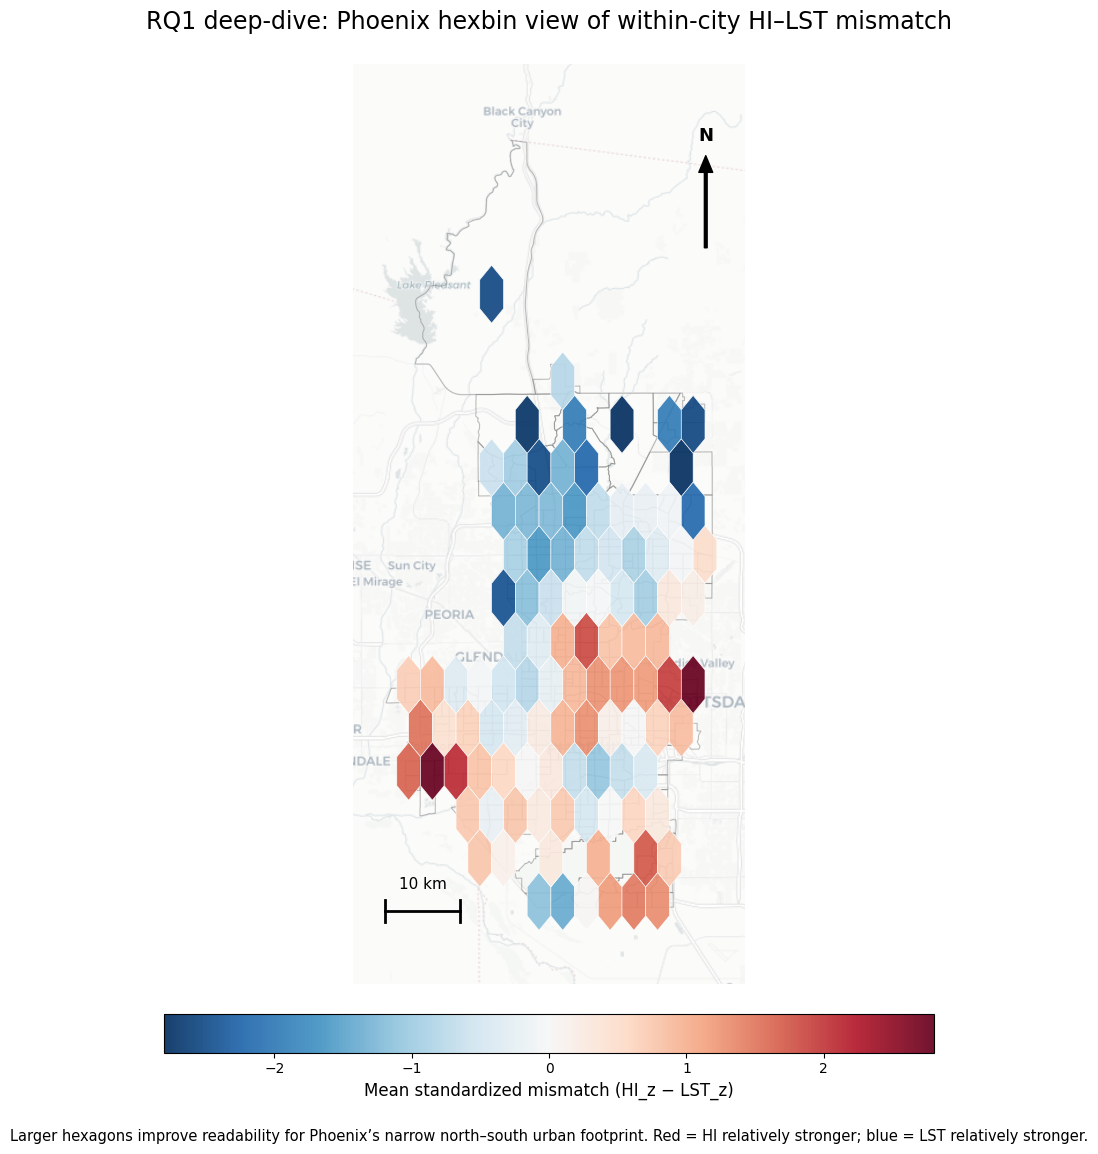

/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_gap_hexbin_phoenix_single_clean.png -> True


In [11]:
# ============================================================
# Phoenix single-city roomy hexbin map
# Put this in 08_rq1_deep_dive_maps.ipynb
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import contextily as ctx

# -----------------------------
# 1) Find project root
# -----------------------------
def find_project_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p] + list(p.parents):
        if (cand / "data_processed").exists() and (cand / "outputs").exists():
            return cand
    return Path.cwd().resolve()

PROJECT_ROOT = find_project_root()
OUT_DIR = PROJECT_ROOT / "outputs" / "pilot"
FIG_DIR = PROJECT_ROOT / "figures" / "pilot"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)

# -----------------------------
# 2) Load city registry
# -----------------------------
registry_candidates = [
    OUT_DIR / "rq1_city_registry_template.csv",
    OUT_DIR / "rq1_city_registry_detected.csv",
]

registry_path = None
for fp in registry_candidates:
    if fp.exists():
        registry_path = fp
        break

if registry_path is None:
    raise FileNotFoundError("Cannot find city registry csv")

registry = pd.read_csv(registry_path)

def to_bool(x):
    return str(x).strip().lower() in {"true", "1", "yes", "y"}

if "is_active" in registry.columns:
    registry = registry[registry["is_active"].apply(to_bool)].copy()

phx_row = registry[registry["city"].astype(str).str.lower() == "phoenix"]
if phx_row.empty:
    raise ValueError("Phoenix row not found in registry")
phx_row = phx_row.iloc[0]

display(pd.DataFrame([phx_row]))

# -----------------------------
# 3) Helper functions
# -----------------------------
def resolve_path(p):
    p = Path(str(p))
    if p.is_absolute():
        return p
    return PROJECT_ROOT / p

def zscore(s):
    s = pd.to_numeric(s, errors="coerce")
    sd = s.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.mean()) / sd

def add_north_arrow(ax, loc=(0.92, 0.90), size=0.10):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    dx = x1 - x0
    dy = y1 - y0
    x = x0 + dx * loc[0]
    y = y0 + dy * loc[1]
    ax.annotate(
        "",
        xy=(x, y),
        xytext=(x, y - dy * size),
        arrowprops=dict(facecolor="black", edgecolor="black", width=2, headwidth=10),
        zorder=20
    )
    ax.text(x, y + dy * 0.012, "N", ha="center", va="bottom",
            fontsize=13, fontweight="bold", zorder=20)

def add_scalebar(ax, length_km=10, loc=(0.08, 0.08), lw=2):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    dx = x1 - x0
    dy = y1 - y0
    xb = x0 + dx * loc[0]
    yb = y0 + dy * loc[1]
    length_m = length_km * 1000

    ax.plot([xb, xb + length_m], [yb, yb], color="black", lw=lw, zorder=20)
    ax.plot([xb, xb], [yb - dy * 0.012, yb + dy * 0.012], color="black", lw=lw, zorder=20)
    ax.plot([xb + length_m, xb + length_m], [yb - dy * 0.012, yb + dy * 0.012],
            color="black", lw=lw, zorder=20)
    ax.text(xb + length_m / 2, yb + dy * 0.020, f"{length_km} km",
            ha="center", va="bottom", fontsize=11, zorder=20)

# -----------------------------
# 4) Load Phoenix data
# -----------------------------
gpkg_path = resolve_path(phx_row["main_gpkg"])
if not gpkg_path.exists():
    raise FileNotFoundError(f"Phoenix gpkg not found: {gpkg_path}")

gdf = gpd.read_file(gpkg_path)

lst_col = str(phx_row["lst_col"])
hi_col = str(phx_row["hi_col"])

if lst_col not in gdf.columns:
    raise KeyError(f"{lst_col} not found in columns")
if hi_col not in gdf.columns:
    raise KeyError(f"{hi_col} not found in columns")

gdf[lst_col] = pd.to_numeric(gdf[lst_col], errors="coerce")
gdf[hi_col] = pd.to_numeric(gdf[hi_col], errors="coerce")

gdf = gdf[gdf.geometry.notna()].copy()
valid = gdf[gdf[lst_col].notna() & gdf[hi_col].notna()].copy()

if valid.empty:
    raise ValueError("No valid Phoenix rows with both LST and HI")

# standardized mismatch
valid["lst_z"] = zscore(valid[lst_col])
valid["hi_z"] = zscore(valid[hi_col])
valid["gap_z"] = valid["hi_z"] - valid["lst_z"]

# project for plotting
gdf = gdf.to_crs(epsg=3857)
valid = valid.to_crs(epsg=3857)

cent = valid.geometry.centroid
valid["x"] = cent.x
valid["y"] = cent.y

# -----------------------------
# 5) Better extent for Phoenix
# Key point:
#   Phoenix should be portrait, not forced into Houston-like wide layout
# -----------------------------
xmin0, ymin0, xmax0, ymax0 = valid.total_bounds
w = xmax0 - xmin0
h = ymax0 - ymin0

# modest padding
pad_x = w * 0.10
pad_y = h * 0.10

xmin = xmin0 - pad_x
xmax = xmax0 + pad_x
ymin = ymin0 - pad_y
ymax = ymax0 + pad_y

# -----------------------------
# 6) Color normalization
# -----------------------------
vlim = float(np.nanquantile(np.abs(valid["gap_z"]), 0.98))
if not np.isfinite(vlim) or vlim <= 0:
    vlim = 1.0

norm = TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)

# -----------------------------
# 7) Plot
# IMPORTANT:
#   Use portrait canvas
#   Do NOT force square/wide canvas
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 12))

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")

# basemap
try:
    ctx.add_basemap(
        ax,
        source=ctx.providers.CartoDB.Positron,
        attribution=False,
        alpha=0.75
    )
except Exception as e:
    print("Basemap skipped:", e)

# boundary first
gdf.boundary.plot(ax=ax, color="gray", linewidth=0.8, alpha=0.5, zorder=4)

# larger, fewer hexagons
hb = ax.hexbin(
    valid["x"], valid["y"],
    C=valid["gap_z"],
    reduce_C_function=np.mean,
    gridsize=13,           # smaller number = bigger hexagons
    mincnt=1,
    cmap="RdBu_r",
    norm=norm,
    linewidths=0.45,
    edgecolors="white",
    alpha=0.92,
    zorder=6
)

add_north_arrow(ax, loc=(0.90, 0.90), size=0.10)
add_scalebar(ax, length_km=10, loc=(0.08, 0.08), lw=2)

ax.set_axis_off()
ax.set_title(
    "RQ1 deep-dive: Phoenix hexbin view of within-city HI–LST mismatch",
    fontsize=17,
    pad=14
)

cbar = fig.colorbar(hb, ax=ax, orientation="horizontal", fraction=0.045, pad=0.03)
cbar.set_label("Mean standardized mismatch (HI_z − LST_z)", fontsize=12)

fig.text(
    0.5, 0.015,
    "Larger hexagons improve readability for Phoenix’s narrow north–south urban footprint. "
    "Red = HI relatively stronger; blue = LST relatively stronger.",
    ha="center",
    fontsize=10.5
)

fig.tight_layout(rect=[0, 0.04, 1, 0.97])

fig_out = FIG_DIR / "rq1_gap_hexbin_phoenix_single_clean.png"
fig.savefig(fig_out, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(fig_out, "->", fig_out.exists())

In [12]:
# ============================================================
# 08 / KDE hotspot maps helpers
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde
import contextily as ctx

# ----------------------------
# basic helpers
# ----------------------------
def find_project_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p] + list(p.parents):
        if (cand / "data_processed").exists() and (cand / "outputs").exists():
            return cand
    return Path.cwd().resolve()

PROJECT_ROOT = find_project_root()
OUT_DIR = PROJECT_ROOT / "outputs" / "pilot"
FIG_DIR = PROJECT_ROOT / "figures" / "pilot"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)

def resolve_path(p):
    p = Path(str(p))
    if p.is_absolute():
        return p
    return PROJECT_ROOT / p

def to_bool(x):
    return str(x).strip().lower() in {"true", "1", "yes", "y"}

def zscore(s):
    s = pd.to_numeric(s, errors="coerce")
    sd = s.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.mean()) / sd

def load_registry():
    candidates = [
        OUT_DIR / "rq1_city_registry_template.csv",
        OUT_DIR / "rq1_city_registry_detected.csv",
    ]
    for fp in candidates:
        if fp.exists():
            reg = pd.read_csv(fp)
            if "is_active" in reg.columns:
                reg = reg[reg["is_active"].apply(to_bool)].copy()
            return reg, fp
    raise FileNotFoundError("No city registry csv found in outputs/pilot")

registry, registry_path = load_registry()
print("Using registry:", registry_path)

def get_city_row(city_name):
    row = registry[registry["city"].astype(str).str.lower() == city_name.lower()]
    if row.empty:
        raise ValueError(f"{city_name} not found in registry")
    return row.iloc[0]

def load_city_data(city_name):
    row = get_city_row(city_name)

    gpkg_path = resolve_path(row["main_gpkg"])
    if not gpkg_path.exists():
        raise FileNotFoundError(f"main_gpkg not found: {gpkg_path}")

    gdf = gpd.read_file(gpkg_path)

    lst_col = str(row["lst_col"])
    hi_col = str(row["hi_col"])

    if lst_col not in gdf.columns:
        raise KeyError(f"{city_name}: column '{lst_col}' not found")
    if hi_col not in gdf.columns:
        raise KeyError(f"{city_name}: column '{hi_col}' not found")

    gdf = gdf[gdf.geometry.notna()].copy()
    gdf[lst_col] = pd.to_numeric(gdf[lst_col], errors="coerce")
    gdf[hi_col] = pd.to_numeric(gdf[hi_col], errors="coerce")

    # project to Web Mercator for basemap and distance-based plotting
    gdf = gdf.to_crs(epsg=3857)

    valid = gdf[gdf[lst_col].notna() & gdf[hi_col].notna()].copy()
    if valid.empty:
        raise ValueError(f"{city_name}: no valid rows with both LST and HI")

    valid["lst_z"] = zscore(valid[lst_col])
    valid["hi_z"] = zscore(valid[hi_col])
    valid["gap_z"] = valid["hi_z"] - valid["lst_z"]

    cent = valid.geometry.centroid
    valid["x"] = cent.x
    valid["y"] = cent.y

    return row, gdf, valid

def add_north_arrow(ax, loc=(0.92, 0.90), size=0.10):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    dx = x1 - x0
    dy = y1 - y0

    x = x0 + dx * loc[0]
    y = y0 + dy * loc[1]

    ax.annotate(
        "",
        xy=(x, y),
        xytext=(x, y - dy * size),
        arrowprops=dict(facecolor="black", edgecolor="black", width=2, headwidth=10),
        zorder=30
    )
    ax.text(x, y + dy * 0.012, "N", ha="center", va="bottom",
            fontsize=14, fontweight="bold", zorder=30)

def add_scalebar(ax, length_km=10, loc=(0.08, 0.08), lw=2):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    dx = x1 - x0
    dy = y1 - y0

    xb = x0 + dx * loc[0]
    yb = y0 + dy * loc[1]
    length_m = length_km * 1000

    ax.plot([xb, xb + length_m], [yb, yb], color="black", lw=lw, zorder=30)
    ax.plot([xb, xb], [yb - dy * 0.012, yb + dy * 0.012], color="black", lw=lw, zorder=30)
    ax.plot([xb + length_m, xb + length_m], [yb - dy * 0.012, yb + dy * 0.012], color="black", lw=lw, zorder=30)
    ax.text(xb + length_m / 2, yb + dy * 0.018, f"{length_km} km",
            ha="center", va="bottom", fontsize=11, zorder=30)

def compute_kde_surface(points_df, x_col="x", y_col="y", weight_col="w",
                        bounds=None, grid_size=220, bw_method=0.22):
    """
    Returns xx, yy, zz KDE surface.
    """
    if points_df.empty or len(points_df) < 3:
        return None, None, None

    xmin, ymin, xmax, ymax = bounds
    xs = np.linspace(xmin, xmax, grid_size)
    ys = np.linspace(ymin, ymax, grid_size)
    xx, yy = np.meshgrid(xs, ys)

    coords = np.vstack([points_df[x_col].values, points_df[y_col].values])
    weights = points_df[weight_col].values

    kde = gaussian_kde(coords, weights=weights, bw_method=bw_method)
    zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

    return xx, yy, zz

def choose_levels(zz, q_low=0.60, q_high=0.98, n=5):
    vals = zz[np.isfinite(zz) & (zz > 0)]
    if len(vals) < 10:
        return None
    lo = np.quantile(vals, q_low)
    hi = np.quantile(vals, q_high)
    if hi <= lo:
        lo = vals.min()
        hi = vals.max()
    if hi <= 0:
        return None
    return np.linspace(lo, hi, n)

def plot_city_kde(city_name,
                  figsize=(10, 8),
                  grid_size=220,
                  bw_method=0.22,
                  hi_q=0.75,
                  lst_q=0.25,
                  pad_frac=0.10,
                  basemap_alpha=0.80,
                  save_name=None):
    """
    Single-city KDE hotspot map.
    Red = HI-dominant hotspot density
    Blue = LST-dominant hotspot density
    """
    row, gdf, valid = load_city_data(city_name)

    # city extent
    xmin0, ymin0, xmax0, ymax0 = valid.total_bounds
    w = xmax0 - xmin0
    h = ymax0 - ymin0

    xmin = xmin0 - w * pad_frac
    xmax = xmax0 + w * pad_frac
    ymin = ymin0 - h * pad_frac
    ymax = ymax0 + h * pad_frac
    bounds = (xmin, ymin, xmax, ymax)

    # strongest positive / negative tails
    hi_thr = valid["gap_z"].quantile(hi_q)
    lst_thr = valid["gap_z"].quantile(lst_q)

    hi_pts = valid[valid["gap_z"] >= hi_thr].copy()
    lst_pts = valid[valid["gap_z"] <= lst_thr].copy()

    hi_pts["w"] = hi_pts["gap_z"].abs()
    lst_pts["w"] = lst_pts["gap_z"].abs()

    xx_hi, yy_hi, zz_hi = compute_kde_surface(
        hi_pts, bounds=bounds, grid_size=grid_size, bw_method=bw_method
    )
    xx_lo, yy_lo, zz_lo = compute_kde_surface(
        lst_pts, bounds=bounds, grid_size=grid_size, bw_method=bw_method
    )

    fig, ax = plt.subplots(figsize=figsize)

    # extent first
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")

    # basemap (optional)
    try:
        ctx.add_basemap(
            ax,
            source=ctx.providers.CartoDB.Positron,
            attribution=False,
            alpha=basemap_alpha,
            reset_extent=False
        )
    except Exception as e:
        print(f"{city_name}: basemap skipped ->", e)

    # tract outlines
    gdf.boundary.plot(ax=ax, color="gray", linewidth=0.7, alpha=0.45, zorder=5)

    # KDE fill + contour: LST-dominant (blue)
    if zz_lo is not None:
        lo_levels = choose_levels(zz_lo, q_low=0.60, q_high=0.98, n=5)
        if lo_levels is not None:
            ax.contourf(
                xx_lo, yy_lo, zz_lo,
                levels=lo_levels,
                cmap="Blues",
                alpha=0.30,
                zorder=10
            )
            ax.contour(
                xx_lo, yy_lo, zz_lo,
                levels=lo_levels,
                colors="#4A76C5",
                linewidths=1.2,
                alpha=0.75,
                zorder=11
            )

    # KDE fill + contour: HI-dominant (red)
    if zz_hi is not None:
        hi_levels = choose_levels(zz_hi, q_low=0.60, q_high=0.98, n=5)
        if hi_levels is not None:
            ax.contourf(
                xx_hi, yy_hi, zz_hi,
                levels=hi_levels,
                cmap="Reds",
                alpha=0.28,
                zorder=12
            )
            ax.contour(
                xx_hi, yy_hi, zz_hi,
                levels=hi_levels,
                colors="#D85A4F",
                linewidths=1.2,
                alpha=0.75,
                zorder=13
            )

    add_north_arrow(ax, loc=(0.92, 0.90), size=0.10)
    add_scalebar(ax, length_km=10, loc=(0.08, 0.08), lw=2)

    ax.set_axis_off()
    ax.set_title(
        f"RQ1 deep-dive: {city_name} KDE hotspot map of HI–LST mismatch",
        fontsize=18,
        pad=14
    )

    legend_handles = [
        Patch(facecolor="#F2A6A1", edgecolor="#D85A4F", alpha=0.60,
              label="HI-dominant hotspot density"),
        Patch(facecolor="#9FC5F8", edgecolor="#4A76C5", alpha=0.60,
              label="LST-dominant hotspot density"),
    ]
    ax.legend(
        handles=legend_handles,
        loc="lower left",
        frameon=True,
        framealpha=0.95,
        fontsize=10
    )

    fig.text(
        0.5, 0.015,
        "KDE is estimated from tract centroids in the strongest mismatch tails "
        f"(top 25% and bottom 25% of standardized HI_z − LST_z), weighted by |HI_z − LST_z|.",
        ha="center",
        fontsize=10.5
    )

    fig.tight_layout(rect=[0, 0.04, 1, 0.97])

    if save_name is None:
        save_name = f"rq1_kde_hotspot_{city_name.lower()}.png"

    fig_out = FIG_DIR / save_name
    fig.savefig(fig_out, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    summary = pd.DataFrame([{
        "city": city_name,
        "n_valid": int(len(valid)),
        "hi_q_threshold": round(float(hi_thr), 3),
        "lst_q_threshold": round(float(lst_thr), 3),
        "n_hi_tail": int(len(hi_pts)),
        "n_lst_tail": int(len(lst_pts)),
        "bw_method": bw_method,
        "grid_size": grid_size,
        "figure_out": str(fig_out)
    }])
    display(summary)

    summary_out = OUT_DIR / f"rq1_kde_summary_{city_name.lower()}.csv"
    summary.to_csv(summary_out, index=False)

    print(fig_out, "->", fig_out.exists())
    print(summary_out, "->", summary_out.exists())

    return {
        "row": row,
        "gdf": gdf,
        "valid": valid,
        "hi_pts": hi_pts,
        "lst_pts": lst_pts,
        "summary": summary,
        "figure_out": fig_out,
        "summary_out": summary_out
    }

PROJECT_ROOT: /Users/yufeizhou/Desktop/heat-exposure-compare
Using registry: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_city_registry_template.csv


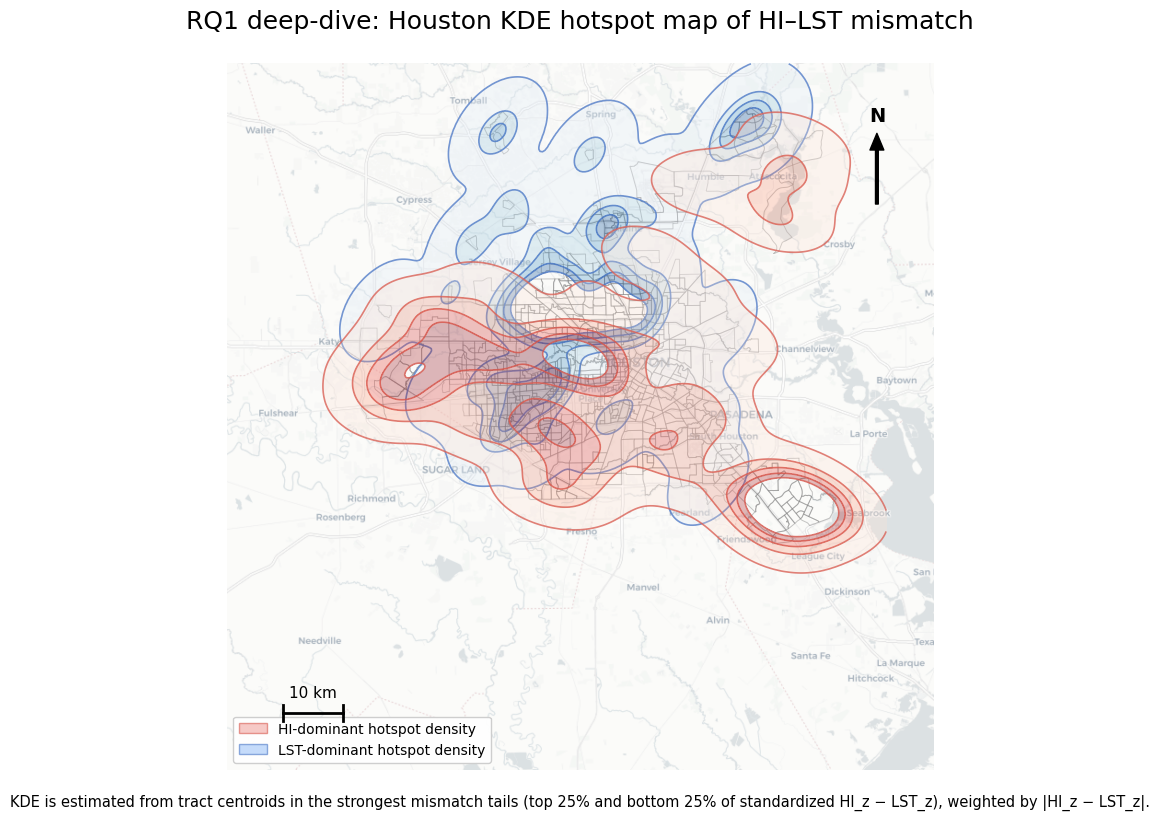

,city,n_valid,hi_q_threshold,lst_q_threshold,n_hi_tail,n_lst_tail,bw_method,grid_size,figure_out
0,Houston,549,0.473,-0.65,138,138,0.2,240,/Users/yufeizhou/Desktop/heat-exposure-compare...


/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_kde_hotspot_houston.png -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_kde_summary_houston.csv -> True


In [13]:
# ============================================================
# 08 / Houston KDE hotspot map
# ============================================================

hou_kde = plot_city_kde(
    city_name="Houston",
    figsize=(11, 8.5),     # Houston 适合横版
    grid_size=240,
    bw_method=0.20,        # bandwidth（带宽）稍小一点，保留空间细节
    hi_q=0.75,
    lst_q=0.25,
    pad_frac=0.10,
    basemap_alpha=0.80,
    save_name="rq1_kde_hotspot_houston.png"
)

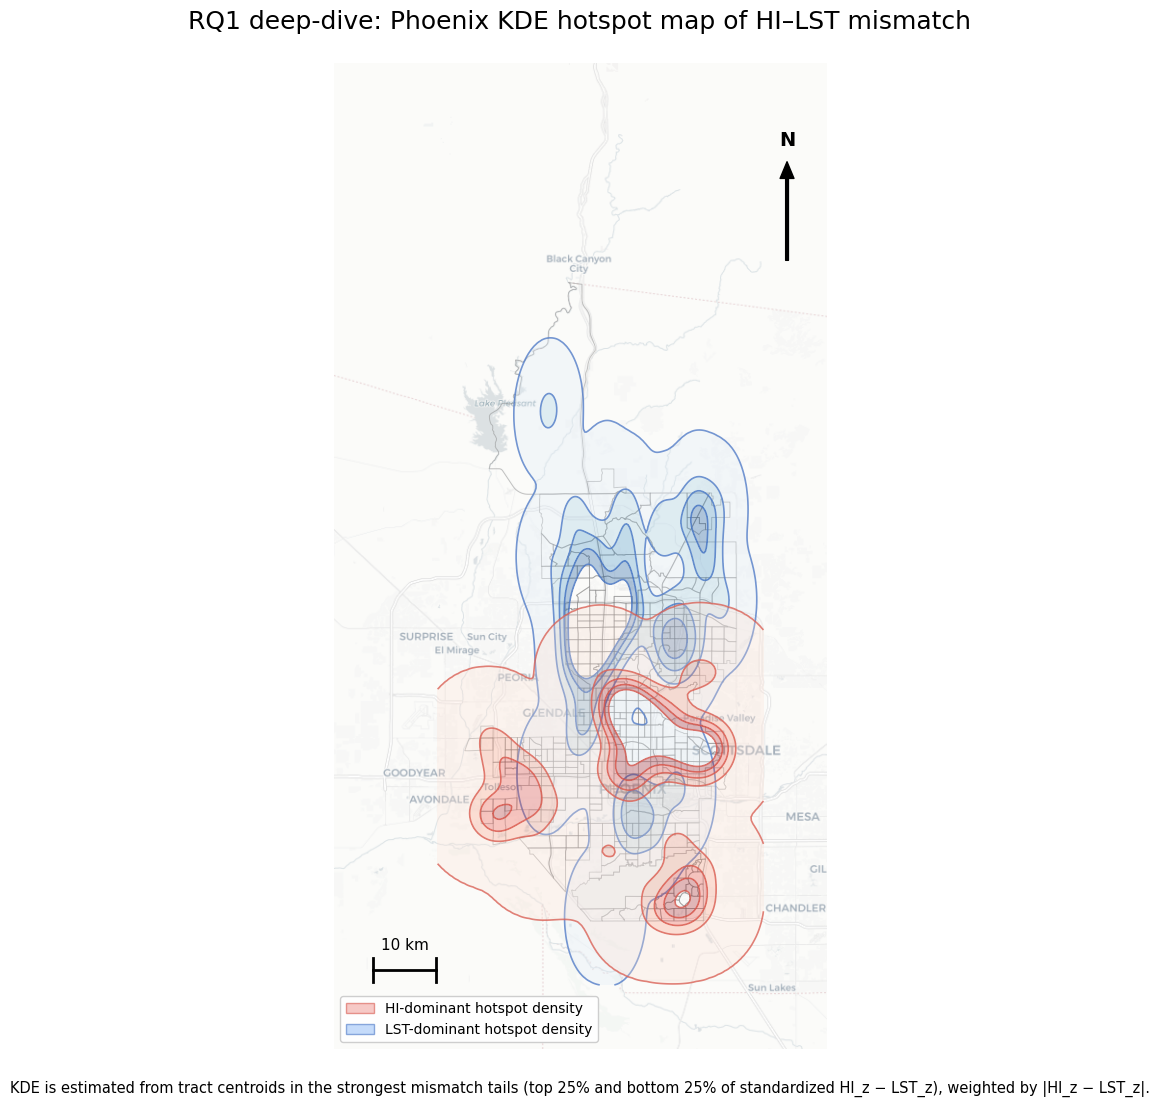

,city,n_valid,hi_q_threshold,lst_q_threshold,n_hi_tail,n_lst_tail,bw_method,grid_size,figure_out
0,Phoenix,332,0.727,-0.764,83,83,0.24,220,/Users/yufeizhou/Desktop/heat-exposure-compare...


/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_kde_hotspot_phoenix.png -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_kde_summary_phoenix.csv -> True


In [14]:
# ============================================================
# 08 / Phoenix KDE hotspot map
# ============================================================

phx_kde = plot_city_kde(
    city_name="Phoenix",
    figsize=(8.5, 11.5),   # Phoenix 用竖版，不要硬挤成宽图
    grid_size=220,
    bw_method=0.24,        # bandwidth 稍大一点，让轮廓更平滑、更好看
    hi_q=0.75,
    lst_q=0.25,
    pad_frac=0.10,
    basemap_alpha=0.80,
    save_name="rq1_kde_hotspot_phoenix.png"
)

In [15]:
# ============================================================
# 08 / Cell A
# Threshold stability map (阈值稳定性地图)
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

try:
    import contextily as ctx
    HAS_CTX = True
except Exception:
    HAS_CTX = False

# ---------- project root ----------
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

OUT_DIR = PROJECT_ROOT / "outputs" / "pilot"
FIG_DIR = PROJECT_ROOT / "figures" / "pilot"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 先关 basemap，先确保稳定跑通
USE_BASEMAP = False

# Hotspot thresholds to test
TOP_PCTS = [10, 15, 20, 25, 30]

# 至少在 5 个阈值里重复出现 3 次，才叫 stable
MIN_STABLE_COUNT = 3

CITY_CFG = [
    {
        "city": "Houston",
        "slug": "houston",
        "gpkg": PROJECT_ROOT / "data_processed" / "houston" / "houston_master_with_lst_hi_fixed.gpkg",
        "lst_col": "lst_c",
        "hi_col": "hi_c",
        "geoid_col": "GEOID",
        "pop_col": "total_population",
    },
    {
        "city": "Phoenix",
        "slug": "phoenix",
        "gpkg": PROJECT_ROOT / "data_processed" / "phoenix" / "phoenix_master_with_lst_hi_fixed.gpkg",
        "lst_col": "lst_c",
        "hi_col": "hi_c",
        "geoid_col": "GEOID",
        "pop_col": "total_population",
    },
]

for cfg in CITY_CFG:
    print(cfg["city"], cfg["gpkg"].exists(), cfg["gpkg"])

Houston True /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_with_lst_hi_fixed.gpkg
Phoenix True /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_master_with_lst_hi_fixed.gpkg


In [16]:
# ============================================================
# 08 / Cell B
# Compute threshold stability
# ============================================================

def compute_threshold_stability(cfg, top_pcts=TOP_PCTS, min_stable_count=MIN_STABLE_COUNT):
    city = cfg["city"]
    slug = cfg["slug"]
    lst_col = cfg["lst_col"]
    hi_col = cfg["hi_col"]
    geoid_col = cfg["geoid_col"]
    pop_col = cfg["pop_col"]

    gdf = gpd.read_file(cfg["gpkg"]).copy()

    keep_cols = [c for c in [geoid_col, lst_col, hi_col, pop_col, "geometry"] if c in gdf.columns]
    gdf = gdf[keep_cols].copy()

    if gdf.crs is None:
        raise ValueError(f"{city}: CRS is missing.")

    # project to Web Mercator for mapping
    gdf = gdf.to_crs(3857)

    gdf["city"] = city
    gdf["valid_pair"] = gdf[lst_col].notna() & gdf[hi_col].notna()

    # counters
    gdf["lst_only_count"] = 0
    gdf["hi_only_count"] = 0
    gdf["overlap_count"] = 0

    threshold_rows = []

    valid = gdf["valid_pair"]
    valid_df = gdf.loc[valid, [lst_col, hi_col]].copy()

    for pct in top_pcts:
        q = 1 - pct / 100.0

        lst_thr = float(valid_df[lst_col].quantile(q))
        hi_thr = float(valid_df[hi_col].quantile(q))

        lst_hot = valid & (gdf[lst_col] >= lst_thr)
        hi_hot = valid & (gdf[hi_col] >= hi_thr)

        gdf[f"lst_hot_{pct}"] = lst_hot.astype(int)
        gdf[f"hi_hot_{pct}"] = hi_hot.astype(int)

        gdf[f"lst_only_{pct}"] = (lst_hot & ~hi_hot).astype(int)
        gdf[f"hi_only_{pct}"] = (hi_hot & ~lst_hot).astype(int)
        gdf[f"overlap_{pct}"] = (lst_hot & hi_hot).astype(int)

        gdf["lst_only_count"] += gdf[f"lst_only_{pct}"]
        gdf["hi_only_count"] += gdf[f"hi_only_{pct}"]
        gdf["overlap_count"] += gdf[f"overlap_{pct}"]

        threshold_rows.append({
            "city": city,
            "top_pct": pct,
            "lst_threshold": round(lst_thr, 3),
            "hi_threshold": round(hi_thr, 3),
            "lst_hot_n": int(lst_hot.sum()),
            "hi_hot_n": int(hi_hot.sum()),
            "lst_only_n": int((lst_hot & ~hi_hot).sum()),
            "hi_only_n": int((hi_hot & ~lst_hot).sum()),
            "overlap_n": int((lst_hot & hi_hot).sum()),
        })

    class_cols = ["lst_only_count", "hi_only_count", "overlap_count"]
    counts_arr = gdf[class_cols].to_numpy()

    gdf["any_hotspot_count"] = gdf[class_cols].sum(axis=1)
    gdf["max_count"] = gdf[class_cols].max(axis=1)
    gdf["stability_share"] = gdf["max_count"] / len(top_pcts)
    gdf["n_max_types"] = (counts_arr == gdf["max_count"].to_numpy()[:, None]).sum(axis=1)

    # final class
    gdf["dominant_stability"] = "Mixed / unstable"
    gdf.loc[~gdf["valid_pair"], "dominant_stability"] = "Missing"
    gdf.loc[gdf["valid_pair"] & (gdf["any_hotspot_count"] == 0), "dominant_stability"] = "Never hotspot"

    stable_mask = (
        gdf["valid_pair"]
        & (gdf["any_hotspot_count"] > 0)
        & (gdf["max_count"] >= min_stable_count)
        & (gdf["n_max_types"] == 1)
    )

    gdf.loc[
        stable_mask & (gdf["lst_only_count"] == gdf["max_count"]),
        "dominant_stability"
    ] = "Stable LST-only hotspot"

    gdf.loc[
        stable_mask & (gdf["hi_only_count"] == gdf["max_count"]),
        "dominant_stability"
    ] = "Stable HI-only hotspot"

    gdf.loc[
        stable_mask & (gdf["overlap_count"] == gdf["max_count"]),
        "dominant_stability"
    ] = "Stable overlap hotspot"

    city_summary = {
        "city": city,
        "n_total": int(len(gdf)),
        "n_valid": int(gdf["valid_pair"].sum()),
        "top_pcts_tested": ",".join(map(str, top_pcts)),
        "min_stable_count": int(min_stable_count),
        "stable_lst_only_n": int((gdf["dominant_stability"] == "Stable LST-only hotspot").sum()),
        "stable_hi_only_n": int((gdf["dominant_stability"] == "Stable HI-only hotspot").sum()),
        "stable_overlap_n": int((gdf["dominant_stability"] == "Stable overlap hotspot").sum()),
        "mixed_unstable_n": int((gdf["dominant_stability"] == "Mixed / unstable").sum()),
        "never_hotspot_n": int((gdf["dominant_stability"] == "Never hotspot").sum()),
        "missing_n": int((gdf["dominant_stability"] == "Missing").sum()),
    }

    # save city-level gpkg
    gpkg_out = OUT_DIR / f"rq1_threshold_stability_{slug}.gpkg"
    gdf.to_file(gpkg_out, driver="GPKG")

    thr_df = pd.DataFrame(threshold_rows)
    thr_csv_out = OUT_DIR / f"rq1_threshold_stability_thresholds_{slug}.csv"
    thr_df.to_csv(thr_csv_out, index=False)

    return gdf, pd.DataFrame([city_summary]), thr_df, gpkg_out, thr_csv_out


all_gdfs = {}
summary_list = []
threshold_list = []

for cfg in CITY_CFG:
    gdf_city, city_sum_df, thr_df, gpkg_out, thr_csv_out = compute_threshold_stability(cfg)
    all_gdfs[cfg["slug"]] = gdf_city
    summary_list.append(city_sum_df)
    threshold_list.append(thr_df)

    print(cfg["city"])
    print("  GPKG:", gpkg_out)
    print("  THRESHOLDS:", thr_csv_out)

summary_df = pd.concat(summary_list, ignore_index=True)
thresholds_df = pd.concat(threshold_list, ignore_index=True)

summary_csv = OUT_DIR / "rq1_threshold_stability_summary.csv"
thresholds_csv = OUT_DIR / "rq1_threshold_stability_all_thresholds.csv"

summary_df.to_csv(summary_csv, index=False)
thresholds_df.to_csv(thresholds_csv, index=False)

display(summary_df)
display(thresholds_df.head(10))

print(summary_csv, "->", summary_csv.exists())
print(thresholds_csv, "->", thresholds_csv.exists())

Houston
  GPKG: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_threshold_stability_houston.gpkg
  THRESHOLDS: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_threshold_stability_thresholds_houston.csv
Phoenix
  GPKG: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_threshold_stability_phoenix.gpkg
  THRESHOLDS: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_threshold_stability_thresholds_phoenix.csv


,city,n_total,n_valid,top_pcts_tested,min_stable_count,stable_lst_only_n,stable_hi_only_n,stable_overlap_n,mixed_unstable_n,never_hotspot_n,missing_n
0,Houston,654,549,"10,15,20,25,30",3,64,92,46,79,268,105
1,Phoenix,373,332,"10,15,20,25,30",3,34,43,30,53,172,41


,city,top_pct,lst_threshold,hi_threshold,lst_hot_n,hi_hot_n,lst_only_n,hi_only_n,overlap_n
0,Houston,10,50.845,34.199,55,89,37,71,18
1,Houston,15,50.332,34.199,83,89,62,68,21
2,Houston,20,49.970,34.198,110,146,64,100,46
3,Houston,25,49.717,34.198,138,146,84,92,54
4,Houston,30,49.470,34.190,165,184,97,116,68
5,Phoenix,10,59.235,33.807,34,61,20,47,14
6,Phoenix,15,58.835,33.807,50,61,33,44,17
7,Phoenix,20,58.603,33.694,67,73,37,43,30
8,Phoenix,25,58.368,33.686,83,97,47,61,36
9,Phoenix,30,58.182,33.684,100,107,53,60,47


/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_threshold_stability_summary.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_threshold_stability_all_thresholds.csv -> True


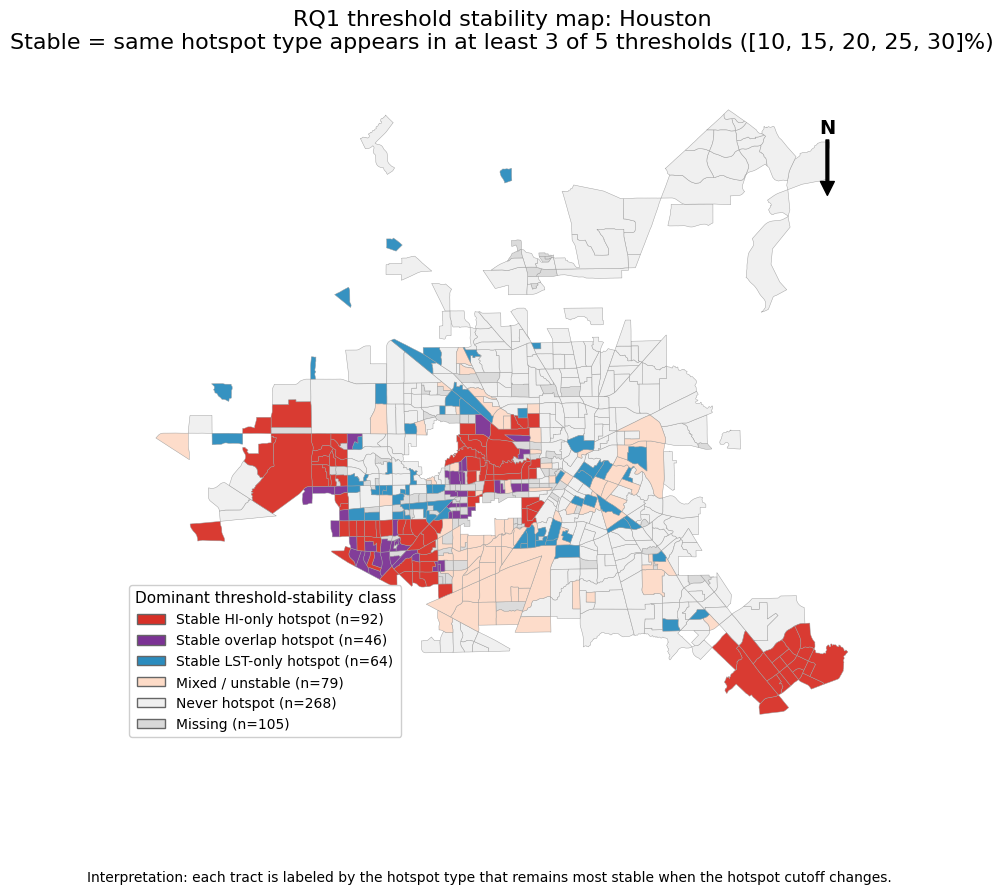

/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_threshold_stability_map_houston.png -> True


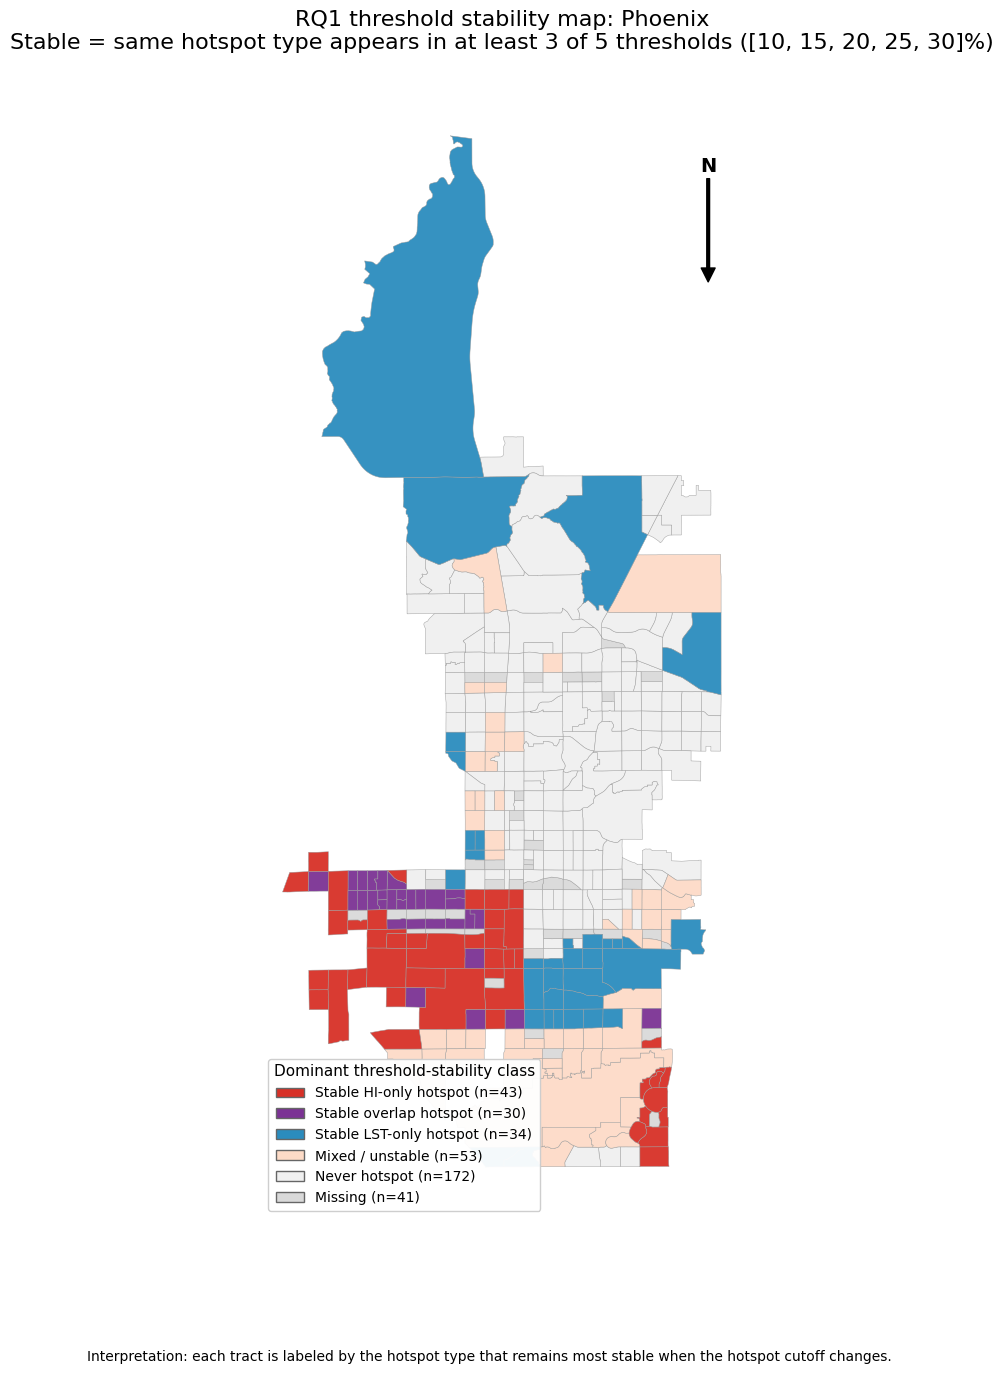

/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_threshold_stability_map_phoenix.png -> True


In [17]:
# ============================================================
# 08 / Cell C
# Plot threshold stability maps
# ============================================================

CATEGORY_ORDER = [
    "Stable HI-only hotspot",
    "Stable overlap hotspot",
    "Stable LST-only hotspot",
    "Mixed / unstable",
    "Never hotspot",
    "Missing",
]

CATEGORY_COLORS = {
    "Stable HI-only hotspot": "#d73027",   # red
    "Stable overlap hotspot": "#7b3294",   # purple
    "Stable LST-only hotspot": "#2b8cbe",  # blue
    "Mixed / unstable": "#fddbc7",         # light peach
    "Never hotspot": "#f0f0f0",            # very light gray
    "Missing": "#d9d9d9",                  # gray
}

def add_north_arrow(ax, x=0.92, y=0.82, length=0.10):
    ax.annotate(
        "N",
        xy=(x, y),
        xytext=(x, y + length),
        xycoords="axes fraction",
        textcoords="axes fraction",
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
        arrowprops=dict(facecolor="black", width=2, headwidth=10, headlength=10)
    )

def plot_threshold_stability_city(gdf, city, slug, use_basemap=False):
    xmin, ymin, xmax, ymax = gdf.total_bounds
    width = xmax - xmin
    height = ymax - ymin
    ratio = height / max(width, 1)

    # Phoenix 会自动更高，不会像以前那样被硬挤扁
    fig_w = 10
    fig_h = float(np.clip(fig_w * ratio + 1.2, 8, 15))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    # 先画背景类别，再画重点类别
    for cat in CATEGORY_ORDER[::-1]:
        sub = gdf[gdf["dominant_stability"] == cat]
        if len(sub) == 0:
            continue
        sub.plot(
            ax=ax,
            color=CATEGORY_COLORS[cat],
            edgecolor="#9e9e9e",
            linewidth=0.35,
            alpha=0.95,
        )

    if use_basemap and HAS_CTX:
        try:
            ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.55)
        except Exception as e:
            print(f"{city}: basemap skipped -> {e}")

    pad_x = width * 0.06
    pad_y = height * 0.06
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)
    ax.set_axis_off()

    add_north_arrow(ax)

    city_counts = gdf["dominant_stability"].value_counts()

    ax.set_title(
        f"RQ1 threshold stability map: {city}\n"
        f"Stable = same hotspot type appears in at least {MIN_STABLE_COUNT} of {len(TOP_PCTS)} thresholds "
        f"({TOP_PCTS}%)",
        fontsize=16,
        pad=18
    )

    handles = [
        Patch(
            facecolor=CATEGORY_COLORS[cat],
            edgecolor="#666666",
            label=f"{cat} (n={int(city_counts.get(cat, 0))})"
        )
        for cat in CATEGORY_ORDER
    ]

    leg = ax.legend(
        handles=handles,
        title="Dominant threshold-stability class",
        loc="lower left",
        bbox_to_anchor=(0.01, 0.01),
        frameon=True,
        fontsize=10,
        title_fontsize=11,
    )
    leg.get_frame().set_alpha(0.95)

    fig.text(
        0.5, 0.02,
        "Interpretation: each tract is labeled by the hotspot type that remains most stable when the hotspot cutoff changes.",
        ha="center",
        va="bottom",
        fontsize=10
    )

    fig_out = FIG_DIR / f"rq1_threshold_stability_map_{slug}.png"
    fig.savefig(fig_out, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print(fig_out, "->", fig_out.exists())


for cfg in CITY_CFG:
    plot_threshold_stability_city(
        all_gdfs[cfg["slug"]],
        city=cfg["city"],
        slug=cfg["slug"],
        use_basemap=USE_BASEMAP,
    )

In [1]:
import ee
ee.Authenticate(auth_mode='notebook')


Successfully saved authorization token.


In [2]:
import ee
ee.Initialize(project='yufei-gee-lab6')
print('EE initialized')

EE initialized


In [3]:
import ee

collection = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")
img_2024 = collection.filterDate("2024-01-01", "2025-01-01").first()

print("Image found:", img_2024 is not None)
print("Band count:", img_2024.bandNames().size().getInfo())
print("First 10 band names:", img_2024.bandNames().slice(0, 10).getInfo())

Image found: True
Band count: 64
First 10 band names: ['A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09']


In [4]:
from pathlib import Path
import geopandas as gpd

PROJECT_ROOT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")
TRACT_FILE = PROJECT_ROOT / "outputs" / "pilot" / "heat_ready" / "houston" / "houston_tracts_heat_ready.geojson"

gdf = gpd.read_file(TRACT_FILE).copy()
gdf = gdf[gdf.geometry.notna()].copy()

# 只保留最关键的列
keep_cols = [c for c in ["GEOID", "geometry"] if c in gdf.columns]
gdf = gdf[keep_cols].copy()

# Earth Engine 要用经纬度
gdf = gdf.to_crs(4326)
gdf["GEOID"] = gdf["GEOID"].astype(str)

print("rows:", len(gdf))
print("columns:", list(gdf.columns))
gdf.head(3)

rows: 654
columns: ['GEOID', 'geometry']


,GEOID,geometry
0,48201421101,"POLYGON ((-95.47652 29.72445, -95.4765 29.7247..."
1,48201423301,"POLYGON ((-95.5282 29.67272, -95.52642 29.6721..."
2,48201453401,"POLYGON ((-95.58373 29.65943, -95.58314 29.659..."


In [5]:
import ee

def gdf_to_ee_fc(gdf_in):
    feats = []
    for _, row in gdf_in.iterrows():
        geom = ee.Geometry(row.geometry.__geo_interface__)
        feat = ee.Feature(geom, {"GEOID": row["GEOID"]})
        feats.append(feat)
    return ee.FeatureCollection(feats)

# 先只取前 5 个 tract 测试，避免一上来跑太大
gdf_test = gdf.head(5).copy()
tracts_fc_test = gdf_to_ee_fc(gdf_test)

img_2024 = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL") \
    .filterDate("2024-01-01", "2025-01-01") \
    .first()

test_result = img_2024.reduceRegions(
    collection=tracts_fc_test,
    reducer=ee.Reducer.mean(),
    scale=10,
    tileScale=4
)

test_info = test_result.getInfo()
print("n features returned:", len(test_info["features"]))
print("first feature property keys (first 15):")
print(list(test_info["features"][0]["properties"].keys())[:15])
print("first GEOID:", test_info["features"][0]["properties"]["GEOID"])

n features returned: 5
first feature property keys (first 15):
['A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14']
first GEOID: 48201421101


In [6]:
# 全部 Houston tracts
tracts_fc_full = gdf_to_ee_fc(gdf)

full_result = img_2024.reduceRegions(
    collection=tracts_fc_full,
    reducer=ee.Reducer.mean(),
    scale=10,
    tileScale=4
)

print("Full Houston reduceRegions object created.")

Full Houston reduceRegions object created.


In [7]:
task = ee.batch.Export.table.toDrive(
    collection=full_result,
    description="houston_alphaearth_2024_tract_mean",
    folder="gee_exports",
    fileNamePrefix="houston_alphaearth_2024_tract_mean",
    fileFormat="CSV"
)

task.start()

print("Export started.")
print("Task status:", task.status())

Export started.
Task status: {'state': 'READY', 'description': 'houston_alphaearth_2024_tract_mean', 'priority': 100, 'creation_timestamp_ms': 1778747068222, 'update_timestamp_ms': 1778747068222, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_FEATURES', 'id': 'Y4CBAURI7I5FFZ2VOPE7G3MH', 'name': 'projects/yufei-gee-lab6/operations/Y4CBAURI7I5FFZ2VOPE7G3MH'}


In [8]:
import time

for i in range(12):   # 最多看 12 次，大概 2 分钟
    status = task.status()
    print(i, status["state"])
    if status["state"] in ["COMPLETED", "FAILED", "CANCELLED"]:
        print(status)
        break
    time.sleep(10)

0 COMPLETED
{'state': 'COMPLETED', 'description': 'houston_alphaearth_2024_tract_mean', 'priority': 100, 'creation_timestamp_ms': 1778747068222, 'update_timestamp_ms': 1778747077804, 'start_timestamp_ms': 1778747071816, 'task_type': 'EXPORT_FEATURES', 'destination_uris': ['https://drive.google.com/#folders/19BLGZ6fgNBNncNYhWWqciU0amY87f1lo'], 'attempt': 1, 'batch_eecu_usage_seconds': 0.5634728670120239, 'id': 'Y4CBAURI7I5FFZ2VOPE7G3MH', 'name': 'projects/yufei-gee-lab6/operations/Y4CBAURI7I5FFZ2VOPE7G3MH'}


In [9]:
from pathlib import Path
import pandas as pd

alphaearth_csv = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_2024_tract_mean.csv")

print("exists:", alphaearth_csv.exists())

df_alpha = pd.read_csv(alphaearth_csv)
print("shape:", df_alpha.shape)
print("first 20 columns:", list(df_alpha.columns[:20]))

band_cols = [c for c in df_alpha.columns if c.startswith("A")]
print("number of embedding columns:", len(band_cols))
print("first 10 embedding columns:", band_cols[:10])

df_alpha.head(3)

exists: True
shape: (654, 67)
first 20 columns: ['system:index', 'A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18']
number of embedding columns: 64
first 10 embedding columns: ['A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09']


,system:index,A00,A01,A02,A03,A04,A05,A06,A07,A08,...,A56,A57,A58,A59,A60,A61,A62,A63,GEOID,.geo
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48201421101,"{""type"":""Polygon"",""coordinates"":[[[-95.4765170..."
1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48201423301,"{""type"":""Polygon"",""coordinates"":[[[-95.528196,..."
2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48201453401,"{""type"":""Polygon"",""coordinates"":[[[-95.583734,..."


In [10]:
from pathlib import Path
import pandas as pd

alphaearth_csv = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_2024_tract_mean.csv")
df_alpha = pd.read_csv(alphaearth_csv)

band_cols = [c for c in df_alpha.columns if c.startswith("A")]

print("all columns:")
print(list(df_alpha.columns))

print("\nshape:", df_alpha.shape)
print("number of embedding columns:", len(band_cols))

# 每行有多少个 embedding 非缺失
df_alpha["n_nonnull_embed"] = df_alpha[band_cols].notna().sum(axis=1)

print("\nrow-level non-null summary:")
print(df_alpha["n_nonnull_embed"].describe())

print("\nrows with all 64 embedding values missing:",
      (df_alpha["n_nonnull_embed"] == 0).sum())

print("\nrows with at least 1 embedding value present:",
      (df_alpha["n_nonnull_embed"] > 0).sum())

print("\nrows with all 64 embedding values present:",
      (df_alpha["n_nonnull_embed"] == 64).sum())

# 每个 band 缺多少
band_missing = df_alpha[band_cols].isna().sum().sort_values(ascending=False)
print("\nTop 10 most-missing bands:")
print(band_missing.head(10))

# 看前 10 行的 GEOID + 非缺失数
preview_cols = []
for c in ["GEOID", "system:index", ".geo"]:
    if c in df_alpha.columns:
        preview_cols.append(c)
preview_cols += ["n_nonnull_embed"]

print("\nPreview of first 10 rows:")
display(df_alpha[preview_cols].head(10))

# 找 5 行 embedding 最完整的看看
show_cols = []
for c in ["GEOID", "system:index", ".geo", "n_nonnull_embed"]:
    if c in df_alpha.columns:
        show_cols.append(c)
show_cols += band_cols[:8]

print("\nTop 5 rows with most non-null embedding values:")
display(df_alpha.sort_values("n_nonnull_embed", ascending=False)[show_cols].head(5))

all columns:
['system:index', 'A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A40', 'A41', 'A42', 'A43', 'A44', 'A45', 'A46', 'A47', 'A48', 'A49', 'A50', 'A51', 'A52', 'A53', 'A54', 'A55', 'A56', 'A57', 'A58', 'A59', 'A60', 'A61', 'A62', 'A63', 'GEOID', '.geo']

shape: (654, 67)
number of embedding columns: 64

row-level non-null summary:
count    654.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: n_nonnull_embed, dtype: float64

rows with all 64 embedding values missing: 654

rows with at least 1 embedding value present: 0

rows with all 64 embedding values present: 0

Top 10 most-missing bands:
A00    654
A01    654
A34    654
A35    654
A36    654
A37    654
A38    654
A39    654
A40    65

,GEOID,system:index,.geo,n_nonnull_embed
0,48201421101,0,"{""type"":""Polygon"",""coordinates"":[[[-95.4765170...",0
1,48201423301,1,"{""type"":""Polygon"",""coordinates"":[[[-95.528196,...",0
2,48201453401,2,"{""type"":""Polygon"",""coordinates"":[[[-95.583734,...",0
3,48201331100,3,"{""type"":""Polygon"",""coordinates"":[[[-95.3832700...",0
4,48201331200,4,"{""type"":""Polygon"",""coordinates"":[[[-95.3874930...",0
5,48201331300,5,"{""type"":""Polygon"",""coordinates"":[[[-95.387669,...",0
6,48201331400,6,"{""type"":""Polygon"",""coordinates"":[[[-95.368611,...",0
7,48201321700,7,"{""type"":""Polygon"",""coordinates"":[[[-95.2464630...",0
8,48201521402,8,"{""type"":""Polygon"",""coordinates"":[[[-95.509637,...",0
9,48201250901,9,"{""type"":""Polygon"",""coordinates"":[[[-95.184212,...",0



Top 5 rows with most non-null embedding values:


,GEOID,system:index,.geo,n_nonnull_embed,A00,A01,A02,A03,A04,A05,A06,A07
0,48201421101,0,"{""type"":""Polygon"",""coordinates"":[[[-95.4765170...",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
449,48201432502,449,"{""type"":""Polygon"",""coordinates"":[[[-95.529151,...",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
431,48201321101,431,"{""type"":""Polygon"",""coordinates"":[[[-95.221047,...",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
432,48201453405,432,"{""type"":""Polygon"",""coordinates"":[[[-95.579405,...",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
433,48201453404,433,"{""type"":""Polygon"",""coordinates"":[[[-95.585374,...",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Diagnose why Houston AlphaEarth export is all-NaN
first_bands = [f"A{str(i).zfill(2)}" for i in range(8)]
all_bands = [f"A{str(i).zfill(2)}" for i in range(64)]

row0 = gdf.iloc[0]
geom0 = ee.Geometry(row0.geometry.__geo_interface__)

# 1) 点采样：看这个 tract 的中心点上有没有 embedding 值
cent0 = row0.geometry.centroid
pt0 = ee.Geometry.Point([float(cent0.x), float(cent0.y)])

pt_fc = img_2024.sample(
    region=pt0,
    scale=10,
    numPixels=1,
    geometries=False
)

pt_info = pt_fc.getInfo()
print("point sample feature count:", len(pt_info["features"]))

if len(pt_info["features"]) > 0:
    pt_props = pt_info["features"][0]["properties"]
    print("point sample first 8 bands:")
    print({b: pt_props.get(b) for b in first_bands})
else:
    print("point sample returned no features")

# 2) 单个 tract polygon 求均值：看 polygon reduceRegion 有没有值
tract_mean0 = img_2024.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=geom0,
    scale=10,
    tileScale=4,
    maxPixels=1e9
).getInfo()

print("\ntract-level mean first 8 bands:")
print({b: tract_mean0.get(b) for b in first_bands})

nonnull_n = sum(tract_mean0.get(b) is not None for b in all_bands)
print("tract-level non-null embedding count:", nonnull_n)

point sample feature count: 0
point sample returned no features

tract-level mean first 8 bands:
{'A00': None, 'A01': None, 'A02': None, 'A03': None, 'A04': None, 'A05': None, 'A06': None, 'A07': None}
tract-level non-null embedding count: 0


In [12]:
# Step 1: inspect 2024 collection size, then mosaic it
collection_2024 = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL") \
    .filterDate("2024-01-01", "2025-01-01")

print("2024 image count:", collection_2024.size().getInfo())

img_2024_mosaic = collection_2024.mosaic()
print("Mosaic band count:", img_2024_mosaic.bandNames().size().getInfo())
print("First 10 band names:", img_2024_mosaic.bandNames().slice(0, 10).getInfo())

2024 image count: 11073
Mosaic band count: 64
First 10 band names: ['A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09']


In [13]:
# Step 2: retry point sample + tract mean using the mosaic image
first_bands = [f"A{str(i).zfill(2)}" for i in range(8)]
all_bands = [f"A{str(i).zfill(2)}" for i in range(64)]

row0 = gdf.iloc[0]
geom0 = ee.Geometry(row0.geometry.__geo_interface__)

cent0 = row0.geometry.centroid
pt0 = ee.Geometry.Point([float(cent0.x), float(cent0.y)])

pt_fc = img_2024_mosaic.sample(
    region=pt0,
    scale=10,
    numPixels=1,
    geometries=False
)

pt_info = pt_fc.getInfo()
print("point sample feature count:", len(pt_info["features"]))

if len(pt_info["features"]) > 0:
    pt_props = pt_info["features"][0]["properties"]
    print("point sample first 8 bands:")
    print({b: pt_props.get(b) for b in first_bands})
else:
    print("point sample returned no features")

tract_mean0 = img_2024_mosaic.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=geom0,
    scale=10,
    tileScale=4,
    maxPixels=1e9
).getInfo()

print("\ntract-level mean first 8 bands:")
print({b: tract_mean0.get(b) for b in first_bands})

nonnull_n = sum(tract_mean0.get(b) is not None for b in all_bands)
print("tract-level non-null embedding count:", nonnull_n)

point sample feature count: 1
point sample first 8 bands:
{'A00': 0.022206843521722412, 'A01': -0.3188927335640138, 'A02': 0.13016532103037293, 'A03': 0.10340638216070744, 'A04': -0.0015378700499807767, 'A05': -0.07111111111111111, 'A06': -0.10340638216070744, 'A07': -0.22145328719723184}

tract-level mean first 8 bands:
{'A00': 0.01873127129375885, 'A01': -0.2564901100224712, 'A02': 0.12350824370867558, 'A03': 0.09620852967678654, 'A04': -0.018582566290663443, 'A05': -0.10021821268230888, 'A06': -0.03291362532303359, 'A07': -0.14429332477335075}
tract-level non-null embedding count: 64


In [14]:
# Re-export Houston AlphaEarth using the mosaic image
tracts_fc_full = gdf_to_ee_fc(gdf)

full_result_mosaic = img_2024_mosaic.reduceRegions(
    collection=tracts_fc_full,
    reducer=ee.Reducer.mean(),
    scale=10,
    tileScale=4
)

task_hou_mosaic = ee.batch.Export.table.toDrive(
    collection=full_result_mosaic,
    description="houston_alphaearth_2024_tract_mean_mosaic",
    folder="gee_exports",
    fileNamePrefix="houston_alphaearth_2024_tract_mean_mosaic",
    fileFormat="CSV"
)

task_hou_mosaic.start()

print("Houston mosaic export started.")
print(task_hou_mosaic.status())

Houston mosaic export started.
{'state': 'READY', 'description': 'houston_alphaearth_2024_tract_mean_mosaic', 'priority': 100, 'creation_timestamp_ms': 1778749011162, 'update_timestamp_ms': 1778749011162, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_FEATURES', 'id': 'K27VZIK3GD4YJPHEBJ66HO35', 'name': 'projects/yufei-gee-lab6/operations/K27VZIK3GD4YJPHEBJ66HO35'}


In [16]:
print(task_hou_mosaic.status())

{'state': 'RUNNING', 'description': 'houston_alphaearth_2024_tract_mean_mosaic', 'priority': 100, 'creation_timestamp_ms': 1778749011162, 'update_timestamp_ms': 1778749056317, 'start_timestamp_ms': 1778749015704, 'task_type': 'EXPORT_FEATURES', 'attempt': 1, 'batch_eecu_usage_seconds': 2202.663085937, 'id': 'K27VZIK3GD4YJPHEBJ66HO35', 'name': 'projects/yufei-gee-lab6/operations/K27VZIK3GD4YJPHEBJ66HO35'}


In [18]:
import time

for i in range(18):   # 最多等 3 分钟
    state = task_hou_mosaic.status()["state"]
    print(i, state)
    if state in ["COMPLETED", "FAILED", "CANCELLED"]:
        print(task_hou_mosaic.status())
        break
    time.sleep(10)

0 COMPLETED
{'state': 'COMPLETED', 'description': 'houston_alphaearth_2024_tract_mean_mosaic', 'priority': 100, 'creation_timestamp_ms': 1778749011162, 'update_timestamp_ms': 1778749329001, 'start_timestamp_ms': 1778749015704, 'task_type': 'EXPORT_FEATURES', 'destination_uris': ['https://drive.google.com/#folders/19BLGZ6fgNBNncNYhWWqciU0amY87f1lo'], 'attempt': 1, 'batch_eecu_usage_seconds': 2214.113037109375, 'id': 'K27VZIK3GD4YJPHEBJ66HO35', 'name': 'projects/yufei-gee-lab6/operations/K27VZIK3GD4YJPHEBJ66HO35'}


In [19]:
status = task_hou_mosaic.status()
print(status)
print("\nDestination URIs:")
print(status.get("destination_uris"))

{'state': 'COMPLETED', 'description': 'houston_alphaearth_2024_tract_mean_mosaic', 'priority': 100, 'creation_timestamp_ms': 1778749011162, 'update_timestamp_ms': 1778749329001, 'start_timestamp_ms': 1778749015704, 'task_type': 'EXPORT_FEATURES', 'destination_uris': ['https://drive.google.com/#folders/19BLGZ6fgNBNncNYhWWqciU0amY87f1lo'], 'attempt': 1, 'batch_eecu_usage_seconds': 2214.113037109375, 'id': 'K27VZIK3GD4YJPHEBJ66HO35', 'name': 'projects/yufei-gee-lab6/operations/K27VZIK3GD4YJPHEBJ66HO35'}

Destination URIs:
['https://drive.google.com/#folders/19BLGZ6fgNBNncNYhWWqciU0amY87f1lo']


In [20]:
from pathlib import Path
import pandas as pd

alphaearth_mosaic_csv = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_2024_tract_mean_mosaic.csv")

print("exists:", alphaearth_mosaic_csv.exists())

df_alpha_mosaic = pd.read_csv(alphaearth_mosaic_csv)
band_cols = [c for c in df_alpha_mosaic.columns if c.startswith("A")]

print("shape:", df_alpha_mosaic.shape)
print("number of embedding columns:", len(band_cols))

df_alpha_mosaic["n_nonnull_embed"] = df_alpha_mosaic[band_cols].notna().sum(axis=1)

print("rows with all 64 embedding values missing:", (df_alpha_mosaic["n_nonnull_embed"] == 0).sum())
print("rows with at least 1 embedding value present:", (df_alpha_mosaic["n_nonnull_embed"] > 0).sum())
print("rows with all 64 embedding values present:", (df_alpha_mosaic["n_nonnull_embed"] == 64).sum())

display(df_alpha_mosaic[["GEOID", "n_nonnull_embed"] + band_cols[:6]].head(5))

exists: True
shape: (654, 67)
number of embedding columns: 64
rows with all 64 embedding values missing: 0
rows with at least 1 embedding value present: 654
rows with all 64 embedding values present: 654


,GEOID,n_nonnull_embed,A00,A01,A02,A03,A04,A05
0,48201421101,64,0.018731,-0.256490,0.123508,0.096209,-0.018583,-0.100218
1,48201423301,64,0.034697,-0.279059,0.116154,0.161576,0.004948,-0.057462
2,48201453401,64,0.051650,-0.288384,0.113208,0.155385,0.000846,-0.082265
3,48201331100,64,0.021726,-0.240182,0.127334,0.166392,0.030012,-0.031022
4,48201331200,64,-0.013400,-0.204226,0.103653,0.171746,0.009359,-0.004845


In [21]:
from pathlib import Path
import pandas as pd

# input
alphaearth_mosaic_csv = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_2024_tract_mean_mosaic.csv")

# output
clean_out = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_2024_tract_mean_mosaic_clean.csv")

# read
df_alpha_mosaic = pd.read_csv(alphaearth_mosaic_csv)

# keep only GEOID + embedding bands
band_cols = [c for c in df_alpha_mosaic.columns if c.startswith("A")]
keep_cols = ["GEOID"] + band_cols

df_alpha_clean = df_alpha_mosaic[keep_cols].copy()
df_alpha_clean["GEOID"] = df_alpha_clean["GEOID"].astype(str)

# safety checks
print("clean shape:", df_alpha_clean.shape)
print("unique GEOID rows:", df_alpha_clean["GEOID"].nunique())
print("duplicate GEOID rows:", df_alpha_clean["GEOID"].duplicated().sum())
print("number of embedding columns:", len(band_cols))

# save
df_alpha_clean.to_csv(clean_out, index=False)

print("saved:", clean_out)
print("exists:", clean_out.exists())

df_alpha_clean.head(5)

clean shape: (654, 65)
unique GEOID rows: 654
duplicate GEOID rows: 0
number of embedding columns: 64
saved: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_2024_tract_mean_mosaic_clean.csv
exists: True


,GEOID,A00,A01,A02,A03,A04,A05,A06,A07,A08,...,A54,A55,A56,A57,A58,A59,A60,A61,A62,A63
0,48201421101,0.018731,-0.256490,0.123508,0.096209,-0.018583,-0.100218,-0.032914,-0.144293,-0.168535,...,0.160482,-0.215607,0.023021,0.069764,0.155156,-0.033835,0.011638,-0.098970,-0.166730,0.047529
1,48201423301,0.034697,-0.279059,0.116154,0.161576,0.004948,-0.057462,-0.063224,-0.113428,-0.068318,...,0.138134,-0.253013,0.037695,0.072024,0.115097,-0.089942,0.067055,-0.004621,-0.119371,0.031185
2,48201453401,0.051650,-0.288384,0.113208,0.155385,0.000846,-0.082265,-0.061769,-0.113993,-0.107388,...,0.138695,-0.267256,0.058073,0.048051,0.094822,-0.079987,0.096272,0.018347,-0.126833,0.032904
3,48201331100,0.021726,-0.240182,0.127334,0.166392,0.030012,-0.031022,-0.009188,-0.121193,-0.090306,...,0.123549,-0.219474,0.002425,0.072847,0.131400,-0.029747,0.020170,-0.050683,-0.143954,0.044789
4,48201331200,-0.013400,-0.204226,0.103653,0.171746,0.009359,-0.004845,0.000466,-0.035628,-0.055109,...,0.065495,-0.184344,-0.076380,0.057216,0.144169,-0.018962,-0.024645,-0.128560,-0.081781,0.021658


In [22]:
from pathlib import Path
import geopandas as gpd
import pandas as pd

# files
tract_file = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/heat_ready/houston/houston_tracts_heat_ready.geojson")
embed_file = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_2024_tract_mean_mosaic_clean.csv")

out_geojson = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_tracts_heat_ready_with_alphaearth.geojson")
out_csv = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_tracts_heat_ready_with_alphaearth.csv")

# read
gdf_hou = gpd.read_file(tract_file).copy()
df_embed = pd.read_csv(embed_file).copy()

gdf_hou["GEOID"] = gdf_hou["GEOID"].astype(str)
df_embed["GEOID"] = df_embed["GEOID"].astype(str)

band_cols = [c for c in df_embed.columns if c.startswith("A")]

# merge
gdf_join = gdf_hou.merge(df_embed, on="GEOID", how="left")

# QC
gdf_join["n_nonnull_embed"] = gdf_join[band_cols].notna().sum(axis=1)

print("tract rows:", len(gdf_hou))
print("embed rows:", len(df_embed))
print("joined rows:", len(gdf_join))
print("joined unique GEOID:", gdf_join["GEOID"].nunique())
print("rows with all 64 embedding values present:", (gdf_join["n_nonnull_embed"] == 64).sum())
print("rows with any embedding missing:", (gdf_join["n_nonnull_embed"] < 64).sum())

# save
gdf_join.to_file(out_geojson, driver="GeoJSON")
gdf_join.drop(columns="geometry").to_csv(out_csv, index=False)

print("saved geojson:", out_geojson)
print("saved csv:", out_csv)
print("geojson exists:", out_geojson.exists())
print("csv exists:", out_csv.exists())

display(gdf_join[["GEOID", "n_nonnull_embed"] + band_cols[:6]].head(5))

tract rows: 654
embed rows: 654
joined rows: 654
joined unique GEOID: 654
rows with all 64 embedding values present: 654
rows with any embedding missing: 0
saved geojson: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_tracts_heat_ready_with_alphaearth.geojson
saved csv: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_tracts_heat_ready_with_alphaearth.csv
geojson exists: True
csv exists: True


,GEOID,n_nonnull_embed,A00,A01,A02,A03,A04,A05
0,48201421101,64,0.018731,-0.256490,0.123508,0.096209,-0.018583,-0.100218
1,48201423301,64,0.034697,-0.279059,0.116154,0.161576,0.004948,-0.057462
2,48201453401,64,0.051650,-0.288384,0.113208,0.155385,0.000846,-0.082265
3,48201331100,64,0.021726,-0.240182,0.127334,0.166392,0.030012,-0.031022
4,48201331200,64,-0.013400,-0.204226,0.103653,0.171746,0.009359,-0.004845


n rows: 654
n embedding dims: 66
rows with any missing embedding: 0

Cumulative explained variance:
PC2: 0.5029
PC3: 0.5927
PC5: 0.7201
PC8: 0.8428
PC10: 0.8821
PC15: 0.9408
PC20: 0.9646
First PC count reaching 70% variance: 5
First PC count reaching 80% variance: 7
First PC count reaching 90% variance: 12


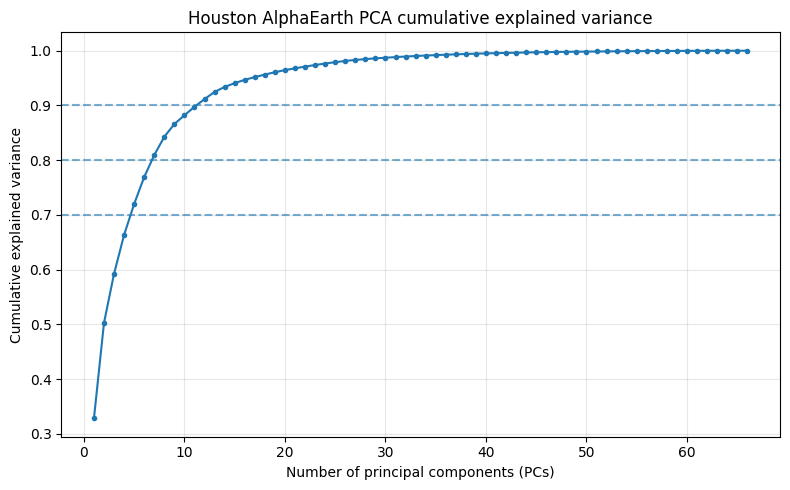


saved summary: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_pca_explained_variance.csv
saved plot: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_pca_cumulative_variance.png


,pc,explained_variance_ratio,cumulative_explained_variance
0,1,0.328529,0.328529
1,2,0.174334,0.502863
2,3,0.089856,0.592719
3,4,0.070887,0.663605
4,5,0.056462,0.720067
5,6,0.049195,0.769263
6,7,0.040141,0.809403
7,8,0.033437,0.842841
8,9,0.023204,0.866044
9,10,0.016066,0.882111


In [23]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =========================================
# Houston AlphaEarth merged table
# =========================================
infile = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_tracts_heat_ready_with_alphaearth.csv")
out_dir = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth")
out_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(infile).copy()

band_cols = [c for c in df.columns if c.startswith("A")]
print("n rows:", len(df))
print("n embedding dims:", len(band_cols))

# =========================================
# PCA input matrix
# =========================================
X = df[band_cols].copy()

# safety check
print("rows with any missing embedding:", X.isna().any(axis=1).sum())

# standardize before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# full PCA
pca = PCA(n_components=len(band_cols), random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cum_explained = explained.cumsum()

pca_summary = pd.DataFrame({
    "pc": np.arange(1, len(explained) + 1),
    "explained_variance_ratio": explained,
    "cumulative_explained_variance": cum_explained
})

# save table
summary_csv = out_dir / "houston_alphaearth_pca_explained_variance.csv"
pca_summary.to_csv(summary_csv, index=False)

# quick checkpoints
targets = [2, 3, 5, 8, 10, 15, 20]
print("\nCumulative explained variance:")
for k in targets:
    if k <= len(cum_explained):
        print(f"PC{k}: {cum_explained[k-1]:.4f}")

# suggest first k reaching thresholds
for thresh in [0.70, 0.80, 0.90]:
    k_hit = int(np.argmax(cum_explained >= thresh) + 1)
    print(f"First PC count reaching {int(thresh*100)}% variance: {k_hit}")

# =========================================
# plot
# =========================================
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pca_summary["pc"], pca_summary["cumulative_explained_variance"], marker="o", markersize=3)
ax.set_xlabel("Number of principal components (PCs)")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("Houston AlphaEarth PCA cumulative explained variance")
ax.grid(True, alpha=0.3)

for y in [0.70, 0.80, 0.90]:
    ax.axhline(y, linestyle="--", alpha=0.6)

plot_png = out_dir / "houston_alphaearth_pca_cumulative_variance.png"
fig.tight_layout()
fig.savefig(plot_png, dpi=300, bbox_inches="tight")
plt.show()

print("\nsaved summary:", summary_csv)
print("saved plot:", plot_png)

display(pca_summary.head(15))

In [24]:
from pathlib import Path
import pandas as pd
import numpy as np
import geopandas as gpd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =========================================
# files
# =========================================
in_csv = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_tracts_heat_ready_with_alphaearth.csv")
in_geojson = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_tracts_heat_ready_with_alphaearth.geojson")
out_dir = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth")
out_dir.mkdir(parents=True, exist_ok=True)

# =========================================
# read
# =========================================
df = pd.read_csv(in_csv).copy()
gdf = gpd.read_file(in_geojson).copy()

df["GEOID"] = df["GEOID"].astype(str)
gdf["GEOID"] = gdf["GEOID"].astype(str)

band_cols = [c for c in df.columns if c.startswith("A")]
X = df[band_cols].copy()

print("n rows:", len(df))
print("n embedding dims:", len(band_cols))
print("rows with any missing embedding:", X.isna().any(axis=1).sum())

# =========================================
# standardize
# =========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================================
# PCA-5
# =========================================
pca5 = PCA(n_components=5, random_state=42)
scores5 = pca5.fit_transform(X_scaled)

pc5_cols = [f"PC{i}" for i in range(1, 6)]
df_pc5 = pd.DataFrame(scores5, columns=pc5_cols)
df_pc5.insert(0, "GEOID", df["GEOID"].values)

loadings5 = pd.DataFrame(
    pca5.components_.T,
    index=band_cols,
    columns=pc5_cols
).reset_index().rename(columns={"index": "band"})

# =========================================
# PCA-7
# =========================================
pca7 = PCA(n_components=7, random_state=42)
scores7 = pca7.fit_transform(X_scaled)

pc7_cols = [f"PC{i}" for i in range(1, 8)]
df_pc7 = pd.DataFrame(scores7, columns=pc7_cols)
df_pc7.insert(0, "GEOID", df["GEOID"].values)

loadings7 = pd.DataFrame(
    pca7.components_.T,
    index=band_cols,
    columns=pc7_cols
).reset_index().rename(columns={"index": "band"})

# =========================================
# explained variance tables
# =========================================
ev5 = pd.DataFrame({
    "pc": pc5_cols,
    "explained_variance_ratio": pca5.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca5.explained_variance_ratio_)
})

ev7 = pd.DataFrame({
    "pc": pc7_cols,
    "explained_variance_ratio": pca7.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca7.explained_variance_ratio_)
})

# =========================================
# save csv
# =========================================
pc5_csv = out_dir / "houston_alphaearth_pc5_scores.csv"
pc7_csv = out_dir / "houston_alphaearth_pc7_scores.csv"
load5_csv = out_dir / "houston_alphaearth_pc5_loadings.csv"
load7_csv = out_dir / "houston_alphaearth_pc7_loadings.csv"
ev5_csv = out_dir / "houston_alphaearth_pc5_explained_variance.csv"
ev7_csv = out_dir / "houston_alphaearth_pc7_explained_variance.csv"

df_pc5.to_csv(pc5_csv, index=False)
df_pc7.to_csv(pc7_csv, index=False)
loadings5.to_csv(load5_csv, index=False)
loadings7.to_csv(load7_csv, index=False)
ev5.to_csv(ev5_csv, index=False)
ev7.to_csv(ev7_csv, index=False)

# =========================================
# merge PC scores back to geo table
# =========================================
gdf_pc5 = gdf.merge(df_pc5, on="GEOID", how="left")
gdf_pc7 = gdf.merge(df_pc7, on="GEOID", how="left")

pc5_geojson = out_dir / "houston_tracts_with_alphaearth_pc5.geojson"
pc7_geojson = out_dir / "houston_tracts_with_alphaearth_pc7.geojson"

gdf_pc5.to_file(pc5_geojson, driver="GeoJSON")
gdf_pc7.to_file(pc7_geojson, driver="GeoJSON")

# =========================================
# quick output
# =========================================
print("\nPCA-5 cumulative explained variance:")
print(ev5)

print("\nPCA-7 cumulative explained variance:")
print(ev7)

print("\nSaved files:")
for p in [pc5_csv, pc7_csv, load5_csv, load7_csv, ev5_csv, ev7_csv, pc5_geojson, pc7_geojson]:
    print(p.name, "->", p.exists())

print("\nPC5 score preview:")
display(df_pc5.head())

print("\nPC7 score preview:")
display(df_pc7.head())

print("\nTop absolute loadings for PC1 (PCA-5):")
display(
    loadings5.assign(abs_PC1=loadings5["PC1"].abs())
             .sort_values("abs_PC1", ascending=False)
             .head(10)[["band", "PC1", "abs_PC1"]]
)

n rows: 654
n embedding dims: 66
rows with any missing embedding: 0

PCA-5 cumulative explained variance:
    pc  explained_variance_ratio  cumulative_explained_variance
0  PC1                  0.328529                       0.328529
1  PC2                  0.174334                       0.502863
2  PC3                  0.089856                       0.592719
3  PC4                  0.070887                       0.663605
4  PC5                  0.056462                       0.720067

PCA-7 cumulative explained variance:
    pc  explained_variance_ratio  cumulative_explained_variance
0  PC1                  0.328529                       0.328529
1  PC2                  0.174334                       0.502863
2  PC3                  0.089856                       0.592719
3  PC4                  0.070887                       0.663605
4  PC5                  0.056462                       0.720067
5  PC6                  0.049195                       0.769263
6  PC7                  

,GEOID,PC1,PC2,PC3,PC4,PC5
0,48201421101,2.888938,6.110649,0.268108,1.173500,0.527565
1,48201423301,1.040221,-4.144633,2.376575,-1.796287,1.773058
2,48201453401,3.147301,-3.869096,1.283583,-0.948201,2.113246
3,48201331100,-1.841620,-0.422717,0.906346,2.639865,0.522544
4,48201331200,-8.005587,0.416056,0.097948,0.585240,-1.818116



PC7 score preview:


,GEOID,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,48201421101,2.888938,6.110649,0.268110,1.173522,0.527562,1.751270,0.599002
1,48201423301,1.040221,-4.144633,2.376575,-1.796294,1.773060,0.074788,-0.094695
2,48201453401,3.147301,-3.869096,1.283583,-0.948206,2.113227,-1.136573,-1.421418
3,48201331100,-1.841620,-0.422717,0.906344,2.639854,0.522579,-1.447561,0.816785
4,48201331200,-8.005587,0.416056,0.097946,0.585227,-1.818125,-2.936381,0.910718



Top absolute loadings for PC1 (PCA-5):


,band,PC1,abs_PC1
58,A56,0.195841,0.195841
9,A07,-0.193861,0.193861
18,A16,0.191829,0.191829
36,A34,0.190707,0.190707
15,A13,-0.182741,0.182741
64,A62,-0.178465,0.178465
52,A50,0.177472,0.177472
3,A01,-0.176695,0.176695
2,A00,0.173287,0.173287
22,A20,0.172914,0.172914


In [25]:
from pathlib import Path
import pandas as pd
import numpy as np
import geopandas as gpd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =========================================
# files
# =========================================
in_csv = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_tracts_heat_ready_with_alphaearth.csv")
in_geojson = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_tracts_heat_ready_with_alphaearth.geojson")
out_dir = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth")
out_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(in_csv).copy()
gdf = gpd.read_file(in_geojson).copy()

df["GEOID"] = df["GEOID"].astype(str)
gdf["GEOID"] = gdf["GEOID"].astype(str)

# =========================================
# STRICT AlphaEarth band list: A00-A63 only
# =========================================
band_cols = [f"A{str(i).zfill(2)}" for i in range(64)]

missing_bands = [c for c in band_cols if c not in df.columns]
extra_A_cols = [c for c in df.columns if c.startswith("A") and c not in band_cols]

print("Expected embedding dims:", len(band_cols))
print("Missing expected bands:", missing_bands)
print("Extra A-starting cols not used:", extra_A_cols)

X = df[band_cols].copy()

print("n rows:", len(df))
print("n embedding dims actually used:", X.shape[1])
print("rows with any missing embedding:", X.isna().any(axis=1).sum())

# =========================================
# standardize
# =========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================================
# PCA-5
# =========================================
pca5 = PCA(n_components=5, random_state=42)
scores5 = pca5.fit_transform(X_scaled)

pc5_cols = [f"PC{i}" for i in range(1, 6)]
df_pc5 = pd.DataFrame(scores5, columns=pc5_cols)
df_pc5.insert(0, "GEOID", df["GEOID"].values)

loadings5 = pd.DataFrame(
    pca5.components_.T,
    index=band_cols,
    columns=pc5_cols
).reset_index().rename(columns={"index": "band"})

ev5 = pd.DataFrame({
    "pc": pc5_cols,
    "explained_variance_ratio": pca5.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca5.explained_variance_ratio_)
})

# =========================================
# PCA-7
# =========================================
pca7 = PCA(n_components=7, random_state=42)
scores7 = pca7.fit_transform(X_scaled)

pc7_cols = [f"PC{i}" for i in range(1, 8)]
df_pc7 = pd.DataFrame(scores7, columns=pc7_cols)
df_pc7.insert(0, "GEOID", df["GEOID"].values)

loadings7 = pd.DataFrame(
    pca7.components_.T,
    index=band_cols,
    columns=pc7_cols
).reset_index().rename(columns={"index": "band"})

ev7 = pd.DataFrame({
    "pc": pc7_cols,
    "explained_variance_ratio": pca7.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca7.explained_variance_ratio_)
})

# =========================================
# save corrected outputs
# =========================================
pc5_csv = out_dir / "houston_alphaearth_pc5_scores_corrected.csv"
pc7_csv = out_dir / "houston_alphaearth_pc7_scores_corrected.csv"
load5_csv = out_dir / "houston_alphaearth_pc5_loadings_corrected.csv"
load7_csv = out_dir / "houston_alphaearth_pc7_loadings_corrected.csv"
ev5_csv = out_dir / "houston_alphaearth_pc5_explained_variance_corrected.csv"
ev7_csv = out_dir / "houston_alphaearth_pc7_explained_variance_corrected.csv"

df_pc5.to_csv(pc5_csv, index=False)
df_pc7.to_csv(pc7_csv, index=False)
loadings5.to_csv(load5_csv, index=False)
loadings7.to_csv(load7_csv, index=False)
ev5.to_csv(ev5_csv, index=False)
ev7.to_csv(ev7_csv, index=False)

# merge back to geojson
gdf_pc5 = gdf.merge(df_pc5, on="GEOID", how="left")
gdf_pc7 = gdf.merge(df_pc7, on="GEOID", how="left")

pc5_geojson = out_dir / "houston_tracts_with_alphaearth_pc5_corrected.geojson"
pc7_geojson = out_dir / "houston_tracts_with_alphaearth_pc7_corrected.geojson"

gdf_pc5.to_file(pc5_geojson, driver="GeoJSON")
gdf_pc7.to_file(pc7_geojson, driver="GeoJSON")

print("\nCorrected PCA-5 cumulative explained variance:")
print(ev5)

print("\nCorrected PCA-7 cumulative explained variance:")
print(ev7)

print("\nSaved corrected files:")
for p in [pc5_csv, pc7_csv, load5_csv, load7_csv, ev5_csv, ev7_csv, pc5_geojson, pc7_geojson]:
    print(p.name, "->", p.exists())

print("\nTop absolute loadings for PC1 (corrected PCA-5):")
display(
    loadings5.assign(abs_PC1=loadings5["PC1"].abs())
             .sort_values("abs_PC1", ascending=False)
             .head(10)[["band", "PC1", "abs_PC1"]]
)

Expected embedding dims: 64
Missing expected bands: []
Extra A-starting cols not used: ['ALAND', 'AWATER']
n rows: 654
n embedding dims actually used: 64
rows with any missing embedding: 0

Corrected PCA-5 cumulative explained variance:
    pc  explained_variance_ratio  cumulative_explained_variance
0  PC1                  0.331658                       0.331658
1  PC2                  0.179263                       0.510921
2  PC3                  0.090775                       0.601696
3  PC4                  0.071793                       0.673489
4  PC5                  0.057991                       0.731480

Corrected PCA-7 cumulative explained variance:
    pc  explained_variance_ratio  cumulative_explained_variance
0  PC1                  0.331658                       0.331658
1  PC2                  0.179263                       0.510921
2  PC3                  0.090775                       0.601696
3  PC4                  0.071793                       0.673489
4  PC5     

,band,PC1,abs_PC1
56,A56,0.197495,0.197495
7,A07,-0.195572,0.195572
16,A16,0.194309,0.194309
34,A34,0.192248,0.192248
13,A13,-0.184154,0.184154
62,A62,-0.179683,0.179683
50,A50,0.179460,0.179460
1,A01,-0.177022,0.177022
20,A20,0.176014,0.176014
0,A00,0.175329,0.175329


Saved summary: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_pc123_spatial_summary.csv


,pc,mean,std,min,p5,median,p95,max,explained_variance_ratio,cumulative_explained_variance
0,PC1,8.691654e-17,4.610708,-15.162447,-9.384593,0.666140,6.363353,9.064294,0.331658,0.331658
1,PC2,-2.172914e-17,3.389752,-8.766347,-5.430424,-0.006225,5.510019,8.318484,0.179263,0.510921
2,PC3,7.605197e-17,2.412155,-10.990259,-4.405312,0.320865,3.320572,6.143014,0.090775,0.601696


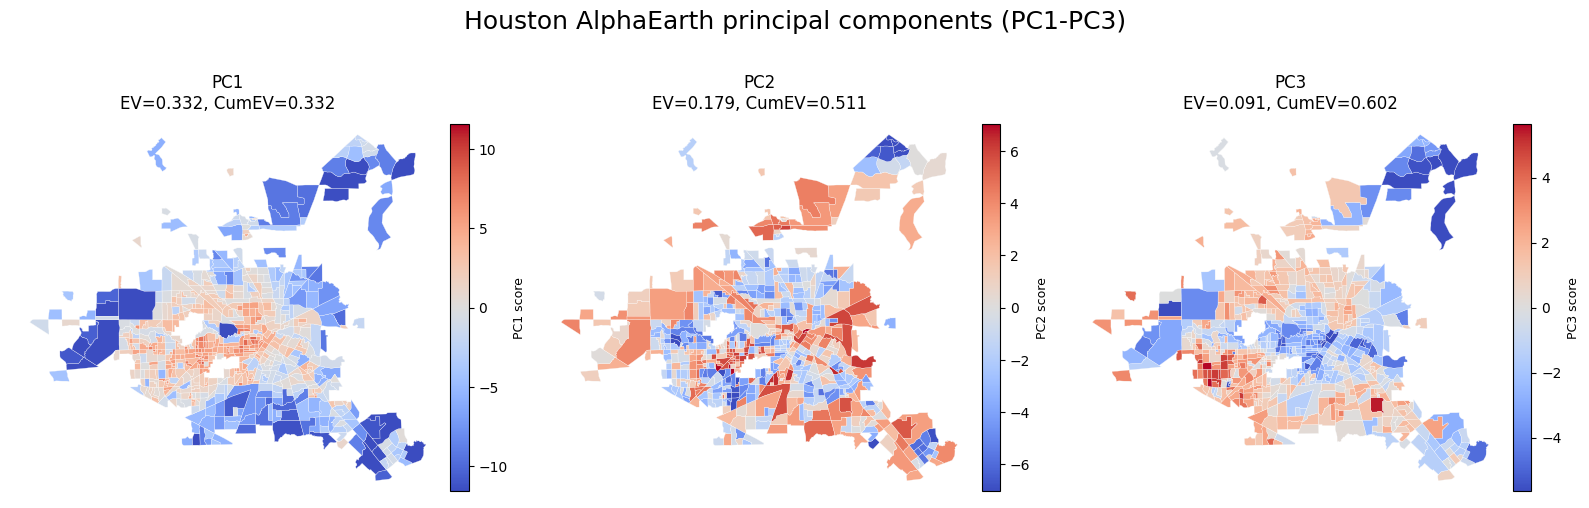

Saved map: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_pc123_spatial_maps.png


In [26]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# files
pc_geojson = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_tracts_with_alphaearth_pc5_corrected.geojson")
ev_csv = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_pc5_explained_variance_corrected.csv")
out_dir = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth")
out_dir.mkdir(parents=True, exist_ok=True)

out_png = out_dir / "houston_alphaearth_pc123_spatial_maps.png"
out_summary_csv = out_dir / "houston_alphaearth_pc123_spatial_summary.csv"

# read
gdf = gpd.read_file(pc_geojson).copy()
ev = pd.read_csv(ev_csv).copy()

pc_cols = ["PC1", "PC2", "PC3"]

# summary table
summary_rows = []
for pc in pc_cols:
    vals = gdf[pc].dropna()
    summary_rows.append({
        "pc": pc,
        "mean": vals.mean(),
        "std": vals.std(),
        "min": vals.min(),
        "p5": vals.quantile(0.05),
        "median": vals.median(),
        "p95": vals.quantile(0.95),
        "max": vals.max()
    })

summary_df = pd.DataFrame(summary_rows).merge(
    ev.rename(columns={"pc": "pc"}),
    on="pc",
    how="left"
)
summary_df.to_csv(out_summary_csv, index=False)

print("Saved summary:", out_summary_csv)
display(summary_df)

# plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5.8))
fig.suptitle("Houston AlphaEarth principal components (PC1-PC3)", fontsize=18, y=0.98)

for ax, pc in zip(axes, pc_cols):
    vals = gdf[pc].dropna()
    vmax = np.nanpercentile(np.abs(vals), 98)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    # base layer
    gdf.plot(ax=ax, color="#efefef", edgecolor="white", linewidth=0.2)

    # PC layer
    gdf.plot(
        ax=ax,
        column=pc,
        cmap="coolwarm",
        norm=norm,
        edgecolor="white",
        linewidth=0.2
    )

    ev_row = ev.loc[ev["pc"] == pc].iloc[0]
    ax.set_title(
        f"{pc}\nEV={ev_row['explained_variance_ratio']:.3f}, CumEV={ev_row['cumulative_explained_variance']:.3f}",
        fontsize=12
    )
    ax.axis("off")

    sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.01)
    cbar.set_label(f"{pc} score", fontsize=9)

fig.tight_layout()
fig.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved map:", out_png)

Available factor columns: ['total_population', 'total_population_clean', 'poverty_rate', 'below_poverty_count', 'below_poverty_count_clean', 'median_household_income', 'median_household_income_clean', 'ALAND', 'AWATER']
Final factor columns used: ['total_population', 'total_population_clean', 'poverty_rate', 'below_poverty_count', 'below_poverty_count_clean', 'median_household_income', 'median_household_income_clean', 'ALAND', 'AWATER']

Saved correlation table: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_pc123_factor_spearman_correlations.csv


,pc,variable,spearman_r,n,abs_spearman_r
7,PC1,ALAND,-0.725639,654,0.725639
8,PC1,AWATER,-0.539279,654,0.539279
0,PC1,total_population,-0.225261,654,0.225261
1,PC1,total_population_clean,-0.225261,654,0.225261
3,PC1,below_poverty_count,-0.151736,654,0.151736
4,PC1,below_poverty_count_clean,-0.151736,654,0.151736
5,PC1,median_household_income,0.116051,654,0.116051
6,PC1,median_household_income_clean,0.106100,645,0.106100
2,PC1,poverty_rate,-0.051720,651,0.051720
14,PC2,median_household_income,-0.273868,654,0.273868


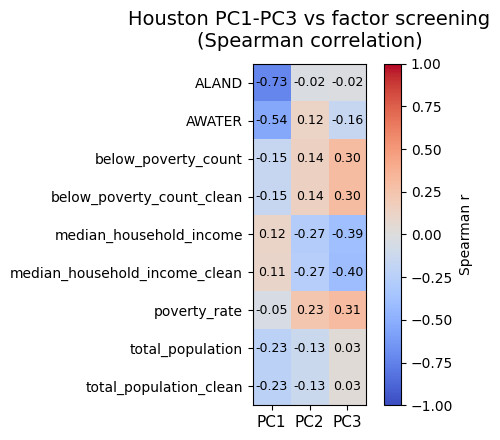

Saved heatmap: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_pc123_factor_spearman_heatmap.png

Saved top3 summary: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_pc123_top3_factor_links.csv


,pc,variable,spearman_r,n,abs_spearman_r
0,PC1,ALAND,-0.725639,654,0.725639
1,PC1,AWATER,-0.539279,654,0.539279
2,PC1,total_population,-0.225261,654,0.225261
3,PC2,median_household_income,-0.273868,654,0.273868
4,PC2,median_household_income_clean,-0.265224,645,0.265224
5,PC2,poverty_rate,0.229502,651,0.229502
6,PC3,median_household_income_clean,-0.402840,645,0.402840
7,PC3,median_household_income,-0.387691,654,0.387691
8,PC3,poverty_rate,0.311559,651,0.311559


In [27]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ================================
# read Houston PC geojson
# ================================
pc_geojson = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_tracts_with_alphaearth_pc5_corrected.geojson")
out_dir = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth")
out_dir.mkdir(parents=True, exist_ok=True)

gdf = gpd.read_file(pc_geojson).copy()

# ================================
# build candidate factor columns
# ================================
# 先列一些常见候选变量名；存在才会用
candidate_cols = [
    "lst_c",
    "hi_c",
    "total_population",
    "total_population_clean",
    "poverty_rate",
    "below_poverty_count",
    "below_poverty_count_clean",
    "median_household_income",
    "median_household_income_clean",
    "ALAND",
    "AWATER"
]

available_cols = [c for c in candidate_cols if c in gdf.columns]
print("Available factor columns:", available_cols)

# 如果没有现成 gap，就现场造一个 standardized gap
if ("lst_c" in gdf.columns) and ("hi_c" in gdf.columns):
    gdf["gap_raw_hi_minus_lst"] = gdf["hi_c"] - gdf["lst_c"]
    gdf["gap_z_hi_minus_lst"] = (
        (gdf["hi_c"] - gdf["hi_c"].mean()) / gdf["hi_c"].std()
        - (gdf["lst_c"] - gdf["lst_c"].mean()) / gdf["lst_c"].std()
    )
    available_cols += ["gap_raw_hi_minus_lst", "gap_z_hi_minus_lst"]

# 去重
available_cols = list(dict.fromkeys(available_cols))
print("Final factor columns used:", available_cols)

# ================================
# correlation screen
# ================================
pc_cols = ["PC1", "PC2", "PC3"]

corr_rows = []
for pc in pc_cols:
    for var in available_cols:
        sub = gdf[[pc, var]].replace([np.inf, -np.inf], np.nan).dropna()
        if len(sub) < 10:
            corr = np.nan
            n = len(sub)
        else:
            corr = sub[pc].corr(sub[var], method="spearman")
            n = len(sub)

        corr_rows.append({
            "pc": pc,
            "variable": var,
            "spearman_r": corr,
            "n": n,
            "abs_spearman_r": abs(corr) if pd.notna(corr) else np.nan
        })

corr_df = pd.DataFrame(corr_rows).sort_values(
    ["pc", "abs_spearman_r"], ascending=[True, False]
)

corr_csv = out_dir / "houston_pc123_factor_spearman_correlations.csv"
corr_df.to_csv(corr_csv, index=False)

print("\nSaved correlation table:", corr_csv)
display(corr_df)

# ================================
# heatmap-style figure
# ================================
mat = corr_df.pivot(index="variable", columns="pc", values="spearman_r")

fig, ax = plt.subplots(figsize=(6.8, max(4.5, 0.45 * len(mat))))
im = ax.imshow(mat.values, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(mat.columns)))
ax.set_xticklabels(mat.columns, fontsize=11)
ax.set_yticks(range(len(mat.index)))
ax.set_yticklabels(mat.index, fontsize=10)

# 在格子里写数字
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        val = mat.iloc[i, j]
        txt = "" if pd.isna(val) else f"{val:.2f}"
        ax.text(j, i, txt, ha="center", va="center", fontsize=9)

ax.set_title("Houston PC1-PC3 vs factor screening\n(Spearman correlation)", fontsize=14, pad=12)
cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03)
cbar.set_label("Spearman r", fontsize=10)

fig.tight_layout()

heatmap_png = out_dir / "houston_pc123_factor_spearman_heatmap.png"
fig.savefig(heatmap_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved heatmap:", heatmap_png)

# ================================
# top 3 strongest relationships per PC
# ================================
top3 = (
    corr_df.sort_values(["pc", "abs_spearman_r"], ascending=[True, False])
           .groupby("pc")
           .head(3)
           .reset_index(drop=True)
)

top3_csv = out_dir / "houston_pc123_top3_factor_links.csv"
top3.to_csv(top3_csv, index=False)

print("\nSaved top3 summary:", top3_csv)
display(top3)

In [29]:
from pathlib import Path
import geopandas as gpd

pc_geojson = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_tracts_with_alphaearth_pc5_corrected.geojson")
gdf = gpd.read_file(pc_geojson).copy()

print("n columns:", len(gdf.columns))
print("\nAll columns:")
print(list(gdf.columns))

print("\nColumns containing 'lst':")
print([c for c in gdf.columns if "lst" in c.lower()])

print("\nColumns containing 'hi':")
print([c for c in gdf.columns if "hi" in c.lower()])

print("\nColumns containing 'income':")
print([c for c in gdf.columns if "income" in c.lower()])

print("\nColumns containing 'poverty':")
print([c for c in gdf.columns if "poverty" in c.lower()])

print("\nColumns containing 'population' or 'pop':")
print([c for c in gdf.columns if ("population" in c.lower()) or ("pop" in c.lower())])

n columns: 93

All columns:
['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'NAME', 'NAMELSAD', 'ALAND', 'AWATER', 'area_km2', 'city', 'total_population', 'median_household_income', 'total_population_clean', 'median_household_income_clean', 'poverty_universe', 'below_poverty_count', 'poverty_universe_clean', 'below_poverty_count_clean', 'poverty_rate', 'low_income_flag', 'high_poverty_flag', 'inequity_group', 'A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A40', 'A41', 'A42', 'A43', 'A44', 'A45', 'A46', 'A47', 'A48', 'A49', 'A50', 'A51', 'A52', 'A53', 'A54', 'A55', 'A56', 'A57', 'A58', 'A59', 'A60', 'A61', 'A62', 'A63', 'n_nonnull_embed', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'geometry']

Columns containing 'lst':
[]

Columns containing 'hi':
['high_poverty_flag']

In [30]:
from pathlib import Path
import pandas as pd
import geopandas as gpd

project_root = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")

candidates = []
for p in project_root.rglob("*houston*"):
    if p.suffix.lower() in [".geojson", ".gpkg", ".csv"]:
        candidates.append(p)

print("n candidate files:", len(candidates))

rows = []

for p in sorted(candidates):
    try:
        if p.suffix.lower() in [".geojson", ".gpkg"]:
            df = gpd.read_file(p)
        else:
            df = pd.read_csv(p, nrows=5)

        cols = list(df.columns)
        lst_cols = [c for c in cols if "lst" in c.lower()]
        hi_cols = [c for c in cols if "hi" in c.lower()]
        heat_cols = [c for c in cols if "heat" in c.lower()]
        pop_cols = [c for c in cols if "population" in c.lower() or "pop" in c.lower()]

        if lst_cols or hi_cols or heat_cols:
            rows.append({
                "file": str(p),
                "n_cols": len(cols),
                "lst_cols": lst_cols,
                "hi_cols": hi_cols,
                "heat_cols": heat_cols,
                "pop_cols": pop_cols[:5]
            })
    except Exception as e:
        rows.append({
            "file": str(p),
            "n_cols": "READ_FAIL",
            "lst_cols": [],
            "hi_cols": [],
            "heat_cols": [f"ERROR: {type(e).__name__}"],
            "pop_cols": []
        })

result = pd.DataFrame(rows)
display(result)

print("\nLikely best candidates:")
if len(result) > 0:
    display(result.sort_values(by="file").head(20))
else:
    print("No files with heat-related column names found.")

n candidate files: 49


,file,n_cols,lst_cols,hi_cols,heat_cols,pop_cols
0,/Users/yufeizhou/Desktop/heat-exposure-compare...,23,[],[high_poverty_flag],[],"[total_population, total_population_clean]"
1,/Users/yufeizhou/Desktop/heat-exposure-compare...,33,"[lst_summer_mean_c, lst_summer_median_c, lst_h...",[high_poverty_flag],[],"[total_population, total_population_clean]"
2,/Users/yufeizhou/Desktop/heat-exposure-compare...,38,"[lst_summer_mean_c, lst_summer_median_c, lst_h...","[high_poverty_flag, hi_summer_mean_c, hi_summe...",[],"[total_population, total_population_clean]"
3,/Users/yufeizhou/Desktop/heat-exposure-compare...,25,"[lst_summer_mean_c, lst_summer_median_c]",[high_poverty_flag],[],"[total_population, total_population_clean]"
4,/Users/yufeizhou/Desktop/heat-exposure-compare...,35,"[lst_summer_mean_c, lst_summer_median_c, lst_h...","[high_poverty_flag, hi_summer_mean_c, hi_summe...",[],"[total_population, total_population_clean]"
5,/Users/yufeizhou/Desktop/heat-exposure-compare...,25,[lst_c],"[high_poverty_flag, hi_c]",[],"[total_population, total_population_clean]"
6,/Users/yufeizhou/Desktop/heat-exposure-compare...,29,"[lst_summer_mean_c, lst_summer_median_c, lst_h...",[high_poverty_flag],[],"[total_population, total_population_clean]"
7,/Users/yufeizhou/Desktop/heat-exposure-compare...,30,"[lst_c, lst_hotspot]","[high_poverty_flag, hi_c, hi_hotspot]",[],"[total_population, total_population_clean, pop..."
8,/Users/yufeizhou/Desktop/heat-exposure-compare...,87,[],[high_poverty_flag],[],"[total_population, total_population_clean]"
9,/Users/yufeizhou/Desktop/heat-exposure-compare...,88,[],[high_poverty_flag],[],"[total_population, total_population_clean]"



Likely best candidates:


,file,n_cols,lst_cols,hi_cols,heat_cols,pop_cols
0,/Users/yufeizhou/Desktop/heat-exposure-compare...,23,[],[high_poverty_flag],[],"[total_population, total_population_clean]"
1,/Users/yufeizhou/Desktop/heat-exposure-compare...,33,"[lst_summer_mean_c, lst_summer_median_c, lst_h...",[high_poverty_flag],[],"[total_population, total_population_clean]"
2,/Users/yufeizhou/Desktop/heat-exposure-compare...,38,"[lst_summer_mean_c, lst_summer_median_c, lst_h...","[high_poverty_flag, hi_summer_mean_c, hi_summe...",[],"[total_population, total_population_clean]"
3,/Users/yufeizhou/Desktop/heat-exposure-compare...,25,"[lst_summer_mean_c, lst_summer_median_c]",[high_poverty_flag],[],"[total_population, total_population_clean]"
4,/Users/yufeizhou/Desktop/heat-exposure-compare...,35,"[lst_summer_mean_c, lst_summer_median_c, lst_h...","[high_poverty_flag, hi_summer_mean_c, hi_summe...",[],"[total_population, total_population_clean]"
5,/Users/yufeizhou/Desktop/heat-exposure-compare...,25,[lst_c],"[high_poverty_flag, hi_c]",[],"[total_population, total_population_clean]"
6,/Users/yufeizhou/Desktop/heat-exposure-compare...,29,"[lst_summer_mean_c, lst_summer_median_c, lst_h...",[high_poverty_flag],[],"[total_population, total_population_clean]"
7,/Users/yufeizhou/Desktop/heat-exposure-compare...,30,"[lst_c, lst_hotspot]","[high_poverty_flag, hi_c, hi_hotspot]",[],"[total_population, total_population_clean, pop..."
8,/Users/yufeizhou/Desktop/heat-exposure-compare...,87,[],[high_poverty_flag],[],"[total_population, total_population_clean]"
9,/Users/yufeizhou/Desktop/heat-exposure-compare...,88,[],[high_poverty_flag],[],"[total_population, total_population_clean]"


In [31]:
from pathlib import Path
import pandas as pd
import geopandas as gpd

project_root = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")

rows = []
for p in project_root.rglob("*houston*"):
    if p.suffix.lower() not in [".geojson", ".gpkg", ".csv"]:
        continue
    try:
        if p.suffix.lower() in [".geojson", ".gpkg"]:
            df = gpd.read_file(p)
        else:
            df = pd.read_csv(p, nrows=5)

        cols = list(df.columns)
        rows.append({
            "file": str(p),
            "n_cols": len(cols),
            "has_GEOID": "GEOID" in cols,
            "has_lst_c": "lst_c" in cols,
            "has_hi_c": "hi_c" in cols,
            "has_lst_hotspot": "lst_hotspot" in cols,
            "has_hi_hotspot": "hi_hotspot" in cols,
            "has_income": "median_household_income_clean" in cols or "median_household_income" in cols,
            "has_poverty": "poverty_rate" in cols,
            "has_population": "total_population_clean" in cols or "total_population" in cols,
        })
    except Exception:
        pass

cand = pd.DataFrame(rows)

best = cand[
    (cand["has_GEOID"]) &
    (cand["has_lst_c"]) &
    (cand["has_hi_c"])
].copy()

best = best.sort_values(
    by=["has_lst_hotspot", "has_hi_hotspot", "has_income", "has_poverty", "has_population", "n_cols"],
    ascending=[False, False, False, False, False, True]
)

pd.set_option("display.max_colwidth", None)
display(best)

,file,n_cols,has_GEOID,has_lst_c,has_hi_c,has_lst_hotspot,has_hi_hotspot,has_income,has_poverty,has_population
8,/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_rq1_compare.gpkg,30,True,True,True,True,True,True,True,True
12,/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_with_lst_hi_fixed.gpkg,25,True,True,True,False,False,True,True,True
16,/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_threshold_stability_houston.gpkg,40,True,True,True,False,False,False,False,True


In [33]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd

from sklearn.model_selection import KFold, cross_validate
from sklearn.ensemble import RandomForestRegressor

# =========================================
# files
# =========================================
heat_file = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_rq1_compare.gpkg")
pc5_file = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_pc5_scores_corrected.csv")
out_dir = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth")
out_dir.mkdir(parents=True, exist_ok=True)

# =========================================
# read
# =========================================
gdf_heat = gpd.read_file(heat_file).copy()
df_pc5 = pd.read_csv(pc5_file).copy()

gdf_heat["GEOID"] = gdf_heat["GEOID"].astype(str)
df_pc5["GEOID"] = df_pc5["GEOID"].astype(str)

# merge
gdf_model = gdf_heat.merge(df_pc5, on="GEOID", how="left")

print("heat rows:", len(gdf_heat))
print("pc rows:", len(df_pc5))
print("merged rows:", len(gdf_model))
print("rows missing any PC:", gdf_model[["PC1","PC2","PC3","PC4","PC5"]].isna().any(axis=1).sum())

# =========================================
# target: HI-LST gap
# =========================================
gdf_model["gap_raw_hi_minus_lst"] = gdf_model["hi_c"] - gdf_model["lst_c"]
gdf_model["gap_z_hi_minus_lst"] = (
    (gdf_model["hi_c"] - gdf_model["hi_c"].mean()) / gdf_model["hi_c"].std()
    - (gdf_model["lst_c"] - gdf_model["lst_c"].mean()) / gdf_model["lst_c"].std()
)

# =========================================
# choose factor columns robustly
# =========================================
def pick_first_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

income_col = pick_first_existing(gdf_model, ["median_household_income_clean", "median_household_income"])
pop_col = pick_first_existing(gdf_model, ["total_population_clean", "total_population"])

base_cols = [income_col, "poverty_rate", pop_col, "ALAND", "AWATER"]
pc_cols = ["PC1", "PC2", "PC3", "PC4", "PC5"]
target_col = "gap_z_hi_minus_lst"

print("\nUsing columns:")
print("income_col:", income_col)
print("pop_col:", pop_col)
print("base_cols:", base_cols)
print("pc_cols:", pc_cols)

# keep usable rows
use_cols = base_cols + pc_cols + [target_col]
df_model = gdf_model[use_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()

print("\nmodel rows after dropna:", len(df_model))
print("target mean:", df_model[target_col].mean())
print("target std:", df_model[target_col].std())

X_base = df_model[base_cols]
X_ext = df_model[base_cols + pc_cols]
y = df_model[target_col]

# =========================================
# model
# =========================================
cv = KFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

cv_base = cross_validate(
    rf, X_base, y,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

cv_ext = cross_validate(
    rf, X_ext, y,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

summary = pd.DataFrame([
    {
        "model": "baseline_factors_only",
        "n_features": X_base.shape[1],
        "cv_r2_mean": np.mean(cv_base["test_r2"]),
        "cv_r2_std": np.std(cv_base["test_r2"]),
        "cv_rmse_mean": -np.mean(cv_base["test_rmse"]),
        "cv_rmse_std": np.std(-cv_base["test_rmse"]),
        "cv_mae_mean": -np.mean(cv_base["test_mae"]),
        "cv_mae_std": np.std(-cv_base["test_mae"])
    },
    {
        "model": "extended_factors_plus_PC1_to_PC5",
        "n_features": X_ext.shape[1],
        "cv_r2_mean": np.mean(cv_ext["test_r2"]),
        "cv_r2_std": np.std(cv_ext["test_r2"]),
        "cv_rmse_mean": -np.mean(cv_ext["test_rmse"]),
        "cv_rmse_std": np.std(-cv_ext["test_rmse"]),
        "cv_mae_mean": -np.mean(cv_ext["test_mae"]),
        "cv_mae_std": np.std(-cv_ext["test_mae"])
    }
])

summary["delta_vs_baseline_r2"] = summary["cv_r2_mean"] - summary.loc[0, "cv_r2_mean"]
summary["delta_vs_baseline_rmse"] = summary["cv_rmse_mean"] - summary.loc[0, "cv_rmse_mean"]
summary["delta_vs_baseline_mae"] = summary["cv_mae_mean"] - summary.loc[0, "cv_mae_mean"]

fold_df = pd.DataFrame({
    "fold": np.arange(1, 6),
    "baseline_r2": cv_base["test_r2"],
    "baseline_rmse": -cv_base["test_rmse"],
    "baseline_mae": -cv_base["test_mae"],
    "extended_r2": cv_ext["test_r2"],
    "extended_rmse": -cv_ext["test_rmse"],
    "extended_mae": -cv_ext["test_mae"],
})

summary_csv = out_dir / "houston_gap_model_baseline_vs_pc5_rf_cv_corrected.csv"
fold_csv = out_dir / "houston_gap_model_baseline_vs_pc5_rf_cv_folds_corrected.csv"

summary.to_csv(summary_csv, index=False)
fold_df.to_csv(fold_csv, index=False)

print("\nSaved summary:", summary_csv)
print("Saved folds:", fold_csv)

display(summary)
display(fold_df)

heat rows: 654
pc rows: 654
merged rows: 654
rows missing any PC: 0

Using columns:
income_col: median_household_income_clean
pop_col: total_population_clean
base_cols: ['median_household_income_clean', 'poverty_rate', 'total_population_clean', 'ALAND', 'AWATER']
pc_cols: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']

model rows after dropna: 541
target mean: 0.10936249685523614
target std: 1.1701697273135883

Saved summary: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_gap_model_baseline_vs_pc5_rf_cv_corrected.csv
Saved folds: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_gap_model_baseline_vs_pc5_rf_cv_folds_corrected.csv


,model,n_features,cv_r2_mean,cv_r2_std,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,delta_vs_baseline_r2,delta_vs_baseline_rmse,delta_vs_baseline_mae
0,baseline_factors_only,5,0.111643,0.130269,1.100080,0.133796,0.788299,0.059004,0.000000,0.000000,0.00000
1,extended_factors_plus_PC1_to_PC5,10,0.427186,0.084289,0.884146,0.113569,0.634479,0.037440,0.315543,-0.215934,-0.15382


,fold,baseline_r2,baseline_rmse,baseline_mae,extended_r2,extended_rmse,extended_mae
0,1,0.141908,1.035219,0.781828,0.477900,0.807499,0.606018
1,2,-0.017430,1.166731,0.841084,0.378920,0.911574,0.663015
2,3,0.312866,0.930536,0.698417,0.526343,0.772581,0.594260
3,4,0.164213,1.046042,0.757400,0.464779,0.837081,0.616072
4,5,-0.043342,1.321872,0.862766,0.287986,1.091994,0.693029


In [35]:
%pip install shap

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.3/562.3 kB 135.6 kB/s  0:00:04eta 0:00:01
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 61.7 kB/s  0:13:31m0:00:0500:17
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 40.1 kB/s  0:01:09m0:00:0200:08
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [shap]4/6 [numba]te]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


model rows: 541
features: ['median_household_income_clean', 'poverty_rate', 'total_population_clean', 'ALAND', 'AWATER', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5']

Saved SHAP importance: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_gap_extended_rf_shap_importance.csv


,feature,mean_abs_shap
5,PC1,0.377642
6,PC2,0.219022
1,poverty_rate,0.116107
7,PC3,0.095535
8,PC4,0.076537
4,AWATER,0.072816
0,median_household_income_clean,0.061001
2,total_population_clean,0.042595
3,ALAND,0.032513
9,PC5,0.027327


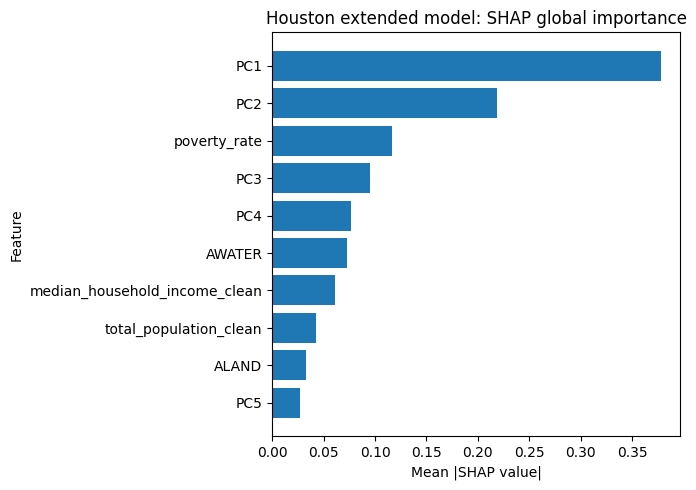

Saved SHAP bar plot: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_gap_extended_rf_shap_bar.png


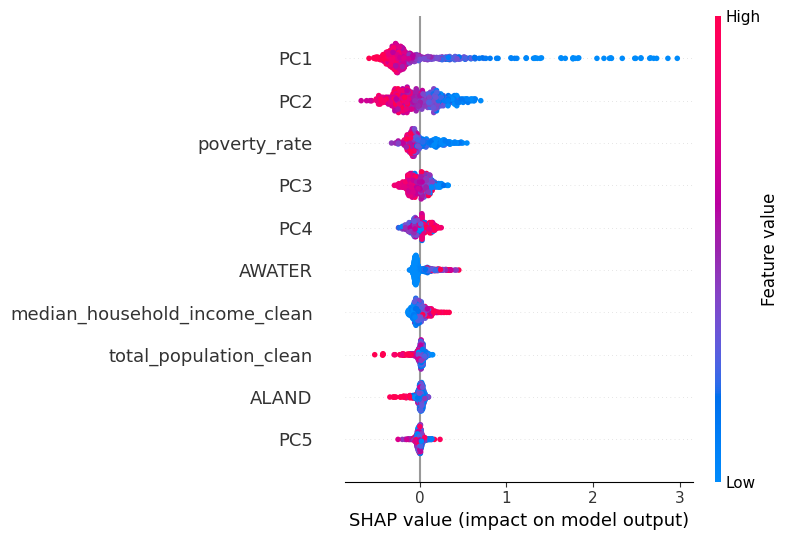

Saved SHAP summary plot: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_gap_extended_rf_shap_summary.png


In [36]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

# try import shap
try:
    import shap
except ImportError:
    raise ImportError("shap not installed. Run: %pip install shap")

# =========================================
# files
# =========================================
heat_file = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_rq1_compare.gpkg")
pc5_file = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_pc5_scores_corrected.csv")
out_dir = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth")
out_dir.mkdir(parents=True, exist_ok=True)

# =========================================
# read and merge
# =========================================
gdf_heat = gpd.read_file(heat_file).copy()
df_pc5 = pd.read_csv(pc5_file).copy()

gdf_heat["GEOID"] = gdf_heat["GEOID"].astype(str)
df_pc5["GEOID"] = df_pc5["GEOID"].astype(str)

gdf_model = gdf_heat.merge(df_pc5, on="GEOID", how="left")

# target
gdf_model["gap_z_hi_minus_lst"] = (
    (gdf_model["hi_c"] - gdf_model["hi_c"].mean()) / gdf_model["hi_c"].std()
    - (gdf_model["lst_c"] - gdf_model["lst_c"].mean()) / gdf_model["lst_c"].std()
)

# choose columns
income_col = "median_household_income_clean" if "median_household_income_clean" in gdf_model.columns else "median_household_income"
pop_col = "total_population_clean" if "total_population_clean" in gdf_model.columns else "total_population"

feature_cols = [income_col, "poverty_rate", pop_col, "ALAND", "AWATER", "PC1", "PC2", "PC3", "PC4", "PC5"]
target_col = "gap_z_hi_minus_lst"

df_use = gdf_model[feature_cols + [target_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()

X = df_use[feature_cols]
y = df_use[target_col]

print("model rows:", len(df_use))
print("features:", feature_cols)

# =========================================
# fit full extended RF model
# =========================================
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
rf.fit(X, y)

# =========================================
# SHAP values
# =========================================
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

# global importance
mean_abs_shap = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

importance_csv = out_dir / "houston_gap_extended_rf_shap_importance.csv"
mean_abs_shap.to_csv(importance_csv, index=False)

print("\nSaved SHAP importance:", importance_csv)
display(mean_abs_shap)

# =========================================
# bar plot
# =========================================
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(mean_abs_shap["feature"][::-1], mean_abs_shap["mean_abs_shap"][::-1])
ax.set_xlabel("Mean |SHAP value|")
ax.set_ylabel("Feature")
ax.set_title("Houston extended model: SHAP global importance")
fig.tight_layout()

bar_png = out_dir / "houston_gap_extended_rf_shap_bar.png"
fig.savefig(bar_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved SHAP bar plot:", bar_png)

# =========================================
# optional beeswarm-style summary
# =========================================
summary_png = out_dir / "houston_gap_extended_rf_shap_summary.png"
plt.figure()
shap.summary_plot(shap_values, X, show=False)
plt.tight_layout()
plt.savefig(summary_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved SHAP summary plot:", summary_png)

In [37]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd

from sklearn.model_selection import KFold, cross_validate
from sklearn.ensemble import RandomForestRegressor

# =========================================
# files
# =========================================
heat_file = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_rq1_compare.gpkg")
pc7_file = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_pc7_scores_corrected.csv")
out_dir = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth")
out_dir.mkdir(parents=True, exist_ok=True)

# =========================================
# read
# =========================================
gdf_heat = gpd.read_file(heat_file).copy()
df_pc7 = pd.read_csv(pc7_file).copy()

gdf_heat["GEOID"] = gdf_heat["GEOID"].astype(str)
df_pc7["GEOID"] = df_pc7["GEOID"].astype(str)

gdf_model = gdf_heat.merge(df_pc7, on="GEOID", how="left")

print("heat rows:", len(gdf_heat))
print("pc7 rows:", len(df_pc7))
print("merged rows:", len(gdf_model))
print("rows missing any PC7:", gdf_model[[f"PC{i}" for i in range(1, 8)]].isna().any(axis=1).sum())

# =========================================
# target
# =========================================
gdf_model["gap_raw_hi_minus_lst"] = gdf_model["hi_c"] - gdf_model["lst_c"]
gdf_model["gap_z_hi_minus_lst"] = (
    (gdf_model["hi_c"] - gdf_model["hi_c"].mean()) / gdf_model["hi_c"].std()
    - (gdf_model["lst_c"] - gdf_model["lst_c"].mean()) / gdf_model["lst_c"].std()
)

# =========================================
# columns
# =========================================
income_col = "median_household_income_clean" if "median_household_income_clean" in gdf_model.columns else "median_household_income"
pop_col = "total_population_clean" if "total_population_clean" in gdf_model.columns else "total_population"

base_cols = [income_col, "poverty_rate", pop_col, "ALAND", "AWATER"]
pc7_cols = [f"PC{i}" for i in range(1, 8)]
target_col = "gap_z_hi_minus_lst"

print("\nUsing columns:")
print("base_cols:", base_cols)
print("pc7_cols:", pc7_cols)

df_model = gdf_model[base_cols + pc7_cols + [target_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()

print("\nmodel rows after dropna:", len(df_model))
print("target mean:", df_model[target_col].mean())
print("target std:", df_model[target_col].std())

X_base = df_model[base_cols]
X_ext7 = df_model[base_cols + pc7_cols]
y = df_model[target_col]

# =========================================
# model
# =========================================
cv = KFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

cv_base = cross_validate(
    rf, X_base, y,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

cv_ext7 = cross_validate(
    rf, X_ext7, y,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

summary7 = pd.DataFrame([
    {
        "model": "baseline_factors_only",
        "n_features": X_base.shape[1],
        "cv_r2_mean": np.mean(cv_base["test_r2"]),
        "cv_r2_std": np.std(cv_base["test_r2"]),
        "cv_rmse_mean": -np.mean(cv_base["test_rmse"]),
        "cv_rmse_std": np.std(-cv_base["test_rmse"]),
        "cv_mae_mean": -np.mean(cv_base["test_mae"]),
        "cv_mae_std": np.std(-cv_base["test_mae"])
    },
    {
        "model": "extended_factors_plus_PC1_to_PC7",
        "n_features": X_ext7.shape[1],
        "cv_r2_mean": np.mean(cv_ext7["test_r2"]),
        "cv_r2_std": np.std(cv_ext7["test_r2"]),
        "cv_rmse_mean": -np.mean(cv_ext7["test_rmse"]),
        "cv_rmse_std": np.std(-cv_ext7["test_rmse"]),
        "cv_mae_mean": -np.mean(cv_ext7["test_mae"]),
        "cv_mae_std": np.std(-cv_ext7["test_mae"])
    }
])

summary7["delta_vs_baseline_r2"] = summary7["cv_r2_mean"] - summary7.loc[0, "cv_r2_mean"]
summary7["delta_vs_baseline_rmse"] = summary7["cv_rmse_mean"] - summary7.loc[0, "cv_rmse_mean"]
summary7["delta_vs_baseline_mae"] = summary7["cv_mae_mean"] - summary7.loc[0, "cv_mae_mean"]

fold_df7 = pd.DataFrame({
    "fold": np.arange(1, 6),
    "baseline_r2": cv_base["test_r2"],
    "baseline_rmse": -cv_base["test_rmse"],
    "baseline_mae": -cv_base["test_mae"],
    "extended7_r2": cv_ext7["test_r2"],
    "extended7_rmse": -cv_ext7["test_rmse"],
    "extended7_mae": -cv_ext7["test_mae"],
})

summary7_csv = out_dir / "houston_gap_model_baseline_vs_pc7_rf_cv_corrected.csv"
fold7_csv = out_dir / "houston_gap_model_baseline_vs_pc7_rf_cv_folds_corrected.csv"

summary7.to_csv(summary7_csv, index=False)
fold_df7.to_csv(fold7_csv, index=False)

print("\nSaved summary7:", summary7_csv)
print("Saved fold7:", fold7_csv)

display(summary7)
display(fold_df7)

heat rows: 654
pc7 rows: 654
merged rows: 654
rows missing any PC7: 0

Using columns:
base_cols: ['median_household_income_clean', 'poverty_rate', 'total_population_clean', 'ALAND', 'AWATER']
pc7_cols: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7']

model rows after dropna: 541
target mean: 0.10936249685523614
target std: 1.1701697273135883

Saved summary7: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_gap_model_baseline_vs_pc7_rf_cv_corrected.csv
Saved fold7: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_gap_model_baseline_vs_pc7_rf_cv_folds_corrected.csv


,model,n_features,cv_r2_mean,cv_r2_std,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,delta_vs_baseline_r2,delta_vs_baseline_rmse,delta_vs_baseline_mae
0,baseline_factors_only,5,0.111643,0.130269,1.100080,0.133796,0.788299,0.059004,0.000000,0.000000,0.000000
1,extended_factors_plus_PC1_to_PC7,12,0.445235,0.064077,0.870358,0.098599,0.618177,0.023288,0.333592,-0.229722,-0.170123


,fold,baseline_r2,baseline_rmse,baseline_mae,extended7_r2,extended7_rmse,extended7_mae
0,1,0.141908,1.035219,0.781828,0.481786,0.804488,0.605624
1,2,-0.017430,1.166731,0.841084,0.415955,0.883978,0.633555
2,3,0.312866,0.930536,0.698417,0.493456,0.798953,0.603692
3,4,0.164213,1.046042,0.757400,0.502552,0.807003,0.592070
4,5,-0.043342,1.321872,0.862766,0.332427,1.057366,0.655942


In [38]:
from pathlib import Path
import geopandas as gpd
import ee

# -----------------------------
# initialize EE
# -----------------------------
ee.Initialize(project="yufei-gee-lab6")

# -----------------------------
# read Phoenix tract file
# -----------------------------
PHX_TRACT_FILE = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/heat_ready/phoenix/phoenix_tracts_heat_ready.geojson")

gdf_phx = gpd.read_file(PHX_TRACT_FILE).copy()
gdf_phx = gdf_phx[gdf_phx.geometry.notna()].copy()
gdf_phx = gdf_phx[["GEOID", "geometry"]].copy()
gdf_phx = gdf_phx.to_crs(4326)
gdf_phx["GEOID"] = gdf_phx["GEOID"].astype(str)

print("phoenix rows:", len(gdf_phx))
display(gdf_phx.head(3))

# -----------------------------
# helper: GeoDataFrame -> EE FeatureCollection
# -----------------------------
def gdf_to_ee_fc(gdf_in):
    feats = []
    for _, row in gdf_in.iterrows():
        geom = ee.Geometry(row.geometry.__geo_interface__)
        feats.append(ee.Feature(geom, {"GEOID": row["GEOID"]}))
    return ee.FeatureCollection(feats)

phx_fc = gdf_to_ee_fc(gdf_phx)

# -----------------------------
# 2024 AlphaEarth mosaic
# -----------------------------
collection_2024 = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL") \
    .filterDate("2024-01-01", "2025-01-01")

img_2024_mosaic = collection_2024.mosaic()

print("2024 image count:", collection_2024.size().getInfo())
print("mosaic band count:", img_2024_mosaic.bandNames().size().getInfo())
print("first 10 bands:", img_2024_mosaic.bandNames().slice(0, 10).getInfo())

# -----------------------------
# export Phoenix tract means
# -----------------------------
phx_result_mosaic = img_2024_mosaic.reduceRegions(
    collection=phx_fc,
    reducer=ee.Reducer.mean(),
    scale=10,
    tileScale=4
)

task_phx_mosaic = ee.batch.Export.table.toDrive(
    collection=phx_result_mosaic,
    description="phoenix_alphaearth_2024_tract_mean_mosaic",
    folder="gee_exports",
    fileNamePrefix="phoenix_alphaearth_2024_tract_mean_mosaic",
    fileFormat="CSV"
)

task_phx_mosaic.start()

print("Phoenix mosaic export started.")
print(task_phx_mosaic.status())

phoenix rows: 373


GEOID  \
0  04013117200   
1  04013082016   
2  04013104402   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

2024 image count: 11073
mosaic band count: 64
first 10 bands: ['A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09']
Phoenix mosaic export started.
{'state': 'READY', 'description': 'phoenix_alphaearth_2024_tract_mean_mosaic', 'priority': 100, 'creation_timestamp_ms': 1778754914236, 'update_timestamp_ms': 1778754914236, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_FEATURES', 'id': 'UEPFLVZ4UX2HE4VACUBQZJLF', 'name': 'projects/yufei-gee-lab6/operations/UEPFLVZ4UX2HE4VACUBQZJLF'}


In [39]:
status = task_phx_mosaic.status()
print(status["state"])
print(status)

COMPLETED
{'state': 'COMPLETED', 'description': 'phoenix_alphaearth_2024_tract_mean_mosaic', 'priority': 100, 'creation_timestamp_ms': 1778754914236, 'update_timestamp_ms': 1778754929966, 'start_timestamp_ms': 1778754916697, 'task_type': 'EXPORT_FEATURES', 'destination_uris': ['https://drive.google.com/#folders/19BLGZ6fgNBNncNYhWWqciU0amY87f1lo'], 'attempt': 1, 'batch_eecu_usage_seconds': 1911.5362548828125, 'id': 'UEPFLVZ4UX2HE4VACUBQZJLF', 'name': 'projects/yufei-gee-lab6/operations/UEPFLVZ4UX2HE4VACUBQZJLF'}


In [40]:
status = task_phx_mosaic.status()
print(status)
print(status.get("destination_uris"))

{'state': 'COMPLETED', 'description': 'phoenix_alphaearth_2024_tract_mean_mosaic', 'priority': 100, 'creation_timestamp_ms': 1778754914236, 'update_timestamp_ms': 1778754929966, 'start_timestamp_ms': 1778754916697, 'task_type': 'EXPORT_FEATURES', 'destination_uris': ['https://drive.google.com/#folders/19BLGZ6fgNBNncNYhWWqciU0amY87f1lo'], 'attempt': 1, 'batch_eecu_usage_seconds': 1911.5362548828125, 'id': 'UEPFLVZ4UX2HE4VACUBQZJLF', 'name': 'projects/yufei-gee-lab6/operations/UEPFLVZ4UX2HE4VACUBQZJLF'}
['https://drive.google.com/#folders/19BLGZ6fgNBNncNYhWWqciU0amY87f1lo']


In [41]:
from pathlib import Path
import pandas as pd

phoenix_csv = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_alphaearth_2024_tract_mean_mosaic.csv")

print("exists:", phoenix_csv.exists())

df_phx = pd.read_csv(phoenix_csv)
band_cols = [c for c in df_phx.columns if c.startswith("A")]

print("shape:", df_phx.shape)
print("number of embedding columns:", len(band_cols))

df_phx["n_nonnull_embed"] = df_phx[band_cols].notna().sum(axis=1)

print("rows with all 64 embedding values missing:", (df_phx["n_nonnull_embed"] == 0).sum())
print("rows with at least 1 embedding value present:", (df_phx["n_nonnull_embed"] > 0).sum())
print("rows with all 64 embedding values present:", (df_phx["n_nonnull_embed"] == 64).sum())

display(df_phx[["GEOID", "n_nonnull_embed"] + band_cols[:6]].head(5))

exists: True
shape: (373, 67)
number of embedding columns: 64
rows with all 64 embedding values missing: 0
rows with at least 1 embedding value present: 373
rows with all 64 embedding values present: 373


,GEOID,n_nonnull_embed,A00,A01,A02,A03,A04,A05
0,4013117200,64,0.141401,-0.111252,0.115777,0.062390,-0.008142,-0.133117
1,4013082016,64,0.146472,-0.030013,0.156616,0.050347,-0.038322,-0.062147
2,4013104402,64,0.151778,-0.196405,0.143293,0.067271,-0.018164,-0.159213
3,4013104701,64,0.166289,-0.157167,0.165925,0.092756,0.030222,-0.126715
4,4013104702,64,0.150754,-0.155955,0.176039,0.082384,0.049981,-0.111076


In [42]:
from pathlib import Path
import pandas as pd

# input
phoenix_csv = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_alphaearth_2024_tract_mean_mosaic.csv")

# output
clean_out = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_alphaearth_2024_tract_mean_mosaic_clean.csv")

# read
df_phx = pd.read_csv(phoenix_csv)

# keep only GEOID + A00-A63
band_cols = [f"A{str(i).zfill(2)}" for i in range(64)]
keep_cols = ["GEOID"] + band_cols

df_phx_clean = df_phx[keep_cols].copy()
df_phx_clean["GEOID"] = df_phx_clean["GEOID"].astype(str)

# QC
print("clean shape:", df_phx_clean.shape)
print("unique GEOID rows:", df_phx_clean["GEOID"].nunique())
print("duplicate GEOID rows:", df_phx_clean["GEOID"].duplicated().sum())
print("number of embedding columns:", len(band_cols))

# save
df_phx_clean.to_csv(clean_out, index=False)

print("saved:", clean_out)
print("exists:", clean_out.exists())

df_phx_clean.head(5)

clean shape: (373, 65)
unique GEOID rows: 373
duplicate GEOID rows: 0
number of embedding columns: 64
saved: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_alphaearth_2024_tract_mean_mosaic_clean.csv
exists: True


,GEOID,A00,A01,A02,A03,A04,A05,A06,A07,A08,...,A54,A55,A56,A57,A58,A59,A60,A61,A62,A63
0,4013117200,0.141401,-0.111252,0.115777,0.062390,-0.008142,-0.133117,-0.020951,-0.086093,-0.281529,...,0.092034,0.062413,0.021900,-0.024395,-0.051026,-0.123242,0.110970,-0.006162,-0.160238,0.109984
1,4013082016,0.146472,-0.030013,0.156616,0.050347,-0.038322,-0.062147,0.072153,-0.004081,-0.297474,...,0.050019,0.081885,-0.017292,-0.059256,-0.091326,-0.076842,0.116295,-0.016070,-0.052928,0.090615
2,4013104402,0.151778,-0.196405,0.143293,0.067271,-0.018164,-0.159213,-0.031757,-0.095000,-0.279591,...,0.074787,0.012563,0.030220,-0.017160,-0.044260,-0.088546,0.118903,-0.020571,-0.188865,0.097732
3,4013104701,0.166289,-0.157167,0.165925,0.092756,0.030222,-0.126715,-0.020170,-0.085234,-0.251953,...,0.090647,-0.035986,0.062407,-0.023703,-0.054770,-0.079722,0.151699,0.011865,-0.166548,0.055108
4,4013104702,0.150754,-0.155955,0.176039,0.082384,0.049981,-0.111076,-0.026191,-0.089302,-0.255376,...,0.097632,-0.035701,0.060068,-0.049104,-0.049409,-0.090459,0.143319,0.025855,-0.159757,0.043404


In [43]:
from pathlib import Path
import geopandas as gpd
import pandas as pd

# files
tract_file = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/heat_ready/phoenix/phoenix_tracts_heat_ready.geojson")
embed_file = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_alphaearth_2024_tract_mean_mosaic_clean.csv")

out_geojson = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_tracts_heat_ready_with_alphaearth.geojson")
out_csv = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_tracts_heat_ready_with_alphaearth.csv")

# read
gdf_phx = gpd.read_file(tract_file).copy()
df_embed = pd.read_csv(embed_file).copy()

gdf_phx["GEOID"] = gdf_phx["GEOID"].astype(str)
df_embed["GEOID"] = df_embed["GEOID"].astype(str)

band_cols = [c for c in df_embed.columns if c.startswith("A")]

# merge
gdf_join = gdf_phx.merge(df_embed, on="GEOID", how="left")

# QC
gdf_join["n_nonnull_embed"] = gdf_join[band_cols].notna().sum(axis=1)

print("tract rows:", len(gdf_phx))
print("embed rows:", len(df_embed))
print("joined rows:", len(gdf_join))
print("joined unique GEOID:", gdf_join["GEOID"].nunique())
print("rows with all 64 embedding values present:", (gdf_join["n_nonnull_embed"] == 64).sum())
print("rows with any embedding missing:", (gdf_join["n_nonnull_embed"] < 64).sum())

# save
gdf_join.to_file(out_geojson, driver="GeoJSON")
gdf_join.drop(columns="geometry").to_csv(out_csv, index=False)

print("saved geojson:", out_geojson)
print("saved csv:", out_csv)
print("geojson exists:", out_geojson.exists())
print("csv exists:", out_csv.exists())

display(gdf_join[["GEOID", "n_nonnull_embed"] + band_cols[:6]].head(5))

tract rows: 373
embed rows: 373
joined rows: 373
joined unique GEOID: 373
rows with all 64 embedding values present: 0
rows with any embedding missing: 373
saved geojson: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_tracts_heat_ready_with_alphaearth.geojson
saved csv: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_tracts_heat_ready_with_alphaearth.csv
geojson exists: True
csv exists: True


,GEOID,n_nonnull_embed,A00,A01,A02,A03,A04,A05
0,04013117200,0,NaN,NaN,NaN,NaN,NaN,NaN
1,04013082016,0,NaN,NaN,NaN,NaN,NaN,NaN
2,04013104402,0,NaN,NaN,NaN,NaN,NaN,NaN
3,04013104701,0,NaN,NaN,NaN,NaN,NaN,NaN
4,04013104702,0,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
from pathlib import Path
import geopandas as gpd
import pandas as pd

# files
tract_file = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/heat_ready/phoenix/phoenix_tracts_heat_ready.geojson")
embed_file = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_alphaearth_2024_tract_mean_mosaic_clean.csv")

out_geojson = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_tracts_heat_ready_with_alphaearth_fixed.geojson")
out_csv = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_tracts_heat_ready_with_alphaearth_fixed.csv")

# read
gdf_phx = gpd.read_file(tract_file).copy()

# 关键：GEOID 按字符串读，不要让 pandas 吃掉前导 0
df_embed = pd.read_csv(embed_file, dtype={"GEOID": str}).copy()

# 关键：两边都补齐到 11 位
gdf_phx["GEOID"] = gdf_phx["GEOID"].astype(str).str.zfill(11)
df_embed["GEOID"] = df_embed["GEOID"].astype(str).str.zfill(11)

band_cols = [f"A{str(i).zfill(2)}" for i in range(64)]

print("tract GEOID sample:", gdf_phx["GEOID"].head().tolist())
print("embed GEOID sample:", df_embed["GEOID"].head().tolist())

# merge
gdf_join = gdf_phx.merge(df_embed[["GEOID"] + band_cols], on="GEOID", how="left")

# QC
gdf_join["n_nonnull_embed"] = gdf_join[band_cols].notna().sum(axis=1)

print("tract rows:", len(gdf_phx))
print("embed rows:", len(df_embed))
print("joined rows:", len(gdf_join))
print("joined unique GEOID:", gdf_join["GEOID"].nunique())
print("rows with all 64 embedding values present:", (gdf_join["n_nonnull_embed"] == 64).sum())
print("rows with any embedding missing:", (gdf_join["n_nonnull_embed"] < 64).sum())

# save
gdf_join.to_file(out_geojson, driver="GeoJSON")
gdf_join.drop(columns="geometry").to_csv(out_csv, index=False)

print("saved geojson:", out_geojson)
print("saved csv:", out_csv)

display(gdf_join[["GEOID", "n_nonnull_embed"] + band_cols[:6]].head(5))

tract GEOID sample: ['04013117200', '04013082016', '04013104402', '04013104701', '04013104702']
embed GEOID sample: ['04013117200', '04013082016', '04013104402', '04013104701', '04013104702']
tract rows: 373
embed rows: 373
joined rows: 373
joined unique GEOID: 373
rows with all 64 embedding values present: 373
rows with any embedding missing: 0
saved geojson: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_tracts_heat_ready_with_alphaearth_fixed.geojson
saved csv: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_tracts_heat_ready_with_alphaearth_fixed.csv


,GEOID,n_nonnull_embed,A00,A01,A02,A03,A04,A05
0,04013117200,64,0.141401,-0.111252,0.115777,0.062390,-0.008142,-0.133117
1,04013082016,64,0.146472,-0.030013,0.156616,0.050347,-0.038322,-0.062147
2,04013104402,64,0.151778,-0.196405,0.143293,0.067271,-0.018164,-0.159213
3,04013104701,64,0.166289,-0.157167,0.165925,0.092756,0.030222,-0.126715
4,04013104702,64,0.150754,-0.155955,0.176039,0.082384,0.049981,-0.111076


n rows: 373
n embedding dims: 64
rows with any missing embedding: 0

Cumulative explained variance:
PC2: 0.4908
PC3: 0.6275
PC5: 0.7761
PC7: 0.8499
PC8: 0.8678
PC10: 0.9008
PC12: 0.9246
First PC count reaching 70% variance: 4
First PC count reaching 80% variance: 6
First PC count reaching 90% variance: 10


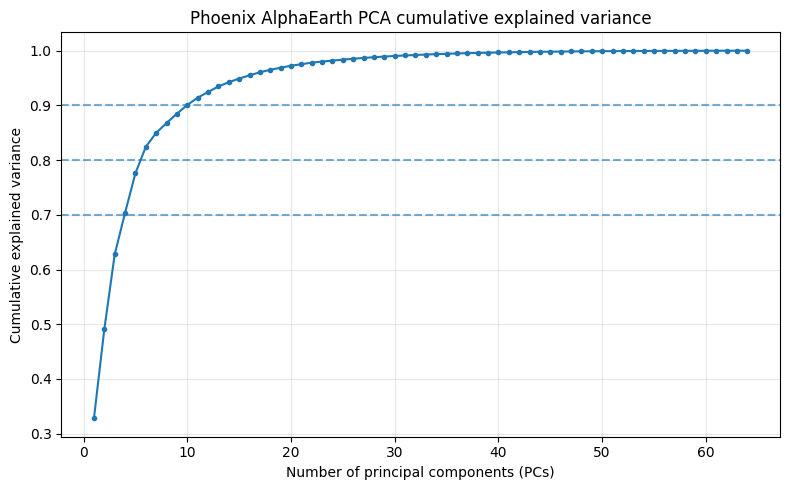


saved summary: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_alphaearth_pca_explained_variance.csv
saved plot: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_alphaearth_pca_cumulative_variance.png


,pc,explained_variance_ratio,cumulative_explained_variance
0,1,0.328011,0.328011
1,2,0.162785,0.490796
2,3,0.136718,0.627514
3,4,0.076176,0.703690
4,5,0.072429,0.776119
5,6,0.048165,0.824284
6,7,0.025586,0.849870
7,8,0.017931,0.867801
8,9,0.017111,0.884912
9,10,0.015924,0.900836


In [45]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =========================================
# files
# =========================================
infile = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_tracts_heat_ready_with_alphaearth_fixed.csv")
out_dir = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth")
out_dir.mkdir(parents=True, exist_ok=True)

# =========================================
# read
# =========================================
df = pd.read_csv(infile, dtype={"GEOID": str}).copy()

band_cols = [f"A{str(i).zfill(2)}" for i in range(64)]
X = df[band_cols].copy()

print("n rows:", len(df))
print("n embedding dims:", len(band_cols))
print("rows with any missing embedding:", X.isna().any(axis=1).sum())

# =========================================
# standardize + PCA
# =========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=len(band_cols), random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cum_explained = explained.cumsum()

pca_summary = pd.DataFrame({
    "pc": np.arange(1, len(explained) + 1),
    "explained_variance_ratio": explained,
    "cumulative_explained_variance": cum_explained
})

summary_csv = out_dir / "phoenix_alphaearth_pca_explained_variance.csv"
pca_summary.to_csv(summary_csv, index=False)

print("\nCumulative explained variance:")
for k in [2, 3, 5, 7, 8, 10, 12]:
    print(f"PC{k}: {cum_explained[k-1]:.4f}")

for thresh in [0.70, 0.80, 0.90]:
    k_hit = int(np.argmax(cum_explained >= thresh) + 1)
    print(f"First PC count reaching {int(thresh*100)}% variance: {k_hit}")

# =========================================
# plot
# =========================================
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pca_summary["pc"], pca_summary["cumulative_explained_variance"], marker="o", markersize=3)
ax.set_xlabel("Number of principal components (PCs)")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("Phoenix AlphaEarth PCA cumulative explained variance")
ax.grid(True, alpha=0.3)

for y in [0.70, 0.80, 0.90]:
    ax.axhline(y, linestyle="--", alpha=0.6)

plot_png = out_dir / "phoenix_alphaearth_pca_cumulative_variance.png"
fig.tight_layout()
fig.savefig(plot_png, dpi=300, bbox_inches="tight")
plt.show()

print("\nsaved summary:", summary_csv)
print("saved plot:", plot_png)

display(pca_summary.head(15))

In [46]:
from pathlib import Path
import pandas as pd
import numpy as np
import geopandas as gpd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =========================================
# files
# =========================================
csv_file = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_tracts_heat_ready_with_alphaearth_fixed.csv")
geojson_file = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_tracts_heat_ready_with_alphaearth_fixed.geojson")
out_dir = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth")
out_dir.mkdir(parents=True, exist_ok=True)

# =========================================
# read
# =========================================
df = pd.read_csv(csv_file, dtype={"GEOID": str}).copy()
gdf = gpd.read_file(geojson_file).copy()
gdf["GEOID"] = gdf["GEOID"].astype(str).str.zfill(11)

band_cols = [f"A{str(i).zfill(2)}" for i in range(64)]
X = df[band_cols].copy()

print("n rows:", len(df))
print("n embedding dims:", len(band_cols))
print("rows with any missing embedding:", X.isna().any(axis=1).sum())

# =========================================
# standardize + PCA
# =========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------- PCA-5 ----------
pca5 = PCA(n_components=5, random_state=42)
scores5 = pca5.fit_transform(X_scaled)

pc5_cols = [f"PC{i}" for i in range(1, 6)]
df_pc5 = pd.DataFrame(scores5, columns=pc5_cols)
df_pc5.insert(0, "GEOID", df["GEOID"].astype(str).str.zfill(11).values)

loadings5 = pd.DataFrame(
    pca5.components_.T,
    index=band_cols,
    columns=pc5_cols
).reset_index().rename(columns={"index": "band"})

ev5 = pd.DataFrame({
    "pc": pc5_cols,
    "explained_variance_ratio": pca5.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca5.explained_variance_ratio_)
})

# ---------- PCA-7 ----------
pca7 = PCA(n_components=7, random_state=42)
scores7 = pca7.fit_transform(X_scaled)

pc7_cols = [f"PC{i}" for i in range(1, 8)]
df_pc7 = pd.DataFrame(scores7, columns=pc7_cols)
df_pc7.insert(0, "GEOID", df["GEOID"].astype(str).str.zfill(11).values)

loadings7 = pd.DataFrame(
    pca7.components_.T,
    index=band_cols,
    columns=pc7_cols
).reset_index().rename(columns={"index": "band"})

ev7 = pd.DataFrame({
    "pc": pc7_cols,
    "explained_variance_ratio": pca7.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca7.explained_variance_ratio_)
})

# =========================================
# save score tables
# =========================================
pc5_csv = out_dir / "phoenix_alphaearth_pc5_scores_corrected.csv"
pc7_csv = out_dir / "phoenix_alphaearth_pc7_scores_corrected.csv"
load5_csv = out_dir / "phoenix_alphaearth_pc5_loadings_corrected.csv"
load7_csv = out_dir / "phoenix_alphaearth_pc7_loadings_corrected.csv"
ev5_csv = out_dir / "phoenix_alphaearth_pc5_explained_variance_corrected.csv"
ev7_csv = out_dir / "phoenix_alphaearth_pc7_explained_variance_corrected.csv"

df_pc5.to_csv(pc5_csv, index=False)
df_pc7.to_csv(pc7_csv, index=False)
loadings5.to_csv(load5_csv, index=False)
loadings7.to_csv(load7_csv, index=False)
ev5.to_csv(ev5_csv, index=False)
ev7.to_csv(ev7_csv, index=False)

# =========================================
# merge back to geojson for map/model use
# =========================================
gdf_pc5 = gdf.merge(df_pc5, on="GEOID", how="left")
gdf_pc7 = gdf.merge(df_pc7, on="GEOID", how="left")

pc5_geojson = out_dir / "phoenix_tracts_with_alphaearth_pc5_corrected.geojson"
pc7_geojson = out_dir / "phoenix_tracts_with_alphaearth_pc7_corrected.geojson"

gdf_pc5.to_file(pc5_geojson, driver="GeoJSON")
gdf_pc7.to_file(pc7_geojson, driver="GeoJSON")

print("\nSaved files:")
for p in [pc5_csv, pc7_csv, load5_csv, load7_csv, ev5_csv, ev7_csv, pc5_geojson, pc7_geojson]:
    print(p.name, "->", p.exists())

print("\nPhoenix PCA-5 cumulative explained variance:")
print(ev5)

print("\nPhoenix PCA-7 cumulative explained variance:")
print(ev7)

print("\nPC5 preview:")
display(df_pc5.head(5))

print("\nPC7 preview:")
display(df_pc7.head(5))

n rows: 373
n embedding dims: 64
rows with any missing embedding: 0

Saved files:
phoenix_alphaearth_pc5_scores_corrected.csv -> True
phoenix_alphaearth_pc7_scores_corrected.csv -> True
phoenix_alphaearth_pc5_loadings_corrected.csv -> True
phoenix_alphaearth_pc7_loadings_corrected.csv -> True
phoenix_alphaearth_pc5_explained_variance_corrected.csv -> True
phoenix_alphaearth_pc7_explained_variance_corrected.csv -> True
phoenix_tracts_with_alphaearth_pc5_corrected.geojson -> True
phoenix_tracts_with_alphaearth_pc7_corrected.geojson -> True

Phoenix PCA-5 cumulative explained variance:
    pc  explained_variance_ratio  cumulative_explained_variance
0  PC1                  0.328011                       0.328011
1  PC2                  0.162785                       0.490796
2  PC3                  0.136718                       0.627514
3  PC4                  0.076176                       0.703690
4  PC5                  0.072429                       0.776119

Phoenix PCA-7 cumulative 

,GEOID,PC1,PC2,PC3,PC4,PC5
0,04013117200,1.374399,-4.205233,5.010405,1.232304,0.687259
1,04013082016,7.566254,-7.824366,-2.542495,-1.041173,-0.969442
2,04013104402,-1.984127,-5.160284,3.558949,-0.706545,2.443564
3,04013104701,-2.385457,1.113713,1.854277,0.510954,-0.278107
4,04013104702,-2.677275,3.445551,1.874132,0.744494,0.010835



PC7 preview:


,GEOID,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,04013117200,1.374399,-4.205233,5.010405,1.232304,0.687259,-0.358525,1.582002
1,04013082016,7.566254,-7.824366,-2.542495,-1.041173,-0.969442,3.220267,-0.769938
2,04013104402,-1.984127,-5.160284,3.558949,-0.706545,2.443564,-1.159313,0.369397
3,04013104701,-2.385457,1.113713,1.854277,0.510954,-0.278107,-3.755992,1.160064
4,04013104702,-2.677275,3.445551,1.874132,0.744494,0.010835,-3.190493,-0.259799


In [49]:
from pathlib import Path
import geopandas as gpd

phx_compare = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_rq1_compare.gpkg")
gdf = gpd.read_file(phx_compare)

print("exists:", phx_compare.exists())
print("n rows:", len(gdf))
print("columns containing 'lst':", [c for c in gdf.columns if "lst" in c.lower()])
print("columns containing 'hi':", [c for c in gdf.columns if "hi" in c.lower()])
print("columns containing 'income':", [c for c in gdf.columns if "income" in c.lower()])
print("columns containing 'poverty':", [c for c in gdf.columns if "poverty" in c.lower()])
print("columns containing 'population' or 'pop':", [c for c in gdf.columns if ("population" in c.lower()) or ("pop" in c.lower())])

exists: True
n rows: 373
columns containing 'lst': ['lst_c', 'lst_hotspot']
columns containing 'hi': ['high_poverty_flag', 'hi_c', 'hi_hotspot']
columns containing 'income': ['median_household_income', 'median_household_income_clean', 'low_income_flag']
columns containing 'poverty': ['poverty_universe', 'below_poverty_count', 'poverty_universe_clean', 'below_poverty_count_clean', 'poverty_rate', 'high_poverty_flag']
columns containing 'population' or 'pop': ['total_population', 'total_population_clean', 'population']


In [50]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd

from sklearn.model_selection import KFold, cross_validate
from sklearn.ensemble import RandomForestRegressor

# =========================================
# files
# =========================================
heat_file = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_rq1_compare.gpkg")
pc5_file = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_alphaearth_pc5_scores_corrected.csv")
out_dir = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth")
out_dir.mkdir(parents=True, exist_ok=True)

# =========================================
# read
# =========================================
gdf_heat = gpd.read_file(heat_file).copy()
df_pc5 = pd.read_csv(pc5_file, dtype={"GEOID": str}).copy()

gdf_heat["GEOID"] = gdf_heat["GEOID"].astype(str).str.zfill(11)
df_pc5["GEOID"] = df_pc5["GEOID"].astype(str).str.zfill(11)

gdf_model = gdf_heat.merge(df_pc5, on="GEOID", how="left")

print("heat rows:", len(gdf_heat))
print("pc rows:", len(df_pc5))
print("merged rows:", len(gdf_model))
print("rows missing any PC:", gdf_model[["PC1","PC2","PC3","PC4","PC5"]].isna().any(axis=1).sum())

# =========================================
# inspect columns
# =========================================
all_cols = list(gdf_model.columns)

lst_candidates_found = [c for c in all_cols if "lst" in c.lower()]
hi_candidates_found = [c for c in all_cols if "hi" in c.lower()]
income_candidates_found = [c for c in all_cols if "income" in c.lower()]
poverty_candidates_found = [c for c in all_cols if "poverty" in c.lower()]
pop_candidates_found = [c for c in all_cols if ("population" in c.lower()) or ("pop" in c.lower())]

print("\nColumns containing 'lst':", lst_candidates_found)
print("\nColumns containing 'hi':", hi_candidates_found)
print("\nColumns containing 'income':", income_candidates_found)
print("\nColumns containing 'poverty':", poverty_candidates_found)
print("\nColumns containing 'population' or 'pop':", pop_candidates_found)

# =========================================
# helper
# =========================================
def pick_first_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

lst_col = pick_first_existing(
    gdf_model,
    ["lst_c", "lst_summer_mean_c", "lst_summer_median_c", "lst_mean_c", "lst_median_c"]
)

hi_col = pick_first_existing(
    gdf_model,
    ["hi_c", "hi_summer_mean_c", "hi_summer_median_c", "heat_index_c", "heat_index_mean_c", "heat_index_median_c"]
)

income_col = pick_first_existing(
    gdf_model,
    ["median_household_income_clean", "median_household_income"]
)

pop_col = pick_first_existing(
    gdf_model,
    ["total_population_clean", "total_population"]
)

poverty_col = pick_first_existing(
    gdf_model,
    ["poverty_rate", "poverty_rate_clean"]
)

print("\nChosen columns:")
print("lst_col:", lst_col)
print("hi_col:", hi_col)
print("income_col:", income_col)
print("pop_col:", pop_col)
print("poverty_col:", poverty_col)

# =========================================
# hard check
# =========================================
required = {
    "lst_col": lst_col,
    "hi_col": hi_col,
    "income_col": income_col,
    "pop_col": pop_col,
}

missing_required = [k for k, v in required.items() if v is None]
if missing_required:
    raise ValueError(f"Missing required columns for Phoenix model: {missing_required}")

# poverty 可选；没有就先不用
base_cols = [income_col, pop_col, "ALAND", "AWATER"]
if poverty_col is not None:
    base_cols.insert(1, poverty_col)

pc_cols = ["PC1", "PC2", "PC3", "PC4", "PC5"]
target_col = "gap_z_hi_minus_lst"

print("\nFinal base_cols:", base_cols)
print("pc_cols:", pc_cols)

# =========================================
# target
# =========================================
gdf_model["gap_raw_hi_minus_lst"] = gdf_model[hi_col] - gdf_model[lst_col]
gdf_model["gap_z_hi_minus_lst"] = (
    (gdf_model[hi_col] - gdf_model[hi_col].mean()) / gdf_model[hi_col].std()
    - (gdf_model[lst_col] - gdf_model[lst_col].mean()) / gdf_model[lst_col].std()
)

# =========================================
# model table
# =========================================
use_cols = base_cols + pc_cols + [target_col]
df_model = gdf_model[use_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()

print("\nmodel rows after dropna:", len(df_model))
print("target mean:", df_model[target_col].mean())
print("target std:", df_model[target_col].std())

X_base = df_model[base_cols]
X_ext = df_model[base_cols + pc_cols]
y = df_model[target_col]

# =========================================
# model
# =========================================
cv = KFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

cv_base = cross_validate(
    rf, X_base, y,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

cv_ext = cross_validate(
    rf, X_ext, y,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

summary = pd.DataFrame([
    {
        "model": "baseline_factors_only",
        "n_features": X_base.shape[1],
        "cv_r2_mean": np.mean(cv_base["test_r2"]),
        "cv_r2_std": np.std(cv_base["test_r2"]),
        "cv_rmse_mean": -np.mean(cv_base["test_rmse"]),
        "cv_rmse_std": np.std(-cv_base["test_rmse"]),
        "cv_mae_mean": -np.mean(cv_base["test_mae"]),
        "cv_mae_std": np.std(-cv_base["test_mae"])
    },
    {
        "model": "extended_factors_plus_PC1_to_PC5",
        "n_features": X_ext.shape[1],
        "cv_r2_mean": np.mean(cv_ext["test_r2"]),
        "cv_r2_std": np.std(cv_ext["test_r2"]),
        "cv_rmse_mean": -np.mean(cv_ext["test_rmse"]),
        "cv_rmse_std": np.std(-cv_ext["test_rmse"]),
        "cv_mae_mean": -np.mean(cv_ext["test_mae"]),
        "cv_mae_std": np.std(-cv_ext["test_mae"])
    }
])

summary["delta_vs_baseline_r2"] = summary["cv_r2_mean"] - summary.loc[0, "cv_r2_mean"]
summary["delta_vs_baseline_rmse"] = summary["cv_rmse_mean"] - summary.loc[0, "cv_rmse_mean"]
summary["delta_vs_baseline_mae"] = summary["cv_mae_mean"] - summary.loc[0, "cv_mae_mean"]

fold_df = pd.DataFrame({
    "fold": np.arange(1, 6),
    "baseline_r2": cv_base["test_r2"],
    "baseline_rmse": -cv_base["test_rmse"],
    "baseline_mae": -cv_base["test_mae"],
    "extended_r2": cv_ext["test_r2"],
    "extended_rmse": -cv_ext["test_rmse"],
    "extended_mae": -cv_ext["test_mae"],
})

summary_csv = out_dir / "phoenix_gap_model_baseline_vs_pc5_rf_cv_corrected.csv"
fold_csv = out_dir / "phoenix_gap_model_baseline_vs_pc5_rf_cv_folds_corrected.csv"

summary.to_csv(summary_csv, index=False)
fold_df.to_csv(fold_csv, index=False)

print("\nSaved summary:", summary_csv)
print("Saved folds:", fold_csv)

display(summary)
display(fold_df)

heat rows: 373
pc rows: 373
merged rows: 373
rows missing any PC: 0

Columns containing 'lst': ['lst_c', 'lst_hotspot']

Columns containing 'hi': ['high_poverty_flag', 'hi_c', 'hi_hotspot']

Columns containing 'income': ['median_household_income', 'median_household_income_clean', 'low_income_flag']

Columns containing 'poverty': ['poverty_universe', 'below_poverty_count', 'poverty_universe_clean', 'below_poverty_count_clean', 'poverty_rate', 'high_poverty_flag']

Columns containing 'population' or 'pop': ['total_population', 'total_population_clean', 'population']

Chosen columns:
lst_col: lst_c
hi_col: hi_c
income_col: median_household_income_clean
pop_col: total_population_clean
poverty_col: poverty_rate

Final base_cols: ['median_household_income_clean', 'poverty_rate', 'total_population_clean', 'ALAND', 'AWATER']
pc_cols: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']

model rows after dropna: 329
target mean: 0.017023660877144
target std: 1.1980651187332418

Saved summary: /Users/yufeizhou/D

,model,n_features,cv_r2_mean,cv_r2_std,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,delta_vs_baseline_r2,delta_vs_baseline_rmse,delta_vs_baseline_mae
0,baseline_factors_only,5,0.133045,0.107719,1.104907,0.065687,0.888023,0.060962,0.000000,0.000000,0.000000
1,extended_factors_plus_PC1_to_PC5,10,0.598139,0.055565,0.752173,0.057849,0.585425,0.036711,0.465094,-0.352735,-0.302598


,fold,baseline_r2,baseline_rmse,baseline_mae,extended_r2,extended_rmse,extended_mae
0,1,0.007666,1.181535,0.958558,0.585414,0.763704,0.566951
1,2,0.300288,0.993970,0.809675,0.702745,0.647856,0.530213
2,3,0.023766,1.073369,0.831979,0.536511,0.739591,0.588035
3,4,0.159231,1.148611,0.953778,0.589242,0.802838,0.641165
4,5,0.174271,1.127053,0.886124,0.576784,0.806876,0.600762


In [58]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd

from sklearn.model_selection import KFold, cross_validate
from sklearn.ensemble import RandomForestRegressor

# ========================================
# fixed Phoenix file only
# ========================================
heat_file = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_rq1_compare.gpkg")
pc7_file = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_alphaearth_pc7_scores_corrected.csv")
out_dir = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth")
out_dir.mkdir(parents=True, exist_ok=True)

# ========================================
# read
# ========================================
gdf_heat = gpd.read_file(heat_file).copy()
df_pc7 = pd.read_csv(pc7_file, dtype={"GEOID": str}).copy()

gdf_heat["GEOID"] = gdf_heat["GEOID"].astype(str).str.zfill(11)
df_pc7["GEOID"] = df_pc7["GEOID"].astype(str).str.zfill(11)

gdf_model = gdf_heat.merge(df_pc7, on="GEOID", how="left")

print("Chosen heat file:", heat_file)
print("heat rows:", len(gdf_heat))
print("pc7 rows:", len(df_pc7))
print("merged rows:", len(gdf_model))
print("rows missing any PC7:", gdf_model[[f"PC{i}" for i in range(1, 8)]].isna().any(axis=1).sum())

# ========================================
# fixed columns from phoenix_rq1_compare
# ========================================
lst_col = "lst_c"
hi_col = "hi_c"
income_col = "median_household_income_clean"
pop_col = "total_population_clean"
poverty_col = "poverty_rate"

base_cols = [income_col, poverty_col, pop_col, "ALAND", "AWATER"]
pc_cols = [f"PC{i}" for i in range(1, 8)]
target_col = "gap_z_hi_minus_lst"

# numeric
for c in [lst_col, hi_col] + base_cols:
    gdf_model[c] = pd.to_numeric(gdf_model[c], errors="coerce")

print("\nNon-null counts:")
for c in [lst_col, hi_col] + base_cols:
    print(c, gdf_model[c].notna().sum())

# target
lst_std = gdf_model[lst_col].std()
hi_std = gdf_model[hi_col].std()

print("\nlst std:", lst_std)
print("hi std:", hi_std)

gdf_model["lst_z"] = (gdf_model[lst_col] - gdf_model[lst_col].mean()) / lst_std
gdf_model["hi_z"] = (gdf_model[hi_col] - gdf_model[hi_col].mean()) / hi_std
gdf_model[target_col] = gdf_model["hi_z"] - gdf_model["lst_z"]

print("\nTarget non-null count:", gdf_model[target_col].notna().sum())
print("Target missing count:", gdf_model[target_col].isna().sum())

# keep usable rows
use_cols = base_cols + pc_cols + [target_col]

missing_summary = pd.DataFrame({
    "column": use_cols,
    "missing_n": [gdf_model[c].isna().sum() for c in use_cols],
    "missing_pct": [gdf_model[c].isna().mean() for c in use_cols],
})
print("\nMissingness summary:")
display(missing_summary)

df_model = gdf_model[use_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()

print("\nmodel rows after dropna:", len(df_model))
print("target mean:", df_model[target_col].mean())
print("target std:", df_model[target_col].std())

# model
X_base = df_model[base_cols]
X_ext = df_model[base_cols + pc_cols]
y = df_model[target_col]

cv = KFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

cv_base = cross_validate(
    rf, X_base, y,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

cv_ext = cross_validate(
    rf, X_ext, y,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

summary = pd.DataFrame([
    {
        "model": "baseline_factors_only",
        "n_features": X_base.shape[1],
        "cv_r2_mean": np.mean(cv_base["test_r2"]),
        "cv_r2_std": np.std(cv_base["test_r2"]),
        "cv_rmse_mean": -np.mean(cv_base["test_rmse"]),
        "cv_rmse_std": np.std(-cv_base["test_rmse"]),
        "cv_mae_mean": -np.mean(cv_base["test_mae"]),
        "cv_mae_std": np.std(-cv_base["test_mae"])
    },
    {
        "model": "extended_factors_plus_PC1_to_PC7",
        "n_features": X_ext.shape[1],
        "cv_r2_mean": np.mean(cv_ext["test_r2"]),
        "cv_r2_std": np.std(cv_ext["test_r2"]),
        "cv_rmse_mean": -np.mean(cv_ext["test_rmse"]),
        "cv_rmse_std": np.std(-cv_ext["test_rmse"]),
        "cv_mae_mean": -np.mean(cv_ext["test_mae"]),
        "cv_mae_std": np.std(-cv_ext["test_mae"])
    }
])

summary["delta_vs_baseline_r2"] = summary["cv_r2_mean"] - summary.loc[0, "cv_r2_mean"]
summary["delta_vs_baseline_rmse"] = summary["cv_rmse_mean"] - summary.loc[0, "cv_rmse_mean"]
summary["delta_vs_baseline_mae"] = summary["cv_mae_mean"] - summary.loc[0, "cv_mae_mean"]

fold_df = pd.DataFrame({
    "fold": np.arange(1, 6),
    "baseline_r2": cv_base["test_r2"],
    "baseline_rmse": -cv_base["test_rmse"],
    "baseline_mae": -cv_base["test_mae"],
    "extended7_r2": cv_ext["test_r2"],
    "extended7_rmse": -cv_ext["test_rmse"],
    "extended7_mae": -cv_ext["test_mae"],
})

summary_csv = out_dir / "phoenix_gap_model_baseline_vs_pc7_rf_cv_corrected.csv"
fold_csv = out_dir / "phoenix_gap_model_baseline_vs_pc7_rf_cv_folds_corrected.csv"

summary.to_csv(summary_csv, index=False)
fold_df.to_csv(fold_csv, index=False)

print("\nSaved summary:", summary_csv)
print("Saved folds:", fold_csv)

display(summary)
display(fold_df)

Chosen heat file: /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_rq1_compare.gpkg
heat rows: 373
pc7 rows: 373
merged rows: 373
rows missing any PC7: 0

Non-null counts:
lst_c 373
hi_c 332
median_household_income_clean 368
poverty_rate 370
total_population_clean 373
ALAND 373
AWATER 373

lst std: 1.7391725690452353
hi std: 0.564869990102091

Target non-null count: 332
Target missing count: 41

Missingness summary:


,column,missing_n,missing_pct
0,median_household_income_clean,5,0.013405
1,poverty_rate,3,0.008043
2,total_population_clean,0,0.000000
3,ALAND,0,0.000000
4,AWATER,0,0.000000
5,PC1,0,0.000000
6,PC2,0,0.000000
7,PC3,0,0.000000
8,PC4,0,0.000000
9,PC5,0,0.000000



model rows after dropna: 329
target mean: 0.017023660877144
target std: 1.1980651187332418

Saved summary: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_gap_model_baseline_vs_pc7_rf_cv_corrected.csv
Saved folds: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_gap_model_baseline_vs_pc7_rf_cv_folds_corrected.csv


,model,n_features,cv_r2_mean,cv_r2_std,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,delta_vs_baseline_r2,delta_vs_baseline_rmse,delta_vs_baseline_mae
0,baseline_factors_only,5,0.133045,0.107719,1.104907,0.065687,0.888023,0.060962,0.000000,0.000000,0.000000
1,extended_factors_plus_PC1_to_PC7,12,0.617754,0.050435,0.734051,0.057851,0.564994,0.053333,0.484709,-0.370857,-0.323029


,fold,baseline_r2,baseline_rmse,baseline_mae,extended7_r2,extended7_rmse,extended7_mae
0,1,0.007666,1.181535,0.958558,0.623875,0.727417,0.527529
1,2,0.300288,0.993970,0.809675,0.711046,0.638747,0.507520
2,3,0.023766,1.073369,0.831979,0.564609,0.716823,0.549263
3,4,0.159231,1.148611,0.953778,0.588183,0.803872,0.659976
4,5,0.174271,1.127053,0.886124,0.601059,0.783394,0.580679


model rows: 329
features: ['median_household_income_clean', 'poverty_rate', 'total_population_clean', 'ALAND', 'AWATER', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7']

Saved SHAP importance: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_gap_extended_rf_shap_importance.csv


,feature,mean_abs_shap
7,PC3,0.353159
9,PC5,0.241609
6,PC2,0.177392
5,PC1,0.171261
8,PC4,0.096658
10,PC6,0.084302
11,PC7,0.069888
3,ALAND,0.054042
1,poverty_rate,0.049925
0,median_household_income_clean,0.021040


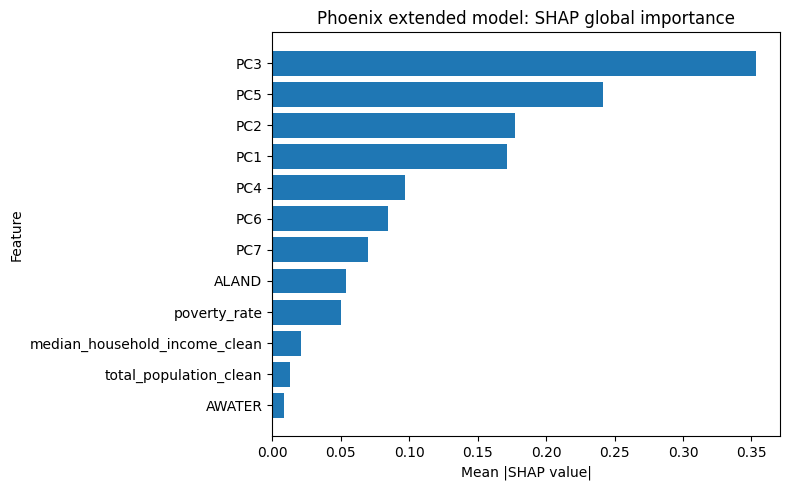

Saved SHAP bar plot: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_gap_extended_rf_shap_bar.png


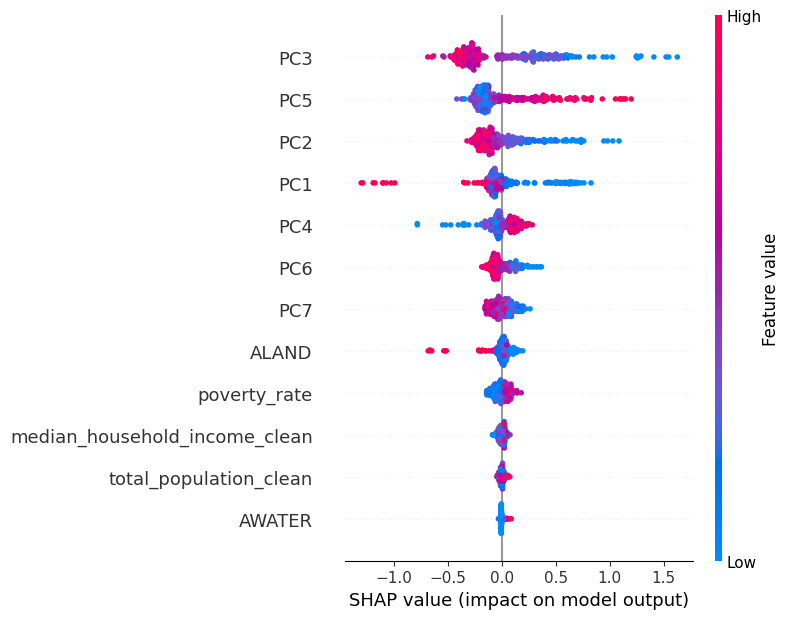

Saved SHAP summary plot: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_gap_extended_rf_shap_summary.png


In [59]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# try import shap
try:
    import shap
except ImportError:
    raise ImportError("shap not installed. Run: %pip install shap")

# ========================================
# fixed Phoenix files
# ========================================
heat_file = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_rq1_compare.gpkg")
pc7_file = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_alphaearth_pc7_scores_corrected.csv")
out_dir = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth")
out_dir.mkdir(parents=True, exist_ok=True)

# ========================================
# read + merge
# ========================================
gdf_heat = gpd.read_file(heat_file).copy()
df_pc7 = pd.read_csv(pc7_file, dtype={"GEOID": str}).copy()

gdf_heat["GEOID"] = gdf_heat["GEOID"].astype(str).str.zfill(11)
df_pc7["GEOID"] = df_pc7["GEOID"].astype(str).str.zfill(11)

gdf_model = gdf_heat.merge(df_pc7, on="GEOID", how="left")

# ========================================
# fixed columns
# ========================================
lst_col = "lst_c"
hi_col = "hi_c"
feature_cols = [
    "median_household_income_clean",
    "poverty_rate",
    "total_population_clean",
    "ALAND",
    "AWATER",
    "PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7"
]
target_col = "gap_z_hi_minus_lst"

# numeric
for c in [lst_col, hi_col] + feature_cols:
    gdf_model[c] = pd.to_numeric(gdf_model[c], errors="coerce")

# target
lst_std = gdf_model[lst_col].std()
hi_std = gdf_model[hi_col].std()

gdf_model["lst_z"] = (gdf_model[lst_col] - gdf_model[lst_col].mean()) / lst_std
gdf_model["hi_z"] = (gdf_model[hi_col] - gdf_model[hi_col].mean()) / hi_std
gdf_model[target_col] = gdf_model["hi_z"] - gdf_model["lst_z"]

# model df
df_model = gdf_model[feature_cols + [target_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()

print("model rows:", len(df_model))
print("features:", feature_cols)

X = df_model[feature_cols]
y = df_model[target_col]

# ========================================
# fit model
# ========================================
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
rf.fit(X, y)

# ========================================
# SHAP
# ========================================
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

# mean absolute shap
importance = pd.DataFrame({
    "feature": X.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

importance_csv = out_dir / "phoenix_gap_extended_rf_shap_importance.csv"
importance.to_csv(importance_csv, index=False)

print("\nSaved SHAP importance:", importance_csv)
display(importance)

# ========================================
# SHAP bar plot
# ========================================
bar_png = out_dir / "phoenix_gap_extended_rf_shap_bar.png"

plt.figure(figsize=(8, 5))
plt.barh(importance["feature"][::-1], importance["mean_abs_shap"][::-1])
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title("Phoenix extended model: SHAP global importance")
plt.tight_layout()
plt.savefig(bar_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved SHAP bar plot:", bar_png)

# ========================================
# SHAP summary plot
# ========================================
summary_png = out_dir / "phoenix_gap_extended_rf_shap_summary.png"

plt.figure()
shap.summary_plot(shap_values, X, show=False)
plt.tight_layout()
plt.savefig(summary_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved SHAP summary plot:", summary_png)

Saved summary table: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_alphaearth_model_comparison_summary.csv


,city,pc_set,baseline_r2,extended_r2,delta_r2,baseline_rmse,extended_rmse,delta_rmse,baseline_mae,extended_mae,delta_mae,n_features_extended
0,Houston,PC5,0.111643,0.427186,0.315543,1.100080,0.884146,-0.215934,0.788299,0.634479,-0.153820,10
1,Houston,PC7,0.111643,0.445235,0.333592,1.100080,0.870358,-0.229722,0.788299,0.618177,-0.170123,12
2,Phoenix,PC5,0.133045,0.598139,0.465094,1.104907,0.752173,-0.352735,0.888023,0.585425,-0.302598,10
3,Phoenix,PC7,0.133045,0.617754,0.484709,1.104907,0.734051,-0.370857,0.888023,0.564994,-0.323029,12


Saved meeting table: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_alphaearth_model_comparison_meeting_table.csv


,city,pc_set,baseline_r2,extended_r2,delta_r2,baseline_rmse,extended_rmse,delta_rmse,baseline_mae,extended_mae,delta_mae
0,Houston,PC5,0.111643,0.427186,0.315543,1.100080,0.884146,-0.215934,0.788299,0.634479,-0.153820
1,Houston,PC7,0.111643,0.445235,0.333592,1.100080,0.870358,-0.229722,0.788299,0.618177,-0.170123
2,Phoenix,PC5,0.133045,0.598139,0.465094,1.104907,0.752173,-0.352735,0.888023,0.585425,-0.302598
3,Phoenix,PC7,0.133045,0.617754,0.484709,1.104907,0.734051,-0.370857,0.888023,0.564994,-0.323029


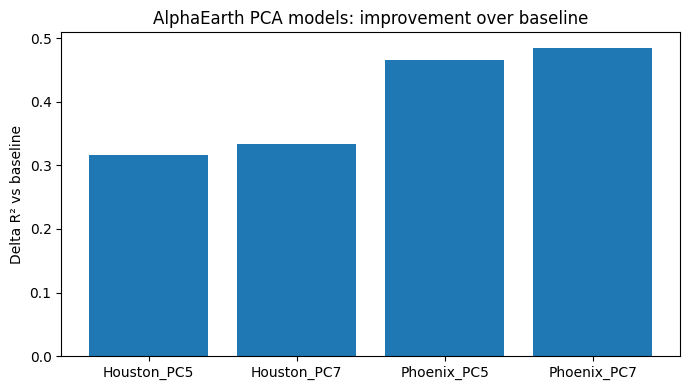

Saved plot: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_alphaearth_delta_r2_comparison.png
Saved best-model table: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_alphaearth_best_model_by_city.csv


,city,pc_set,baseline_r2,extended_r2,delta_r2,baseline_rmse,extended_rmse,delta_rmse,baseline_mae,extended_mae,delta_mae,n_features_extended
1,Houston,PC7,0.111643,0.445235,0.333592,1.100080,0.870358,-0.229722,0.788299,0.618177,-0.170123,12
3,Phoenix,PC7,0.133045,0.617754,0.484709,1.104907,0.734051,-0.370857,0.888023,0.564994,-0.323029,12


In [60]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

out_dir = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth")

files = {
    ("Houston", "PC5"): out_dir / "houston_gap_model_baseline_vs_pc5_rf_cv_corrected.csv",
    ("Houston", "PC7"): out_dir / "houston_gap_model_baseline_vs_pc7_rf_cv_corrected.csv",
    ("Phoenix", "PC5"): out_dir / "phoenix_gap_model_baseline_vs_pc5_rf_cv_corrected.csv",
    ("Phoenix", "PC7"): out_dir / "phoenix_gap_model_baseline_vs_pc7_rf_cv_corrected.csv",
}

records = []

for (city, pc_set), f in files.items():
    if not f.exists():
        print("Missing file:", f)
        continue

    df = pd.read_csv(f)

    base = df[df["model"] == "baseline_factors_only"].iloc[0]
    ext = df[df["model"].str.contains("extended", case=False, na=False)].iloc[0]

    records.append({
        "city": city,
        "pc_set": pc_set,
        "baseline_r2": base["cv_r2_mean"],
        "extended_r2": ext["cv_r2_mean"],
        "delta_r2": ext["cv_r2_mean"] - base["cv_r2_mean"],
        "baseline_rmse": base["cv_rmse_mean"],
        "extended_rmse": ext["cv_rmse_mean"],
        "delta_rmse": ext["cv_rmse_mean"] - base["cv_rmse_mean"],
        "baseline_mae": base["cv_mae_mean"],
        "extended_mae": ext["cv_mae_mean"],
        "delta_mae": ext["cv_mae_mean"] - base["cv_mae_mean"],
        "n_features_extended": ext["n_features"],
    })

compare_df = pd.DataFrame(records).sort_values(["city", "pc_set"]).reset_index(drop=True)

summary_csv = out_dir / "city_alphaearth_model_comparison_summary.csv"
compare_df.to_csv(summary_csv, index=False)

print("Saved summary table:", summary_csv)
display(compare_df)

# ----------------------------------------
# meeting-friendly short table
# ----------------------------------------
meeting_df = compare_df[[
    "city", "pc_set",
    "baseline_r2", "extended_r2", "delta_r2",
    "baseline_rmse", "extended_rmse", "delta_rmse",
    "baseline_mae", "extended_mae", "delta_mae"
]].copy()

meeting_df = meeting_df.sort_values(["city", "pc_set"]).reset_index(drop=True)

meeting_csv = out_dir / "city_alphaearth_model_comparison_meeting_table.csv"
meeting_df.to_csv(meeting_csv, index=False)

print("Saved meeting table:", meeting_csv)
display(meeting_df)

# ----------------------------------------
# simple plot: delta R2
# ----------------------------------------
plot_png = out_dir / "city_alphaearth_delta_r2_comparison.png"

plt.figure(figsize=(7, 4))
labels = compare_df["city"] + "_" + compare_df["pc_set"]
plt.bar(labels, compare_df["delta_r2"])
plt.ylabel("Delta R² vs baseline")
plt.title("AlphaEarth PCA models: improvement over baseline")
plt.tight_layout()
plt.savefig(plot_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_png)

# ----------------------------------------
# best model per city
# ----------------------------------------
best_df = compare_df.sort_values(["city", "extended_r2"], ascending=[True, False]).groupby("city").head(1)
best_csv = out_dir / "city_alphaearth_best_model_by_city.csv"
best_df.to_csv(best_csv, index=False)

print("Saved best-model table:", best_csv)
display(best_df)

In [61]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =========================================================
# files
# =========================================================
out_dir = Path("/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth")

city_files = {
    "Houston": out_dir / "houston_alphaearth_2024_tract_mean_mosaic_clean.csv",
    "Phoenix": out_dir / "phoenix_alphaearth_2024_tract_mean_mosaic_clean.csv",
}

top_k = 6  # each PC: top 6 positive + top 6 negative loadings

compact_rows = []
long_rows = []

for city, f in city_files.items():
    if not f.exists():
        raise FileNotFoundError(f"Missing file: {f}")

    df = pd.read_csv(f, dtype={"GEOID": str}).copy()

    # exact embedding columns only: A00-A63
    dim_cols = sorted([c for c in df.columns if len(c) == 3 and c.startswith("A") and c[1:].isdigit()])
    print(f"\n===== {city} =====")
    print("file:", f)
    print("n rows:", len(df))
    print("n embedding dims:", len(dim_cols))
    print("first dims:", dim_cols[:5], "last dims:", dim_cols[-5:])

    X = df[dim_cols].apply(pd.to_numeric, errors="coerce")
    print("rows with any missing embedding:", X.isna().any(axis=1).sum())

    X = X.dropna().copy()

    # standardize before PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=4)
    pca.fit(X_scaled)

    pcs = [f"PC{i}" for i in range(1, 5)]

    # loadings
    loadings = pd.DataFrame(
        pca.components_.T,
        index=dim_cols,
        columns=pcs
    )

    # explained variance
    evr = pd.DataFrame({
        "city": city,
        "pc": pcs,
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_)
    })

    print("\nExplained variance:")
    display(evr)

    # save full loadings
    full_loadings_out = out_dir / f"{city.lower()}_alphaearth_top4_loadings_full.csv"
    loadings.reset_index().rename(columns={"index": "embedding_dim"}).to_csv(full_loadings_out, index=False)

    evr_out = out_dir / f"{city.lower()}_alphaearth_top4_explained_variance_summary.csv"
    evr.to_csv(evr_out, index=False)

    # build summaries
    for pc in pcs:
        s = loadings[pc].sort_values(ascending=False)

        top_pos = s.head(top_k)
        top_neg = s.tail(top_k)

        compact_rows.append({
            "city": city,
            "pc": pc,
            "explained_variance_ratio": float(evr.loc[evr["pc"] == pc, "explained_variance_ratio"].iloc[0]),
            "cumulative_explained_variance": float(evr.loc[evr["pc"] == pc, "cumulative_explained_variance"].iloc[0]),
            "top_positive_dims": ", ".join([f"{d}({v:.3f})" for d, v in top_pos.items()]),
            "top_negative_dims": ", ".join([f"{d}({v:.3f})" for d, v in top_neg.items()]),
        })

        for rank, (dim, val) in enumerate(top_pos.items(), start=1):
            long_rows.append({
                "city": city,
                "pc": pc,
                "sign": "positive",
                "rank": rank,
                "embedding_dim": dim,
                "loading": float(val),
                "abs_loading": float(abs(val)),
                "explained_variance_ratio": float(evr.loc[evr["pc"] == pc, "explained_variance_ratio"].iloc[0]),
                "cumulative_explained_variance": float(evr.loc[evr["pc"] == pc, "cumulative_explained_variance"].iloc[0]),
            })

        for rank, (dim, val) in enumerate(top_neg.items(), start=1):
            long_rows.append({
                "city": city,
                "pc": pc,
                "sign": "negative",
                "rank": rank,
                "embedding_dim": dim,
                "loading": float(val),
                "abs_loading": float(abs(val)),
                "explained_variance_ratio": float(evr.loc[evr["pc"] == pc, "explained_variance_ratio"].iloc[0]),
                "cumulative_explained_variance": float(evr.loc[evr["pc"] == pc, "cumulative_explained_variance"].iloc[0]),
            })

    print("saved full loadings:", full_loadings_out)
    print("saved EVR summary:", evr_out)

# save summary tables
compact_df = pd.DataFrame(compact_rows)
long_df = pd.DataFrame(long_rows).sort_values(["city", "pc", "sign", "rank"]).reset_index(drop=True)

compact_out = out_dir / "city_top4_pc_loading_compact_summary.csv"
long_out = out_dir / "city_top4_pc_loading_long_summary.csv"

compact_df.to_csv(compact_out, index=False)
long_df.to_csv(long_out, index=False)

print("\nSaved compact summary:", compact_out)
print("Saved long summary:", long_out)

print("\n===== Compact summary (for reading) =====")
display(compact_df)

print("\n===== Long summary preview =====")
display(long_df.head(24))


===== Houston =====
file: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_2024_tract_mean_mosaic_clean.csv
n rows: 654
n embedding dims: 64
first dims: ['A00', 'A01', 'A02', 'A03', 'A04'] last dims: ['A59', 'A60', 'A61', 'A62', 'A63']
rows with any missing embedding: 0

Explained variance:


,city,pc,explained_variance_ratio,cumulative_explained_variance
0,Houston,PC1,0.331658,0.331658
1,Houston,PC2,0.179263,0.510921
2,Houston,PC3,0.090775,0.601696
3,Houston,PC4,0.071793,0.673489


saved full loadings: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_top4_loadings_full.csv
saved EVR summary: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_top4_explained_variance_summary.csv

===== Phoenix =====
file: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_alphaearth_2024_tract_mean_mosaic_clean.csv
n rows: 373
n embedding dims: 64
first dims: ['A00', 'A01', 'A02', 'A03', 'A04'] last dims: ['A59', 'A60', 'A61', 'A62', 'A63']
rows with any missing embedding: 0

Explained variance:


,city,pc,explained_variance_ratio,cumulative_explained_variance
0,Phoenix,PC1,0.328011,0.328011
1,Phoenix,PC2,0.162785,0.490796
2,Phoenix,PC3,0.136718,0.627514
3,Phoenix,PC4,0.076176,0.703690


saved full loadings: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_alphaearth_top4_loadings_full.csv
saved EVR summary: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_alphaearth_top4_explained_variance_summary.csv

Saved compact summary: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_top4_pc_loading_compact_summary.csv
Saved long summary: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_top4_pc_loading_long_summary.csv

===== Compact summary (for reading) =====


,city,pc,explained_variance_ratio,cumulative_explained_variance,top_positive_dims,top_negative_dims
0,Houston,PC1,0.331658,0.331658,"A56(0.197), A16(0.194), A34(0.192), A50(0.179), A20(0.176), A00(0.175)","A41(-0.170), A55(-0.171), A01(-0.177), A62(-0.180), A13(-0.184), A07(-0.196)"
1,Houston,PC2,0.179263,0.510921,"A32(0.259), A51(0.235), A12(0.197), A30(0.160), A40(0.148), A63(0.141)","A18(-0.193), A44(-0.196), A43(-0.208), A08(-0.218), A42(-0.229), A25(-0.229)"
2,Houston,PC3,0.090775,0.601696,"A17(0.286), A02(0.266), A21(0.232), A46(0.213), A50(0.164), A03(0.164)","A09(-0.201), A19(-0.224), A38(-0.238), A24(-0.254), A28(-0.262), A31(-0.273)"
3,Houston,PC4,0.071793,0.673489,"A04(0.317), A59(0.312), A25(0.226), A40(0.193), A05(0.186), A19(0.166)","A62(-0.177), A48(-0.183), A37(-0.198), A11(-0.207), A15(-0.213), A22(-0.296)"
4,Phoenix,PC1,0.328011,0.328011,"A52(0.208), A40(0.200), A01(0.200), A62(0.199), A36(0.198), A46(0.196)","A43(-0.167), A50(-0.171), A02(-0.176), A48(-0.178), A57(-0.183), A34(-0.188)"
5,Phoenix,PC2,0.162785,0.490796,"A04(0.285), A44(0.245), A61(0.241), A23(0.233), A17(0.202), A05(0.188)","A26(-0.148), A13(-0.150), A06(-0.160), A37(-0.176), A35(-0.234), A63(-0.249)"
6,Phoenix,PC3,0.136718,0.627514,"A58(0.284), A09(0.268), A16(0.218), A21(0.197), A32(0.195), A38(0.193)","A07(-0.180), A15(-0.183), A33(-0.187), A24(-0.187), A59(-0.229), A22(-0.249)"
7,Phoenix,PC4,0.076176,0.703690,"A19(0.336), A47(0.300), A31(0.250), A17(0.231), A28(0.211), A49(0.199)","A61(-0.143), A53(-0.144), A09(-0.149), A08(-0.170), A03(-0.258), A26(-0.264)"



===== Long summary preview =====


,city,pc,sign,rank,embedding_dim,loading,abs_loading,explained_variance_ratio,cumulative_explained_variance
0,Houston,PC1,negative,1,A41,-0.170361,0.170361,0.331658,0.331658
1,Houston,PC1,negative,2,A55,-0.170779,0.170779,0.331658,0.331658
2,Houston,PC1,negative,3,A01,-0.177022,0.177022,0.331658,0.331658
3,Houston,PC1,negative,4,A62,-0.179683,0.179683,0.331658,0.331658
4,Houston,PC1,negative,5,A13,-0.184154,0.184154,0.331658,0.331658
5,Houston,PC1,negative,6,A07,-0.195572,0.195572,0.331658,0.331658
6,Houston,PC1,positive,1,A56,0.197495,0.197495,0.331658,0.331658
7,Houston,PC1,positive,2,A16,0.194309,0.194309,0.331658,0.331658
8,Houston,PC1,positive,3,A34,0.192248,0.192248,0.331658,0.331658
9,Houston,PC1,positive,4,A50,0.179460,0.179460,0.331658,0.331658


In [64]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd

# =========================================================
# paths
# =========================================================
project_root = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")
out_dir = project_root / "outputs/pilot/alphaearth"

city_cfg = {
    "Houston": {
        "embed_file": out_dir / "houston_alphaearth_2024_tract_mean_mosaic_clean.csv",
        "heat_file": project_root / "data_processed/houston/houston_master_with_lst_hi_fixed.gpkg",
    },
    "Phoenix": {
        "embed_file": out_dir / "phoenix_alphaearth_2024_tract_mean_mosaic_clean.csv",
        "heat_file": project_root / "data_processed/phoenix/phoenix_master_with_lst_hi_fixed.gpkg",
    },
}

long_summary_file = out_dir / "city_top4_pc_loading_long_summary.csv"
long_df = pd.read_csv(long_summary_file).copy()
long_df["pc_num"] = long_df["pc"].str.extract(r"(\d+)").astype(int)
long_df = long_df[long_df["pc_num"] <= 4].copy()

# =========================================================
# helpers
# =========================================================
def normalize_geoid(series):
    s = pd.Series(series, dtype="string")
    s = s.str.replace(r"\.0$", "", regex=True)          # remove trailing .0
    s = s.str.extract(r"(\d+)", expand=False)           # keep digits only
    s = s.str.zfill(11)                                 # tract GEOID length
    return s

def top_dim_string(sub, k=3):
    sub2 = sub.sort_values("abs_spearman_r", ascending=False).head(k)
    parts = []
    for _, r in sub2.iterrows():
        if pd.isna(r["spearman_r"]):
            continue
        parts.append(f'{r["embedding_dim"]}({r["spearman_r"]:.3f})')
    return ", ".join(parts)

# =========================================================
# compute dim-factor correlations
# =========================================================
corr_rows = []

for city, cfg in city_cfg.items():
    print(f"\n===== {city} =====")
    print("embed exists:", cfg["embed_file"].exists(), cfg["embed_file"])
    print("heat exists:", cfg["heat_file"].exists(), cfg["heat_file"])

    # read embedding
    embed_df = pd.read_csv(cfg["embed_file"], dtype={"GEOID": str}).copy()
    embed_df["GEOID"] = normalize_geoid(embed_df["GEOID"])

    # read heat/social file
    gdf = gpd.read_file(cfg["heat_file"]).copy()
    gdf["GEOID"] = normalize_geoid(gdf["GEOID"])

    heat_df = gdf.drop(columns="geometry", errors="ignore").copy()

    # force numeric when possible
    for col in heat_df.columns:
        if col != "GEOID":
            heat_df[col] = pd.to_numeric(heat_df[col], errors="coerce")

    # derived gap
    if {"hi_c", "lst_c"}.issubset(heat_df.columns):
        heat_df["hi_minus_lst"] = heat_df["hi_c"] - heat_df["lst_c"]

    print("embed GEOID sample:", embed_df["GEOID"].head().tolist())
    print("heat GEOID sample:", heat_df["GEOID"].head().tolist())

    merged = heat_df.merge(embed_df, on="GEOID", how="inner")

    print("heat rows:", len(heat_df))
    print("embed rows:", len(embed_df))
    print("merged rows:", len(merged))

    city_load = long_df[long_df["city"] == city].copy()
    selected_dims = sorted(city_load["embedding_dim"].unique())
    print("selected dims:", selected_dims)

    candidate_vars = [
        "lst_c",
        "hi_c",
        "hi_minus_lst",
        "median_household_income_clean",
        "poverty_rate",
        "total_population_clean",
        "ALAND",
        "AWATER",
    ]
    use_vars = [v for v in candidate_vars if v in merged.columns]
    print("observable vars used:", use_vars)

    for dim in selected_dims:
        merged[dim] = pd.to_numeric(merged[dim], errors="coerce")
    for v in use_vars:
        merged[v] = pd.to_numeric(merged[v], errors="coerce")

    for _, row in city_load.iterrows():
        dim = row["embedding_dim"]

        for v in use_vars:
            tmp = merged[[dim, v]].dropna().copy()
            n = len(tmp)

            if n < 20:
                r = np.nan
            else:
                r = tmp[dim].corr(tmp[v], method="spearman")

            corr_rows.append({
                "city": city,
                "pc": row["pc"],
                "pc_num": int(row["pc_num"]),
                "sign": row["sign"],
                "rank": int(row["rank"]),
                "embedding_dim": dim,
                "loading": float(row["loading"]),
                "abs_loading": float(abs(row["loading"])),
                "variable": v,
                "spearman_r": r,
                "abs_spearman_r": np.nan if pd.isna(r) else abs(r),
                "n": n,
            })

corr_df = pd.DataFrame(corr_rows)

# =========================================================
# summary 1: top observable factors per PC
# =========================================================
pc_var_summary = (
    corr_df
    .groupby(["city", "pc", "pc_num", "variable"], as_index=False)
    .agg(
        n_dims=("embedding_dim", "nunique"),
        mean_abs_spearman_r=("abs_spearman_r", "mean"),
        max_abs_spearman_r=("abs_spearman_r", "max"),
    )
)

top_dims_df = (
    corr_df
    .groupby(["city", "pc", "pc_num", "variable"], group_keys=False)
    .apply(lambda sub: pd.Series({"top_dims": top_dim_string(sub, k=3)}))
    .reset_index()
)

pc_var_summary = pc_var_summary.merge(
    top_dims_df,
    on=["city", "pc", "pc_num", "variable"],
    how="left"
)

pc_var_summary = pc_var_summary.sort_values(
    ["city", "pc_num", "mean_abs_spearman_r"],
    ascending=[True, True, False]
).reset_index(drop=True)

pc_var_top = (
    pc_var_summary
    .groupby(["city", "pc"], group_keys=False)
    .head(4)
    .reset_index(drop=True)
)

# =========================================================
# summary 2: strongest dim-factor links
# =========================================================
dim_factor_top = (
    corr_df
    .sort_values(["city", "pc_num", "abs_spearman_r"], ascending=[True, True, False])
    .groupby(["city", "pc"], group_keys=False)
    .head(8)
    .reset_index(drop=True)
)

# =========================================================
# save
# =========================================================
corr_out = out_dir / "city_top4_pc_dim_factor_spearman_long.csv"
pc_var_out = out_dir / "city_top4_pc_factor_summary.csv"
pc_var_top_out = out_dir / "city_top4_pc_factor_top4.csv"
dim_factor_top_out = out_dir / "city_top4_pc_dim_factor_top8.csv"

corr_df.to_csv(corr_out, index=False)
pc_var_summary.to_csv(pc_var_out, index=False)
pc_var_top.to_csv(pc_var_top_out, index=False)
dim_factor_top.to_csv(dim_factor_top_out, index=False)

print("\nSaved long dim-factor table:", corr_out)
print("Saved PC-factor summary:", pc_var_out)
print("Saved top-4 factors per PC:", pc_var_top_out)
print("Saved top dim-factor links:", dim_factor_top_out)

print("\n===== Top observable factors linked to each PC =====")
display(pc_var_top)

print("\n===== Strongest dim-factor links preview =====")
display(dim_factor_top.head(24))


===== Houston =====
embed exists: True /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_2024_tract_mean_mosaic_clean.csv
heat exists: True /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_with_lst_hi_fixed.gpkg
embed GEOID sample: ['48201421101', '48201423301', '48201453401', '48201331100', '48201331200']
heat GEOID sample: ['48201421101', '48201423301', '48201453401', '48201331100', '48201331200']
heat rows: 654
embed rows: 654
merged rows: 654
selected dims: ['A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A07', 'A08', 'A09', 'A11', 'A12', 'A13', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A24', 'A25', 'A28', 'A30', 'A31', 'A32', 'A34', 'A37', 'A38', 'A40', 'A41', 'A42', 'A43', 'A44', 'A46', 'A48', 'A50', 'A51', 'A55', 'A56', 'A59', 'A62', 'A63']
observable vars used: ['lst_c', 'hi_c', 'hi_minus_lst', 'median_household_income_clean', 'poverty_rate', 'total_population_clean', 'ALAND', 'AWATER']

===

/var/folders/6w/9b3gk7f16xx8v8xscr34djk00000gn/T/ipykernel_42817/1421617836.py:152: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda sub: pd.Series({"top_dims": top_dim_string(sub, k=3)}))


,city,pc,pc_num,variable,n_dims,mean_abs_spearman_r,max_abs_spearman_r,top_dims
0,Houston,PC1,1,ALAND,12,0.596667,0.654514,"A16(-0.655), A07(0.644), A56(-0.622)"
1,Houston,PC1,1,lst_c,12,0.535196,0.806050,"A50(0.806), A16(0.697), A62(-0.691)"
2,Houston,PC1,1,hi_minus_lst,12,0.499626,0.789816,"A50(-0.790), A16(-0.661), A62(0.652)"
3,Houston,PC1,1,AWATER,12,0.441681,0.532107,"A07(0.532), A50(-0.495), A62(0.482)"
4,Houston,PC2,2,lst_c,12,0.380365,0.668092,"A51(0.668), A08(-0.666), A42(-0.602)"
5,Houston,PC2,2,hi_minus_lst,12,0.369801,0.667814,"A51(-0.668), A08(0.659), A42(0.600)"
6,Houston,PC2,2,ALAND,12,0.180852,0.381541,"A51(-0.382), A08(0.366), A30(-0.289)"
7,Houston,PC2,2,median_household_income_clean,12,0.176848,0.320216,"A40(-0.320), A44(0.312), A42(0.267)"
8,Houston,PC3,3,lst_c,12,0.319406,0.806050,"A50(0.806), A03(-0.537), A28(-0.404)"
9,Houston,PC3,3,hi_minus_lst,12,0.309120,0.789816,"A50(-0.790), A03(0.461), A28(0.449)"



===== Strongest dim-factor links preview =====


,city,pc,pc_num,sign,rank,embedding_dim,loading,abs_loading,variable,spearman_r,abs_spearman_r,n
0,Houston,PC1,1,positive,4,A50,0.179460,0.179460,lst_c,0.806050,0.806050,654
1,Houston,PC1,1,positive,4,A50,0.179460,0.179460,hi_minus_lst,-0.789816,0.789816,549
2,Houston,PC1,1,positive,2,A16,0.194309,0.194309,lst_c,0.696696,0.696696,654
3,Houston,PC1,1,negative,4,A62,-0.179683,0.179683,lst_c,-0.690758,0.690758,654
4,Houston,PC1,1,negative,6,A07,-0.195572,0.195572,lst_c,-0.684400,0.684400,654
5,Houston,PC1,1,positive,2,A16,0.194309,0.194309,hi_minus_lst,-0.660549,0.660549,549
6,Houston,PC1,1,positive,2,A16,0.194309,0.194309,ALAND,-0.654514,0.654514,654
7,Houston,PC1,1,negative,4,A62,-0.179683,0.179683,hi_minus_lst,0.651826,0.651826,549
8,Houston,PC2,2,positive,2,A51,0.235217,0.235217,lst_c,0.668092,0.668092,654
9,Houston,PC2,2,positive,2,A51,0.235217,0.235217,hi_minus_lst,-0.667814,0.667814,549


In [65]:
from pathlib import Path
import pandas as pd
import numpy as np

# =========================================================
# paths
# =========================================================
project_root = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")
out_dir = project_root / "outputs/pilot/alphaearth"

compact_file = out_dir / "city_top4_pc_loading_compact_summary.csv"
factor_top_file = out_dir / "city_top4_pc_factor_top4.csv"
dim_top_file = out_dir / "city_top4_pc_dim_factor_top8.csv"

for f in [compact_file, factor_top_file, dim_top_file]:
    print(f.exists(), f)
    if not f.exists():
        raise FileNotFoundError(f"Missing file: {f}")

# =========================================================
# read
# =========================================================
compact = pd.read_csv(compact_file).copy()
factor_top = pd.read_csv(factor_top_file).copy()
dim_top = pd.read_csv(dim_top_file).copy()

# safe pc_num
for df in [compact, factor_top, dim_top]:
    if "pc_num" not in df.columns:
        df["pc_num"] = df["pc"].astype(str).str.extract(r"(\d+)").astype(int)
    else:
        df["pc_num"] = pd.to_numeric(df["pc_num"], errors="coerce")

compact = compact[compact["pc_num"] <= 4].copy()
factor_top = factor_top[factor_top["pc_num"] <= 4].copy()
dim_top = dim_top[dim_top["pc_num"] <= 4].copy()

compact = compact.sort_values(["city", "pc_num"]).reset_index(drop=True)
factor_top = factor_top.sort_values(["city", "pc_num", "mean_abs_spearman_r"], ascending=[True, True, False]).reset_index(drop=True)
dim_top = dim_top.sort_values(["city", "pc_num", "abs_spearman_r"], ascending=[True, True, False]).reset_index(drop=True)

# =========================================================
# helper functions
# =========================================================
def nice_var_name(v):
    mapping = {
        "lst_c": "LST",
        "hi_c": "HI",
        "hi_minus_lst": "HI-LST gap",
        "median_household_income_clean": "median income",
        "poverty_rate": "poverty rate",
        "total_population_clean": "population",
        "ALAND": "land area",
        "AWATER": "water area",
    }
    return mapping.get(v, str(v))

def variable_group(v):
    if v in ["lst_c", "hi_c", "hi_minus_lst"]:
        return "thermal"
    if v in ["ALAND", "AWATER"]:
        return "land_water"
    if v in ["median_household_income_clean", "poverty_rate"]:
        return "socioeconomic"
    if v in ["total_population_clean"]:
        return "population"
    return "other"

def group_label(g):
    mapping = {
        "thermal": "thermal pattern",
        "land_water": "land/water structure",
        "socioeconomic": "socioeconomic gradient",
        "population": "population intensity",
        "other": "other signal",
    }
    return mapping.get(g, g)

def combine_groups(groups_sorted):
    labels = [group_label(g) for g in groups_sorted if pd.notna(g)]
    labels = [x for x in labels if x != "other signal"]

    if len(labels) == 0:
        return "unclear / needs more interpretation"
    if len(labels) == 1:
        return labels[0]
    return labels[0] + " + " + labels[1]

def build_factor_summary(sub, k=4):
    sub2 = sub.sort_values("mean_abs_spearman_r", ascending=False).head(k)
    parts = []
    for _, r in sub2.iterrows():
        parts.append(f"{nice_var_name(r['variable'])} ({r['mean_abs_spearman_r']:.3f})")
    return "; ".join(parts)

def build_dim_link_summary(sub, k=4):
    sub2 = sub.sort_values("abs_spearman_r", ascending=False).head(k)
    parts = []
    for _, r in sub2.iterrows():
        if pd.isna(r["spearman_r"]):
            continue
        parts.append(f"{r['embedding_dim']}↔{nice_var_name(r['variable'])} ({r['spearman_r']:.3f})")
    return "; ".join(parts)

def build_group_theme(sub):
    tmp = sub.copy()
    tmp["group"] = tmp["variable"].map(variable_group)
    grp = (
        tmp.groupby("group", as_index=False)["mean_abs_spearman_r"]
        .sum()
        .sort_values("mean_abs_spearman_r", ascending=False)
    )
    groups_sorted = grp["group"].tolist()
    return combine_groups(groups_sorted[:2])

def build_sentence(city, pc, evr, cum, factor_summary, theme):
    return (
        f"{city} {pc} explains {evr:.1%} of variance "
        f"(cumulative {cum:.1%}); strongest linked observable factors suggest a "
        f"{theme}. Top linked factors: {factor_summary}."
    )

# =========================================================
# main summary
# =========================================================
rows = []

for _, base in compact.iterrows():
    city = base["city"]
    pc = base["pc"]
    pc_num = int(base["pc_num"])

    sub_factor = factor_top[(factor_top["city"] == city) & (factor_top["pc"] == pc)].copy()
    sub_dim = dim_top[(dim_top["city"] == city) & (dim_top["pc"] == pc)].copy()

    factor_summary = build_factor_summary(sub_factor, k=4)
    dim_link_summary = build_dim_link_summary(sub_dim, k=4)
    theme = build_group_theme(sub_factor)

    rows.append({
        "city": city,
        "pc": pc,
        "pc_num": pc_num,
        "explained_variance_ratio": base["explained_variance_ratio"],
        "cumulative_explained_variance": base["cumulative_explained_variance"],
        "top_positive_dims": base.get("top_positive_dims", ""),
        "top_negative_dims": base.get("top_negative_dims", ""),
        "top_linked_factors": factor_summary,
        "strongest_dim_factor_links": dim_link_summary,
        "candidate_theme": theme,
        "draft_interpretation_sentence": build_sentence(
            city=city,
            pc=pc,
            evr=base["explained_variance_ratio"],
            cum=base["cumulative_explained_variance"],
            factor_summary=factor_summary,
            theme=theme,
        )
    })

pc_interp = pd.DataFrame(rows).sort_values(["city", "pc_num"]).reset_index(drop=True)

# =========================================================
# save
# =========================================================
interp_out = out_dir / "city_pc1_pc4_interpretation_draft.csv"
brief_out = out_dir / "city_pc1_pc4_interpretation_brief.csv"

pc_interp.to_csv(interp_out, index=False)

brief_cols = [
    "city", "pc", "explained_variance_ratio", "cumulative_explained_variance",
    "top_linked_factors", "candidate_theme", "draft_interpretation_sentence"
]
pc_interp[brief_cols].to_csv(brief_out, index=False)

print("\nSaved full interpretation draft:", interp_out)
print("Saved brief interpretation table:", brief_out)

print("\n===== PC1-PC4 interpretation draft =====")
display(pc_interp)

print("\n===== Brief version =====")
display(pc_interp[brief_cols])

True /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_top4_pc_loading_compact_summary.csv
True /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_top4_pc_factor_top4.csv
True /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_top4_pc_dim_factor_top8.csv

Saved full interpretation draft: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_pc1_pc4_interpretation_draft.csv
Saved brief interpretation table: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_pc1_pc4_interpretation_brief.csv

===== PC1-PC4 interpretation draft =====


,city,pc,pc_num,explained_variance_ratio,cumulative_explained_variance,top_positive_dims,top_negative_dims,top_linked_factors,strongest_dim_factor_links,candidate_theme,draft_interpretation_sentence
0,Houston,PC1,1,0.331658,0.331658,"A56(0.197), A16(0.194), A34(0.192), A50(0.179), A20(0.176), A00(0.175)","A41(-0.170), A55(-0.171), A01(-0.177), A62(-0.180), A13(-0.184), A07(-0.196)",land area (0.597); LST (0.535); HI-LST gap (0.500); water area (0.442),A50↔LST (0.806); A50↔HI-LST gap (-0.790); A16↔LST (0.697); A62↔LST (-0.691),land/water structure + thermal pattern,Houston PC1 explains 33.2% of variance (cumulative 33.2%); strongest linked observable factors suggest a land/water structure + thermal pattern. Top linked factors: land area (0.597); LST (0.535); HI-LST gap (0.500); water area (0.442).
1,Houston,PC2,2,0.179263,0.510921,"A32(0.259), A51(0.235), A12(0.197), A30(0.160), A40(0.148), A63(0.141)","A18(-0.193), A44(-0.196), A43(-0.208), A08(-0.218), A42(-0.229), A25(-0.229)",LST (0.380); HI-LST gap (0.370); land area (0.181); median income (0.177),A51↔LST (0.668); A51↔HI-LST gap (-0.668); A08↔LST (-0.666); A08↔HI-LST gap (0.659),thermal pattern + land/water structure,Houston PC2 explains 17.9% of variance (cumulative 51.1%); strongest linked observable factors suggest a thermal pattern + land/water structure. Top linked factors: LST (0.380); HI-LST gap (0.370); land area (0.181); median income (0.177).
2,Houston,PC3,3,0.090775,0.601696,"A17(0.286), A02(0.266), A21(0.232), A46(0.213), A50(0.164), A03(0.164)","A09(-0.201), A19(-0.224), A38(-0.238), A24(-0.254), A28(-0.262), A31(-0.273)",LST (0.319); HI-LST gap (0.309); land area (0.249); median income (0.232),A50↔LST (0.806); A50↔HI-LST gap (-0.790); A50↔land area (-0.618); A03↔LST (-0.537),thermal pattern + land/water structure,Houston PC3 explains 9.1% of variance (cumulative 60.2%); strongest linked observable factors suggest a thermal pattern + land/water structure. Top linked factors: LST (0.319); HI-LST gap (0.309); land area (0.249); median income (0.232).
3,Houston,PC4,4,0.071793,0.673489,"A04(0.317), A59(0.312), A25(0.226), A40(0.193), A05(0.186), A19(0.166)","A62(-0.177), A48(-0.183), A37(-0.198), A11(-0.207), A15(-0.213), A22(-0.296)",LST (0.365); HI-LST gap (0.332); land area (0.293); water area (0.217),A62↔LST (-0.691); A62↔HI-LST gap (0.652); A15↔LST (-0.618); A05↔LST (-0.617),thermal pattern + land/water structure,Houston PC4 explains 7.2% of variance (cumulative 67.3%); strongest linked observable factors suggest a thermal pattern + land/water structure. Top linked factors: LST (0.365); HI-LST gap (0.332); land area (0.293); water area (0.217).
4,Phoenix,PC1,1,0.328011,0.328011,"A52(0.208), A40(0.200), A01(0.200), A62(0.199), A36(0.198), A46(0.196)","A43(-0.167), A50(-0.171), A02(-0.176), A48(-0.178), A57(-0.183), A34(-0.188)",land area (0.459); median income (0.288); poverty rate (0.228); HI-LST gap (0.161),A62↔land area (0.570); A36↔land area (0.568); A46↔land area (0.561); A40↔land area (0.545),socioeconomic gradient + land/water structure,Phoenix PC1 explains 32.8% of variance (cumulative 32.8%); strongest linked observable factors suggest a socioeconomic gradient + land/water structure. Top linked factors: land area (0.459); median income (0.288); poverty rate (0.228); HI-LST gap (0.161).
5,Phoenix,PC2,2,0.162785,0.490796,"A04(0.285), A44(0.245), A61(0.241), A23(0.233), A17(0.202), A05(0.188)","A26(-0.148), A13(-0.150), A06(-0.160), A37(-0.176), A35(-0.234), A63(-0.249)",median income (0.206); HI-LST gap (0.196); HI (0.191); poverty rate (0.178),A05↔median income (0.562); A63↔median income (-0.490); A44↔HI-LST gap (-0.473); A44↔LST (0.436),thermal pattern + socioeconomic gradient,Phoenix PC2 explains 16.3% of variance (cumulative 49.1%); strongest linked observable factors suggest a thermal pattern + socioeconomic gradient. Top linked factors: median income (0.206); HI-LST gap (0.196); HI (0.191); poverty rate (0.178).
6,Phoenix,PC3,3,0.136718,0.627514,"


===== Brief version =====


,city,pc,explained_variance_ratio,cumulative_explained_variance,top_linked_factors,candidate_theme,draft_interpretation_sentence
0,Houston,PC1,0.331658,0.331658,land area (0.597); LST (0.535); HI-LST gap (0.500); water area (0.442),land/water structure + thermal pattern,Houston PC1 explains 33.2% of variance (cumulative 33.2%); strongest linked observable factors suggest a land/water structure + thermal pattern. Top linked factors: land area (0.597); LST (0.535); HI-LST gap (0.500); water area (0.442).
1,Houston,PC2,0.179263,0.510921,LST (0.380); HI-LST gap (0.370); land area (0.181); median income (0.177),thermal pattern + land/water structure,Houston PC2 explains 17.9% of variance (cumulative 51.1%); strongest linked observable factors suggest a thermal pattern + land/water structure. Top linked factors: LST (0.380); HI-LST gap (0.370); land area (0.181); median income (0.177).
2,Houston,PC3,0.090775,0.601696,LST (0.319); HI-LST gap (0.309); land area (0.249); median income (0.232),thermal pattern + land/water structure,Houston PC3 explains 9.1% of variance (cumulative 60.2%); strongest linked observable factors suggest a thermal pattern + land/water structure. Top linked factors: LST (0.319); HI-LST gap (0.309); land area (0.249); median income (0.232).
3,Houston,PC4,0.071793,0.673489,LST (0.365); HI-LST gap (0.332); land area (0.293); water area (0.217),thermal pattern + land/water structure,Houston PC4 explains 7.2% of variance (cumulative 67.3%); strongest linked observable factors suggest a thermal pattern + land/water structure. Top linked factors: LST (0.365); HI-LST gap (0.332); land area (0.293); water area (0.217).
4,Phoenix,PC1,0.328011,0.328011,land area (0.459); median income (0.288); poverty rate (0.228); HI-LST gap (0.161),socioeconomic gradient + land/water structure,Phoenix PC1 explains 32.8% of variance (cumulative 32.8%); strongest linked observable factors suggest a socioeconomic gradient + land/water structure. Top linked factors: land area (0.459); median income (0.288); poverty rate (0.228); HI-LST gap (0.161).
5,Phoenix,PC2,0.162785,0.490796,median income (0.206); HI-LST gap (0.196); HI (0.191); poverty rate (0.178),thermal pattern + socioeconomic gradient,Phoenix PC2 explains 16.3% of variance (cumulative 49.1%); strongest linked observable factors suggest a thermal pattern + socioeconomic gradient. Top linked factors: median income (0.206); HI-LST gap (0.196); HI (0.191); poverty rate (0.178).
6,Phoenix,PC3,0.136718,0.627514,HI-LST gap (0.405); LST (0.397); median income (0.354); poverty rate (0.339),thermal pattern + socioeconomic gradient,Phoenix PC3 explains 13.7% of variance (cumulative 62.8%); strongest linked observable factors suggest a thermal pattern + socioeconomic gradient. Top linked factors: HI-LST gap (0.405); LST (0.397); median income (0.354); poverty rate (0.339).
7,Phoenix,PC4,0.076176,0.703690,HI-LST gap (0.267); LST (0.242); HI (0.206); median income (0.186),thermal pattern + socioeconomic gradient,Phoenix PC4 explains 7.6% of variance (cumulative 70.4%); strongest linked observable factors suggest a thermal pattern + socioeconomic gradient. Top linked factors: HI-LST gap (0.267); LST (0.242); HI (0.206); median income (0.186).


In [66]:
from pathlib import Path
import pandas as pd
import re

# =========================================================
# paths
# =========================================================
project_root = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")
out_dir = project_root / "outputs/pilot/alphaearth"

full_file = out_dir / "city_pc1_pc4_interpretation_draft.csv"
brief_file = out_dir / "city_pc1_pc4_interpretation_brief.csv"

for f in [full_file, brief_file]:
    print(f.exists(), f)
    if not f.exists():
        raise FileNotFoundError(f"Missing file: {f}")

full_df = pd.read_csv(full_file).copy()
brief_df = pd.read_csv(brief_file).copy()

# =========================================================
# helpers
# =========================================================
def first_k_dims(text, k=3):
    if pd.isna(text) or str(text).strip() == "":
        return ""
    text = str(text)
    parts = [p.strip() for p in text.split("),")]
    cleaned = []
    for p in parts:
        p = p.strip()
        if not p:
            continue
        if not p.endswith(")"):
            p = p + ")"
        cleaned.append(p)
    return "; ".join(cleaned[:k])

def compress_factors(text, k=3):
    if pd.isna(text) or str(text).strip() == "":
        return ""
    parts = [p.strip() for p in str(text).split(";") if p.strip()]
    return "; ".join(parts[:k])

def shorten_sentence(s):
    if pd.isna(s):
        return ""
    s = str(s).strip()
    s = s.replace("strongest linked observable factors suggest a ", "")
    s = s.replace("Top linked factors:", "Top factors:")
    return s

# =========================================================
# build meeting table
# =========================================================
meeting = full_df.copy()

meeting["top_pos_dims_brief"] = meeting["top_positive_dims"].apply(lambda x: first_k_dims(x, 3))
meeting["top_neg_dims_brief"] = meeting["top_negative_dims"].apply(lambda x: first_k_dims(x, 3))
meeting["top_linked_factors_brief"] = meeting["top_linked_factors"].apply(lambda x: compress_factors(x, 3))
meeting["explained_variance_pct"] = (meeting["explained_variance_ratio"] * 100).round(1)
meeting["cumulative_variance_pct"] = (meeting["cumulative_explained_variance"] * 100).round(1)

meeting["pc_summary_short"] = meeting.apply(
    lambda r: (
        f"{r['pc']} explains {r['explained_variance_pct']:.1f}% "
        f"(cum {r['cumulative_variance_pct']:.1f}%). "
        f"Theme: {r['candidate_theme']}. "
        f"Top factors: {r['top_linked_factors_brief']}."
    ),
    axis=1
)

meeting["top_dims_short"] = meeting.apply(
    lambda r: f"+ {r['top_pos_dims_brief']} | - {r['top_neg_dims_brief']}",
    axis=1
)

meeting = meeting.sort_values(["city", "pc_num"]).reset_index(drop=True)

meeting_cols = [
    "city",
    "pc",
    "pc_num",
    "explained_variance_pct",
    "cumulative_variance_pct",
    "candidate_theme",
    "top_linked_factors_brief",
    "top_dims_short",
    "pc_summary_short",
]

meeting_out = out_dir / "city_pc1_pc4_meeting_ready.csv"
meeting[meeting_cols].to_csv(meeting_out, index=False)

print("\nSaved meeting-ready table:", meeting_out)

print("\n===== Meeting-ready summary =====")
display(meeting[meeting_cols])

# =========================================================
# city-level key messages
# =========================================================
city_msgs = []

for city, sub in meeting.groupby("city"):
    sub = sub.sort_values("pc_num")
    msg = {
        "city": city,
        "PC1_theme": sub.iloc[0]["candidate_theme"] if len(sub) >= 1 else "",
        "PC2_theme": sub.iloc[1]["candidate_theme"] if len(sub) >= 2 else "",
        "PC3_theme": sub.iloc[2]["candidate_theme"] if len(sub) >= 3 else "",
        "PC4_theme": sub.iloc[3]["candidate_theme"] if len(sub) >= 4 else "",
        "top_city_message": " | ".join(sub["pc_summary_short"].tolist())
    }
    city_msgs.append(msg)

city_msg_df = pd.DataFrame(city_msgs)
city_msg_out = out_dir / "city_pc1_pc4_city_messages.csv"
city_msg_df.to_csv(city_msg_out, index=False)

print("\nSaved city-level message table:", city_msg_out)
print("\n===== City-level key messages =====")
display(city_msg_df)

True /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_pc1_pc4_interpretation_draft.csv
True /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_pc1_pc4_interpretation_brief.csv

Saved meeting-ready table: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_pc1_pc4_meeting_ready.csv

===== Meeting-ready summary =====


,city,pc,pc_num,explained_variance_pct,cumulative_variance_pct,candidate_theme,top_linked_factors_brief,top_dims_short,pc_summary_short
0,Houston,PC1,1,33.2,33.2,land/water structure + thermal pattern,land area (0.597); LST (0.535); HI-LST gap (0.500),+ A56(0.197); A16(0.194); A34(0.192) | - A41(-0.170); A55(-0.171); A01(-0.177),PC1 explains 33.2% (cum 33.2%). Theme: land/water structure + thermal pattern. Top factors: land area (0.597); LST (0.535); HI-LST gap (0.500).
1,Houston,PC2,2,17.9,51.1,thermal pattern + land/water structure,LST (0.380); HI-LST gap (0.370); land area (0.181),+ A32(0.259); A51(0.235); A12(0.197) | - A18(-0.193); A44(-0.196); A43(-0.208),PC2 explains 17.9% (cum 51.1%). Theme: thermal pattern + land/water structure. Top factors: LST (0.380); HI-LST gap (0.370); land area (0.181).
2,Houston,PC3,3,9.1,60.2,thermal pattern + land/water structure,LST (0.319); HI-LST gap (0.309); land area (0.249),+ A17(0.286); A02(0.266); A21(0.232) | - A09(-0.201); A19(-0.224); A38(-0.238),PC3 explains 9.1% (cum 60.2%). Theme: thermal pattern + land/water structure. Top factors: LST (0.319); HI-LST gap (0.309); land area (0.249).
3,Houston,PC4,4,7.2,67.3,thermal pattern + land/water structure,LST (0.365); HI-LST gap (0.332); land area (0.293),+ A04(0.317); A59(0.312); A25(0.226) | - A62(-0.177); A48(-0.183); A37(-0.198),PC4 explains 7.2% (cum 67.3%). Theme: thermal pattern + land/water structure. Top factors: LST (0.365); HI-LST gap (0.332); land area (0.293).
4,Phoenix,PC1,1,32.8,32.8,socioeconomic gradient + land/water structure,land area (0.459); median income (0.288); poverty rate (0.228),+ A52(0.208); A40(0.200); A01(0.200) | - A43(-0.167); A50(-0.171); A02(-0.176),PC1 explains 32.8% (cum 32.8%). Theme: socioeconomic gradient + land/water structure. Top factors: land area (0.459); median income (0.288); poverty rate (0.228).
5,Phoenix,PC2,2,16.3,49.1,thermal pattern + socioeconomic gradient,median income (0.206); HI-LST gap (0.196); HI (0.191),+ A04(0.285); A44(0.245); A61(0.241) | - A26(-0.148); A13(-0.150); A06(-0.160),PC2 explains 16.3% (cum 49.1%). Theme: thermal pattern + socioeconomic gradient. Top factors: median income (0.206); HI-LST gap (0.196); HI (0.191).
6,Phoenix,PC3,3,13.7,62.8,thermal pattern + socioeconomic gradient,HI-LST gap (0.405); LST (0.397); median income (0.354),+ A58(0.284); A09(0.268); A16(0.218) | - A07(-0.180); A15(-0.183); A33(-0.187),PC3 explains 13.7% (cum 62.8%). Theme: thermal pattern + socioeconomic gradient. Top factors: HI-LST gap (0.405); LST (0.397); median income (0.354).
7,Phoenix,PC4,4,7.6,70.4,thermal pattern + socioeconomic gradient,HI-LST gap (0.267); LST (0.242); HI (0.206),+ A19(0.336); A47(0.300); A31(0.250) | - A61(-0.143); A53(-0.144); A09(-0.149),PC4 explains 7.6% (cum 70.4%). Theme: thermal pattern + socioeconomic gradient. Top factors: HI-LST gap (0.267); LST (0.242); HI (0.206).



Saved city-level message table: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_pc1_pc4_city_messages.csv

===== City-level key messages =====


,city,PC1_theme,PC2_theme,PC3_theme,PC4_theme,top_city_message
0,Houston,land/water structure + thermal pattern,thermal pattern + land/water structure,thermal pattern + land/water structure,thermal pattern + land/water structure,PC1 explains 33.2% (cum 33.2%). Theme: land/water structure + thermal pattern. Top factors: land area (0.597); LST (0.535); HI-LST gap (0.500). | PC2 explains 17.9% (cum 51.1%). Theme: thermal pattern + land/water structure. Top factors: LST (0.380); HI-LST gap (0.370); land area (0.181). | PC3 explains 9.1% (cum 60.2%). Theme: thermal pattern + land/water structure. Top factors: LST (0.319); HI-LST gap (0.309); land area (0.249). | PC4 explains 7.2% (cum 67.3%). Theme: thermal pattern + land/water structure. Top factors: LST (0.365); HI-LST gap (0.332); land area (0.293).
1,Phoenix,socioeconomic gradient + land/water structure,thermal pattern + socioeconomic gradient,thermal pattern + socioeconomic gradient,thermal pattern + socioeconomic gradient,PC1 explains 32.8% (cum 32.8%). Theme: socioeconomic gradient + land/water structure. Top factors: land area (0.459); median income (0.288); poverty rate (0.228). | PC2 explains 16.3% (cum 49.1%). Theme: thermal pattern + socioeconomic gradient. Top factors: median income (0.206); HI-LST gap (0.196); HI (0.191). | PC3 explains 13.7% (cum 62.8%). Theme: thermal pattern + socioeconomic gradient. Top factors: HI-LST gap (0.405); LST (0.397); median income (0.354). | PC4 explains 7.6% (cum 70.4%). Theme: thermal pattern + socioeconomic gradient. Top factors: HI-LST gap (0.267); LST (0.242); HI (0.206).


In [67]:
from pathlib import Path
import pandas as pd

# =========================================================
# paths
# =========================================================
project_root = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")
out_dir = project_root / "outputs/pilot/alphaearth"

brief_file = out_dir / "city_pc1_pc4_interpretation_brief.csv"
meeting_file = out_dir / "city_pc1_pc4_meeting_ready.csv"
city_msg_file = out_dir / "city_pc1_pc4_city_messages.csv"

for f in [brief_file, meeting_file, city_msg_file]:
    print(f.exists(), f)
    if not f.exists():
        raise FileNotFoundError(f"Missing file: {f}")

brief_df = pd.read_csv(brief_file)
meeting_df = pd.read_csv(meeting_file)
city_msg_df = pd.read_csv(city_msg_file)

# =========================================================
# build compact teacher note
# =========================================================
lines = []
lines.append("# AlphaEarth PCA interpretation summary")
lines.append("")
lines.append("This summary focuses on PC1-PC4 for Houston and Phoenix.")
lines.append("Interpretations below are tentative and based on the linked observable factors and strongest embedding-dimension associations.")
lines.append("")

for city in ["Houston", "Phoenix"]:
    sub = meeting_df[meeting_df["city"] == city].sort_values("pc_num").copy()
    lines.append(f"## {city}")
    lines.append("")
    for _, r in sub.iterrows():
        lines.append(
            f"- {r['pc']} explains {r['explained_variance_pct']:.1f}% "
            f"(cumulative {r['cumulative_variance_pct']:.1f}%). "
            f"Candidate theme: {r['candidate_theme']}. "
            f"Top linked factors: {r['top_linked_factors_brief']}. "
            f"Top dimensions: {r['top_dims_short']}."
        )
    lines.append("")

# short cross-city comparison
lines.append("## Cross-city pattern")
lines.append("")
lines.append(
    "- Houston PC1-PC4 are mainly linked to land/water structure and thermal-pattern variables."
)
lines.append(
    "- Phoenix PC1-PC4 show a stronger socioeconomic-gradient component, especially from PC1 onward, while thermal-pattern variables remain important."
)
lines.append(
    "- These are candidate interpretations rather than final conclusions; the next step is to check whether these dimension-factor links are stable and scientifically interpretable."
)
lines.append("")

teacher_note_md = "\n".join(lines)
teacher_note_txt = teacher_note_md.replace("# ", "").replace("## ", "")

md_out = out_dir / "city_pc1_pc4_teacher_ready_note.md"
txt_out = out_dir / "city_pc1_pc4_teacher_ready_note.txt"

md_out.write_text(teacher_note_md, encoding="utf-8")
txt_out.write_text(teacher_note_txt, encoding="utf-8")

print("\nSaved markdown note:", md_out)
print("Saved text note:", txt_out)

print("\n===== Teacher-ready note preview =====\n")
print(teacher_note_md)

True /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_pc1_pc4_interpretation_brief.csv
True /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_pc1_pc4_meeting_ready.csv
True /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_pc1_pc4_city_messages.csv

Saved markdown note: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_pc1_pc4_teacher_ready_note.md
Saved text note: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_pc1_pc4_teacher_ready_note.txt

===== Teacher-ready note preview =====

# AlphaEarth PCA interpretation summary

This summary focuses on PC1-PC4 for Houston and Phoenix.
Interpretations below are tentative and based on the linked observable factors and strongest embedding-dimension associations.

## Houston

- PC1 explains 33.2% (cumulative 33.2%). Candidate theme: land/water structure + thermal pattern. Top linked factors: land area (0.597);

In [69]:
from pathlib import Path
import pandas as pd

# =========================================================
# setup
# =========================================================
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

OUT = ROOT / "outputs" / "pilot" / "alphaearth"
print("OUT =", OUT)

# =========================================================
# helpers
# =========================================================
def find_first(patterns):
    if isinstance(patterns, str):
        patterns = [patterns]
    matches = []
    for pat in patterns:
        matches.extend(sorted(OUT.glob(pat)))
    if not matches:
        raise FileNotFoundError(f"No file found for patterns: {patterns}")
    return matches[0]

def pick_col(df, candidates, required=True):
    cols = list(df.columns)
    lower_map = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand in df.columns:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    if required:
        raise KeyError(f"Cannot find any of {candidates} in columns: {cols}")
    return None

def city_loading_file(city):
    city_l = city.lower()
    pats = [
        f"{city_l}*top4*loadings*full*.csv",
        f"{city_l}*loadings*full*.csv",
        f"{city_l}*top4*loading*.csv",
    ]
    matches = []
    for pat in pats:
        matches.extend(sorted(OUT.glob(pat)))
    if not matches:
        raise FileNotFoundError(f"Cannot find loading file for {city}")
    return matches[0]

def prepare_loading_long(load_df):
    """
    Accept either:
    1) long format: pc / embedding_dim / loading
    2) wide format: embedding_dim / PC1 / PC2 / PC3 / PC4 ...
    Return standardized long table with columns:
    pc_std, dim_std, abs_loading_std
    """
    cols = list(load_df.columns)

    # case 1: already long
    has_pc = any(c.lower() == "pc" for c in cols)
    has_dim = any(c.lower() in ["embedding_dim", "band", "dim"] for c in cols)

    if has_pc and has_dim:
        pc_col = pick_col(load_df, ["pc"])
        dim_col = pick_col(load_df, ["embedding_dim", "band", "dim"])
        loading_col = pick_col(load_df, ["loading", "pc_loading"], required=False)
        abs_loading_col = pick_col(load_df, ["abs_loading"], required=False)

        out = load_df.copy()
        out["pc_std"] = out[pc_col].astype(str).str.strip().str.upper()
        out["dim_std"] = out[dim_col].astype(str).str.strip()

        if abs_loading_col is not None:
            out["abs_loading_std"] = pd.to_numeric(out[abs_loading_col], errors="coerce")
        else:
            if loading_col is None:
                raise KeyError(f"Long-format loading file missing loading column: {cols}")
            out["abs_loading_std"] = pd.to_numeric(out[loading_col], errors="coerce").abs()

        return out[["pc_std", "dim_std", "abs_loading_std"]].dropna()

    # case 2: wide format
    dim_col = pick_col(load_df, ["embedding_dim", "band", "dim"])
    pc_cols = [c for c in load_df.columns if str(c).strip().upper().startswith("PC")]

    if len(pc_cols) == 0:
        raise KeyError(f"Cannot detect PC columns in loading file. Columns = {cols}")

    out = load_df[[dim_col] + pc_cols].copy()
    out = out.melt(
        id_vars=[dim_col],
        value_vars=pc_cols,
        var_name="pc_std",
        value_name="loading"
    )
    out["pc_std"] = out["pc_std"].astype(str).str.strip().str.upper()
    out["dim_std"] = out[dim_col].astype(str).str.strip()
    out["abs_loading_std"] = pd.to_numeric(out["loading"], errors="coerce").abs()

    return out[["pc_std", "dim_std", "abs_loading_std"]].dropna()

# =========================================================
# read factor-long file
# =========================================================
factor_file = find_first([
    "city_top4_pc_dim_factor_spearman_long.csv",
    "*dim_factor*spearman*long*.csv"
])
print("factor_file:", factor_file)

factor_long = pd.read_csv(factor_file).copy()

city_col_f = pick_col(factor_long, ["city"])
pc_col_f = pick_col(factor_long, ["pc"])
dim_col_f = pick_col(factor_long, ["embedding_dim", "band", "dim"])
var_col_f = pick_col(factor_long, ["variable"])
abs_r_col_f = pick_col(factor_long, ["abs_spearman_r", "abs_corr", "abs_r"])

factor_long["city_std"] = factor_long[city_col_f].astype(str).str.strip().str.title()
factor_long["pc_std"] = factor_long[pc_col_f].astype(str).str.strip().str.upper()
factor_long["dim_std"] = factor_long[dim_col_f].astype(str).str.strip()
factor_long["variable_std"] = factor_long[var_col_f].astype(str).str.strip()
factor_long["abs_r_std"] = pd.to_numeric(factor_long[abs_r_col_f], errors="coerce")

# =========================================================
# stability check across top-k
# =========================================================
k_values = [4, 6, 8, 10, 12]
rows = []

for city in ["Houston", "Phoenix"]:
    load_file = city_loading_file(city)
    print(f"\n===== {city} =====")
    print("loading_file:", load_file)

    raw_load_df = pd.read_csv(load_file).copy()
    load_long = prepare_loading_long(raw_load_df)

    for pc in ["PC1", "PC2", "PC3", "PC4"]:
        pc_load = (
            load_long[load_long["pc_std"] == pc]
            .sort_values("abs_loading_std", ascending=False)
            .drop_duplicates("dim_std")
            .copy()
        )

        top_dims_all = pc_load["dim_std"].tolist()
        if len(top_dims_all) == 0:
            print(f"{city} {pc}: no loading rows found")
            continue

        for k in k_values:
            top_dims = top_dims_all[:k]

            sub = factor_long[
                (factor_long["city_std"] == city) &
                (factor_long["pc_std"] == pc) &
                (factor_long["dim_std"].isin(top_dims))
            ].copy()

            if sub.empty:
                continue

            agg = (
                sub.groupby("variable_std", dropna=False)
                .agg(
                    n_dims=("dim_std", "nunique"),
                    mean_abs_spearman_r=("abs_r_std", "mean"),
                    max_abs_spearman_r=("abs_r_std", "max"),
                )
                .reset_index()
                .sort_values(
                    ["mean_abs_spearman_r", "max_abs_spearman_r", "n_dims", "variable_std"],
                    ascending=[False, False, False, True]
                )
                .reset_index(drop=True)
            )

            best_var = agg.iloc[0]["variable_std"]
            best_mean = agg.iloc[0]["mean_abs_spearman_r"]
            best_max = agg.iloc[0]["max_abs_spearman_r"]
            best_n_dims = agg.iloc[0]["n_dims"]

            best_dims_sub = sub[sub["variable_std"] == best_var].copy()
            best_dims_sub = (
                best_dims_sub.sort_values("abs_r_std", ascending=False)
                .drop_duplicates("dim_std")
            )
            best_dims = best_dims_sub["dim_std"].tolist()

            rows.append({
                "city": city,
                "pc": pc,
                "top_k": k,
                "best_variable": best_var,
                "best_mean_abs_spearman_r": best_mean,
                "best_max_abs_spearman_r": best_max,
                "best_n_dims": best_n_dims,
                "best_dims": ", ".join(best_dims[:6]),
            })

stability_by_k = pd.DataFrame(rows)

if stability_by_k.empty:
    raise ValueError("stability_by_k is empty. Check files and earlier outputs.")

# =========================================================
# stable winner for each city-PC
# =========================================================
winner_rows = []

for (city, pc), sub in stability_by_k.groupby(["city", "pc"]):
    temp = (
        sub.groupby("best_variable", dropna=False)
        .agg(
            times_top=("top_k", "count"),
            mean_of_mean_abs=("best_mean_abs_spearman_r", "mean"),
            best_of_max_abs=("best_max_abs_spearman_r", "max"),
            mean_n_dims=("best_n_dims", "mean"),
        )
        .reset_index()
        .sort_values(
            ["times_top", "mean_of_mean_abs", "best_of_max_abs", "mean_n_dims", "best_variable"],
            ascending=[False, False, False, False, True]
        )
        .reset_index(drop=True)
    )

    winner = temp.iloc[0]["best_variable"]
    times_top = temp.iloc[0]["times_top"]
    mean_abs = temp.iloc[0]["mean_of_mean_abs"]

    k_list = sub.loc[sub["best_variable"] == winner, "top_k"].tolist()
    example_dims = sub.loc[sub["best_variable"] == winner, "best_dims"].iloc[0]

    winner_rows.append({
        "city": city,
        "pc": pc,
        "stable_winner_variable": winner,
        "times_top_across_k": times_top,
        "k_list": ", ".join(map(str, k_list)),
        "mean_abs_spearman_r_across_k": round(float(mean_abs), 6),
        "example_top_dims": example_dims,
    })

winner_df = pd.DataFrame(winner_rows).sort_values(["city", "pc"]).reset_index(drop=True)

# =========================================================
# save
# =========================================================
stability_file = OUT / "city_top4_pc_factor_stability_by_k.csv"
winner_file = OUT / "city_top4_pc_factor_stability_winners.csv"

stability_by_k.to_csv(stability_file, index=False)
winner_df.to_csv(winner_file, index=False)

print("\nSaved:")
print(stability_file)
print(winner_file)

print("\n===== stability_by_k =====")
display(stability_by_k)

print("\n===== winner_df =====")
display(winner_df)

OUT = /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth
factor_file: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_top4_pc_dim_factor_spearman_long.csv

===== Houston =====
loading_file: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_top4_loadings_full.csv

===== Phoenix =====
loading_file: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_alphaearth_top4_loadings_full.csv

Saved:
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_top4_pc_factor_stability_by_k.csv
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_top4_pc_factor_stability_winners.csv

===== stability_by_k =====


,city,pc,top_k,best_variable,best_mean_abs_spearman_r,best_max_abs_spearman_r,best_n_dims,best_dims
0,Houston,PC1,4,ALAND,0.631206,0.654514,4,"A16, A07, A56, A34"
1,Houston,PC1,6,ALAND,0.618348,0.654514,6,"A16, A07, A56, A62, A34, A13"
2,Houston,PC1,8,ALAND,0.614198,0.654514,8,"A16, A07, A56, A50, A62, A34"
3,Houston,PC1,10,ALAND,0.603794,0.654514,10,"A16, A07, A56, A50, A62, A34"
4,Houston,PC1,12,ALAND,0.603794,0.654514,10,"A16, A07, A56, A50, A62, A34"
5,Houston,PC2,4,lst_c,0.453821,0.668092,4,"A51, A42, A25, A32"
6,Houston,PC2,6,lst_c,0.485105,0.668092,6,"A51, A08, A42, A43, A25, A32"
7,Houston,PC2,8,lst_c,0.430454,0.668092,8,"A51, A08, A42, A43, A12, A25"
8,Houston,PC2,10,lst_c,0.383408,0.668092,9,"A51, A08, A42, A43, A12, A25"
9,Houston,PC2,12,lst_c,0.383408,0.668092,9,"A51, A08, A42, A43, A12, A25"



===== winner_df =====


,city,pc,stable_winner_variable,times_top_across_k,k_list,mean_abs_spearman_r_across_k,example_top_dims
0,Houston,PC1,ALAND,5,"4, 6, 8, 10, 12",0.614268,"A16, A07, A56, A34"
1,Houston,PC2,lst_c,5,"4, 6, 8, 10, 12",0.427239,"A51, A42, A25, A32"
2,Houston,PC3,hi_minus_lst,2,"4, 6",0.285941,"A28, A17, A02, A31"
3,Houston,PC4,lst_c,5,"4, 6, 8, 10, 12",0.310194,"A25, A22, A59, A04"
4,Phoenix,PC1,ALAND,5,"4, 6, 8, 10, 12",0.488575,"A62, A40, A52, A01"
5,Phoenix,PC2,median_household_income_clean,4,"4, 8, 10, 12",0.237149,"A63, A04, A61, A44"
6,Phoenix,PC3,hi_minus_lst,5,"4, 6, 8, 10, 12",0.417711,"A59, A22, A09, A58"
7,Phoenix,PC4,hi_minus_lst,5,"4, 6, 8, 10, 12",0.255223,"A26, A47, A03, A19"


## Interpretable raw-dimension model

In [71]:
from pathlib import Path

def first_existing(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    raise FileNotFoundError(
        "None of these paths exist:\n" + "\n".join(str(Path(x)) for x in paths)
    )

ROOT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")
OUT = ROOT / "outputs" / "pilot" / "alphaearth"

print("ROOT =", ROOT)
print("OUT  =", OUT)

city_cfg = {
    "Houston": {
        "embed_file": first_existing([
            OUT / "houston_alphaearth_2024_tract_mean_mosaic_clean.csv",
            OUT / "houston_alphaearth_2024_tract_mean_mosaic.csv",
        ]),
        "heat_file": first_existing([
            ROOT / "data_processed" / "houston" / "houston_master_with_lst_hi_fixed.gpkg",
            ROOT / "data_processed" / "houston" / "houston_master_with_lst_hi.gpkg",
            ROOT / "compare" / "data_processed" / "houston" / "houston_master_with_lst_hi_fixed.gpkg",
            ROOT / "compare" / "data_processed" / "houston" / "houston_master_with_lst_hi.gpkg",
        ]),
    },
    "Phoenix": {
        "embed_file": first_existing([
            OUT / "phoenix_alphaearth_2024_tract_mean_mosaic_clean.csv",
            OUT / "phoenix_alphaearth_2024_tract_mean_mosaic.csv",
        ]),
        "heat_file": first_existing([
            ROOT / "data_processed" / "phoenix" / "phoenix_master_with_lst_hi_fixed.gpkg",
            ROOT / "data_processed" / "phoenix" / "phoenix_master_with_lst_hi.gpkg",
            ROOT / "compare" / "data_processed" / "phoenix" / "phoenix_master_with_lst_hi_fixed.gpkg",
            ROOT / "compare" / "data_processed" / "phoenix" / "phoenix_master_with_lst_hi.gpkg",
        ]),
    },
}

print("\nResolved files:")
for city, cfg in city_cfg.items():
    print(f"\n{city}")
    print("embed_file:", cfg["embed_file"])
    print("heat_file :", cfg["heat_file"])

ROOT = /Users/yufeizhou/Desktop/heat-exposure-compare
OUT  = /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth

Resolved files:

Houston
embed_file: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/houston_alphaearth_2024_tract_mean_mosaic_clean.csv
heat_file : /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_with_lst_hi_fixed.gpkg

Phoenix
embed_file: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/phoenix_alphaearth_2024_tract_mean_mosaic_clean.csv
heat_file : /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_master_with_lst_hi_fixed.gpkg
